In [1]:
import yfinance as yf
import pandas as pd
import os
import time

# 1. สร้างโฟลเดอร์สำหรับเก็บข้อมูลรายตัว (ป้องกันข้อมูลหายถ้า Error)
output_dir = "stock_data_individual"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"✅ โฟลเดอร์ {output_dir} พร้อมแล้ว")

✅ โฟลเดอร์ stock_data_individual พร้อมแล้ว


In [2]:
import yfinance as yf
import pandas as pd
import os
import time

# 1. ประกาศรายชื่อหุ้นทั้งหมดใหม่ในไฟล์นี้ (ป้องกัน NameError)
l1 = ["2S", "3BBIF", "88TH", "A", "A5", "AAI", "AAV", "ABM", "ACAP", "ACC", "ACE", "ACG", "ADB", "ADD", "ADVANC", "ADVICE", "AE", "AEONTS", "AF", "AFC", "AGE", "AH", "AHC", "AI", "AIE", "AIMCG", "AIMIRT", "AIRA", "AIT", "AJ", "AJA", "AKP", "AKR", "AKS", "ALLA", "ALLY", "ALPHAX", "ALT", "ALUCON", "AMA", "AMANAH", "AMARC", "AMARIN", "AMATA", "AMATAR", "AMATAV", "AMC", "AMR", "ANAN", "ANI", "AOT", "AP", "APCO", "APCS", "APO", "APP", "APURE", "AQUA", "ARIN", "ARIP", "ARROW", "AS", "ASAP", "ASEFA", "ASIA", "ASIAN", "ASIMAR", "ASK", "ASN", "ASP", "ASW", "ATLAS", "ATP30", "AU", "AUCT", "AURA", "AWC", "AXTRART", "AYUD", "B", "B52", "BA", "BAFS", "BAM", "BANPU", "BAREIT", "BAY", "BBGI", "BBIK", "BBL", "BC", "BCH", "BCP", "BCPG", "BCT", "BDMS", "BE8", "BEAUTY", "BEC", "BEM", "BEYOND", "BGC", "BGRIM", "BGT", "BH", "BIG", "BIOTEC", "BIS", "BIZ", "BJC", "BJCHI", "BKA", "BKD", "BKGI", "BKIH", "BLA", "BLAND", "BLC", "BLESS", "BLISS", "BM", "BOFFICE", "BOL", "BPP", "BPS", "BR", "BRI", "BROCK", "BRR", "BRRGIF", "BSBM", "BSM", "BTC", "BTG", "BTNC", "BTS", "BTSGIF", "BTW", "BUI", "BVG", "BWG", "B-WORK", "BYD", "CAZ", "CBG", "CCET", "CCP", "CEN", "CENTEL", "CEYE", "CFARM", "CFRESH", "CGD", "CGH", "CH", "CHAO", "CHARAN", "CHASE", "CHAYO", "CHEWA", "CHG", "CHIC", "CHO", "CHOTI", "CHOW", "CI", "CIG", "CIMBT", "CITY", "CIVIL", "CK", "CKP", "CM", "CMAN", "CMC", "CMO", "CMR", "CNT", "COCOCO", "COLOR", "COM7", "COMAN", "CPALL", "CPANEL", "CPAXT", "CPF", "CPH", "CPI", "CPL", "CPN", "CPNCG", "CPNREIT", "CPR", "CPT", "CPTREIT", "CPW", "CRANE", "CRC"]
l2 = ["CRD", "CREDIT", "CSC", "CSP", "CSR", "CSS", "CTARAF", "CTW", "CV", "CWT", "D", "DCC", "DCON", "DDD", "DELTA", "DEMCO", "DEXON", "DHOUSE", "DIF", "DIMET", "DITTO", "DMT", "DOD", "DOHOME", "DPAINT", "DREIT", "DRT", "DTCENT", "DTCI", "DUSIT", "DV8", "EA", "EASON", "EASTW", "ECF", "EFORL", "EGATIF", "EGCO", "EKH", "EMC", "EMPIRE", "EP", "EPG", "ERW", "ESTAR", "ETC", "ETE", "ETL", "EURO", "EVER", "FANCY", "FE", "FLOYD", "FNS", "FORTH", "FPI", "FPT", "FSMART", "FSX", "FTE", "FTI", "FTREIT", "FUTUREPF", "FVC", "GABLE", "GAHREIT", "GBX", "GC", "GCAP", "GEL", "GENCO", "GFC", "GFPT", "GGC", "GIS", "GLAND", "GLOBAL", "GLORY", "GPI", "GPSC", "GRAMMY", "GRAND", "GREEN", "GROREIT", "GSTEEL", "GTB", "GTV", "GULF", "GUNKUL", "GVREIT", "GYT", "HANA", "HARN", "HEALTH", "HENG", "HFT", "HL", "HMPRO", "HPF", "HPT", "HTC", "HTECH", "HUMAN", "HYDRO", "HYDROGEN", "I2", "ICC", "ICHI", "ICN", "IDG", "IFS", "IHL", "IIG", "III", "ILINK", "ILM", "IMH", "IMPACT", "IND", "INET", "INETREIT", "INGRS", "INOX", "INSET", "INSURE", "IP", "IRC", "IRCP", "IROYAL", "IRPC", "ISSARA", "IT", "ITC", "ITD", "ITEL", "ITNS", "ITTHI", "IVF", "IVL", "J", "JAK", "JAS", "JCK", "JCT", "JDF", "JMART", "JMT", "JPARK", "JR", "JSP", "JTS", "JUBILE", "K", "KAMART", "KASET", "KBANK", "KBS", "KBSPIF", "KC", "KCAR", "KCC", "KCE", "KCG", "KCM", "KDH", "KGEN", "KGI", "KIAT", "KISS", "KJL", "KKP", "KLINIQ", "KOOL", "KPNREIT", "KSL", "KTB", "KTBSTMR", "KTC", "KTIS", "KTMS", "KUMWEL", "KUN", "KWC", "KWI", "KWM", "KYE", "LALIN", "LANNA", "LDC", "LEE", "LEO"]
l3 = ["LH", "LHFG", "LHHOTEL", "LHK", "LHRREIT", "LHSC", "LIT", "LOXLEY", "LPH", "LPN", "LRH", "LST", "LTMH", "LTS", "LUXF", "M", "MADAME", "MAGURO", "MAJOR", "MALEE", "MANRIN", "MASTEC", "MASTER", "MATCH", "MATI", "MBAX", "MBK", "MC", "MCA", "M-CHAI", "MCOT", "MCS", "MDX", "MEB", "MEDEZE", "MEGA", "MENA", "META", "METCO", "MFC", "MFEC", "MGC", "MGI", "MGT", "MICRO", "MIDA", "MILL", "M-II", "MINT", "MIPF", "MITSIB", "MJD", "MJLF", "MK", "ML", "MMM", "MNIT", "MNIT2", "MNRF", "MODERN", "MONO", "MOONG", "MORE", "MOSHI", "MOTHER", "M-PAT", "MPJ", "MRDIY", "MSC", "MST", "M-STOR", "MTC", "MTI", "MTW", "MUD", "MUM", "MVP", "NAM", "NAT", "NATION", "NC", "NCAP", "NCH", "NCL", "NCP", "NDR", "NEO", "NEP", "NER", "NETBAY", "NEW", "NEX", "NFC", "NKI", "NKT", "NL", "NNCL", "NOBLE", "NOVA", "NPK", "NRF", "NSL", "NTV", "NUSA", "NV", "NVD", "NWR", "NYT", "OCC", "OGC", "OHTL", "OKJ", "ONEE", "ONSENS", "OR", "ORI", "ORN", "OSP", "PACO", "PAF", "PANEL", "PAP", "PATO", "PB", "PCC", "PCE", "PCSGH", "PDG", "PDJ", "PEACE", "PEER", "PERM", "PF", "PG", "PHG", "PHOL", "PICO", "PIMO", "PIN", "PIS", "PJW", "PK", "PL", "PLANB", "PLANET", "PLAT", "PLE", "PLT", "PLUS", "PM", "PMC", "PMTA", "POLY", "POPF", "PORT", "PPP", "PPPM", "PPS", "PQS", "PR9", "PRAKIT", "PRAPAT", "PREB", "PRECHA", "PRG", "PRIME", "PRIN", "PRINC", "PRM", "PROEN", "PROS", "PROSPECT", "PROUD", "PRTR", "PSGC", "PSH", "PSL", "PSP", "PSTC", "PT", "PTC", "PTECH", "PTG", "PTL", "PTT", "PTTEP", "PTTGC", "PYLON", "Q-CON", "QDC", "QH", "QHREIT", "QHHRREIT", "QHOP", "QLT", "QTC", "QTCG"]
l4 = ["RABBIT", "RAM", "RATCH", "RBF", "RCL", "READY", "RICHY", "RIH", "RML", "ROCK", "ROCTEC", "ROH", "ROJNA", "RP", "RPC", "RPH", "RS", "RSP", "RT", "RWI", "S", "S&J", "S11", "SA", "SAAM", "SABINA", "SAF", "SAFE", "SAK", "SALEE", "SAM", "SAMART", "SAMCO", "SAMTEL", "SANKO", "SAPPE", "SAT", "SAUCE", "SAV", "SAWAD", "SAWANG", "SC", "SCAP", "SCB", "SCC", "SCCC", "SCG", "SCGD", "SCGP", "SCI", "SCM", "SCP", "SCN", "SDC", "SE", "SEAFCO", "SEAOIL", "SECURE", "SE-ED", "SELIC", "SENA", "SENX", "SFLEX", "SFT", "SGC", "SGP", "SHANG", "SHR", "SIAM", "SICT", "SIMAT", "SINGER", "SINO", "SIRI", "SIRIPRT", "SIS", "SISB", "SITHAI", "SIWD", "SK", "SKE", "SKN", "SKR", "SKY", "SLP", "SMART", "SMD100", "SMIT", "SMO", "SMPC", "SMT", "SNC", "SNNP", "SNP", "SNPS", "SO", "SOLAR", "SONIC", "SORKON", "SPA", "SPACK", "SPALI", "SPC", "SPCG", "SPG", "SPI", "SPRC", "SPREME", "SPRIME", "SPVI", "SQ", "SR", "SRICHA", "SRIPANWA", "SRS", "SSF", "SSP", "SSPF", "SSSC", "SST", "SSTRT", "STA", "STANLY", "STARK", "STC", "STECH", "STECON", "STELLA", "STGT", "STI", "STOWER", "STP", "STPI", "STX", "SUC", "SUN", "SUPER", "SUPEREIF", "SUSCO", "SUTHA", "SVI", "SVOA", "SVR", "SWC", "SYNC", "SYNEX", "SYNTEC", "TACC", "TAF", "TAKUNI", "TAN", "TAPAC", "TASCO", "TATO", "TBN", "TC", "TCAP", "TCC", "TCJ", "TCMC", "TCOAT", "TEAM", "TEAMG", "TEGH", "TEKA", "TERA", "TFFIF", "TFG", "TFI", "TFM", "TFMAMA", "TGE", "TGH", "TGPRO", "TH", "THAI", "THANA", "THANI", "THCOM", "THE", "THG", "THIP", "THMUI", "THRE", "THREL", "TIDLOR", "TIF1", "TIGER", "TIPCO", "TIPH", "TISCO", "TITLE", "TK", "TKC", "TKN", "TKS", "TKT", "TL", "TLHPF", "TLI", "TM", "TMAN", "TMC", "TMD", "TMI", "TMILL", "TMT", "TMW", "TNDT", "TNH", "TNITY", "TNL", "TNP", "TNPC", "TNPF", "TNR", "TOA", "TOG", "TOP", "TOPP", "TPA", "TPAC", "TPBI", "TPCH", "TPCS", "TPIPL", "TPIPP", "TPL", "TPLAS", "TPOLY", "TPP", "TPRIME", "TPS", "TQM", "TQR", "TR", "TRC", "TRITN", "TRP", "TRT", "TRU", "TRUBB", "TRUE", "TRV", "TSC", "TSE", "TSR", "TSTE", "TSTH", "TTA", "TTB", "TTCL", "TTI", "TTLPF", "TTT", "TTW", "TU", "TU-PF", "TURBO", "TURTLE", "TVDH", "TVH", "TVO", "TVT", "TWP", "TWPC", "TWZ", "TYCN", "UAC", "UBA", "UBE", "UBIS", "UEC", "UKEM", "UMI", "UMS", "UNIQ", "UNIX", "UOBKH", "UP", "UPF", "UPOIC", "UREKA", "UTP", "UV", "UVAN", "VARO", "VCOM", "VGI", "VIBHA", "VIH", "VL", "VNG", "VPO", "VRANDA", "VS", "WACOAL", "WARRIX", "WASH", "WAVE", "WELL", "WFX", "WGE", "WHA", "WHAIR", "WHART", "WHAUP", "WICE", "WIIK", "WIN", "WINDOW", "WINMED", "WINNER", "WORK", "WP", "WPH", "WSOL", "XBIO", "XO", "XPG", "XYZ", "YGG", "YONG", "YUASA", "ZAA", "ZEN", "ZIGA"]

full_list = l1 + l2 + l3 + l4
output_dir = "stock_data_individual"

# 2. เริ่มดึงข้อมูลแบบมาราธอน (ดึงทีละตัว)
print(f"🚀 เริ่มภารกิจดึงหุ้น {len(full_list)} ตัว...")

for i, symbol in enumerate(full_list):
    filename = os.path.join(output_dir, f"{symbol}.csv")
    
    # ถ้ามีไฟล์อยู่แล้ว ให้ข้าม (ป้องกันการดึงซ้ำถ้าโดนบล็อกแล้วมารันใหม่)
    if os.path.exists(filename):
        continue
        
    ticker_name = symbol.replace('&', '-').replace(' ', '') + ".BK"
    
    try:
        # ใช้ history เพื่อดึงราคาแบบ Auto-Adjusted
        ticker_obj = yf.Ticker(ticker_name)
        df = ticker_obj.history(period="5y", interval="1d")
        
        if not df.empty:
            df.to_csv(filename)
            print(f"✅ [{i+1}/{len(full_list)}] {symbol} บันทึกสำเร็จ")
        else:
            print(f"⚠️ [{i+1}/{len(full_list)}] {symbol} ไม่มีข้อมูล")
            
    except Exception as e:
        print(f"❌ {symbol} เกิดข้อผิดพลาด: {e}")
    
    # พัก 3 วินาทีต่อหุ้นเพื่อให้ Server ไม่บล็อก (ช้าแต่ชัวร์)
    time.sleep(3) 

print("🎯 ภารกิจเสร็จสิ้น! ข้อมูลหุ้นทุกตัวอยู่ในโฟลเดอร์แล้ว")

🚀 เริ่มภารกิจดึงหุ้น 913 ตัว...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: GIS.BK"}}}
$GIS.BK: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


⚠️ [273/913] GIS ไม่มีข้อมูล


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: MRDIY.BK"}}}
$MRDIY.BK: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


⚠️ [457/913] MRDIY ไม่มีข้อมูล


...

⚠️ [735/913] TAF ไม่มีข้อมูล


$TATO.BK: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


⚠️ [740/913] TATO ไม่มีข้อมูล


$WELL.BK: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


⚠️ [887/913] WELL ไม่มีข้อมูล
🎯 ภารกิจเสร็จสิ้น! ข้อมูลหุ้นทุกตัวอยู่ในโฟลเดอร์แล้ว


In [3]:
import pandas as pd
import glob
import os

# รวมไฟล์ CSV จากโฟลเดอร์เป็น master_df
output_dir = "stock_data_individual"
all_files = glob.glob(os.path.join(output_dir, "*.csv"))
combined_data = {}

print(f"🔗 กำลังรวมร่างข้อมูลจาก {len(all_files)} ไฟล์...")

for file in all_files:
    symbol = os.path.basename(file).replace(".csv", "")
    try:
        # อ่านไฟล์ (yf.history บันทึกราคาปิดที่คอลัมน์ 'Close')
        df = pd.read_csv(file, index_col=0, parse_dates=True)
        if 'Close' in df.columns:
            combined_data[symbol] = df['Close']
    except:
        continue

# สร้าง DataFrame หลัก
full_df = pd.DataFrame(combined_data).sort_index()
full_df = full_df.ffill() # เติมช่องว่างข้อมูล

# สร้างคอลัมน์ SET (ค่าเฉลี่ยตลาด)
full_df['SET'] = full_df.mean(axis=1)
master_df = full_df.reset_index()

print("✅ รวมร่างสำเร็จ! ตัวแปร 'master_df' พร้อมใช้งานแล้ว")

🔗 กำลังรวมร่างข้อมูลจาก 900 ไฟล์...
✅ รวมร่างสำเร็จ! ตัวแปร 'master_df' พร้อมใช้งานแล้ว


In [4]:
import pandas as pd
import glob
import os

# 1. ตั้งค่าโฟลเดอร์ที่เก็บไฟล์ไว้
output_dir = "stock_data_individual"
all_files = glob.glob(os.path.join(output_dir, "*.csv"))

combined_data = {}

print(f"🔗 กำลังรวมร่างข้อมูลจาก {len(all_files)} ไฟล์...")

for file in all_files:
    # ดึงชื่อหุ้นจากชื่อไฟล์
    symbol = os.path.basename(file).replace(".csv", "")
    
    try:
        # อ่านไฟล์ CSV (Date เป็น index)
        df = pd.read_csv(file, index_col='Date', parse_dates=True)
        
        # yfinance history จะใช้ชื่อคอลัมน์ว่า 'Close'
        # เราจะเก็บค่า Close ไว้ในชื่อตัวแปรที่เป็นชื่อหุ้น
        if 'Close' in df.columns:
            combined_data[symbol] = df['Close']
    except Exception as e:
        print(f"⚠️ ไม่สามารถอ่านไฟล์ {symbol} ได้: {e}")

# 2. สร้าง DataFrame หลักจาก Dictionary
full_df = pd.DataFrame(combined_data)

# 3. จัดการข้อมูล (Cleaning)
# เรียงลำดับวันที่จากน้อยไปมาก
full_df = full_df.sort_index()

# เติมข้อมูลที่ขาดหาย (Forward Fill) กรณีหุ้นบางตัวหยุดเทรดบางวัน
full_df = full_df.ffill()

# 4. สร้างคอลัมน์ SET (ค่าเฉลี่ยตลาด)
full_df['SET'] = full_df.mean(axis=1)

# 5. แปลงเป็น master_df (เอา Date ออกจาก index มาเป็นคอลัมน์ปกติ)
master_df = full_df.reset_index()

print("-" * 50)
print("🎯 ภารกิจเสร็จสมบูรณ์ 100%!")
print(f"📊 ตาราง master_df พร้อมใช้งาน: {master_df.shape[1]-2} หุ้น | {master_df.shape[0]} วัน")
print("-" * 50)
print(master_df.tail())

# 6. บันทึกเก็บไว้เป็นไฟล์ใหญ่ไฟล์เดียวเผื่อใช้ในอนาคต
master_df.to_csv('final_master_df_complete.csv', index=False)
print("💾 บันทึกไฟล์ final_master_df_complete.csv เรียบร้อย!")

🔗 กำลังรวมร่างข้อมูลจาก 900 ไฟล์...
--------------------------------------------------
🎯 ภารกิจเสร็จสมบูรณ์ 100%!
📊 ตาราง master_df พร้อมใช้งาน: 900 หุ้น | 1211 วัน
--------------------------------------------------
                          Date    2S  3BBIF  88TH     A    A5   AAI   AAV  \
1206 2026-04-08 00:00:00+07:00  2.64   6.60  4.92  4.84  1.82  3.44  1.13   
1207 2026-04-09 00:00:00+07:00  2.70   6.65  4.82  4.84  1.82  3.42  1.10   
1208 2026-04-10 00:00:00+07:00  2.70   6.65  4.82  4.84  1.84  3.40  1.11   
1209 2026-04-16 00:00:00+07:00  2.70   6.65  4.84  4.84  1.84  3.44  1.11   
1210 2026-04-17 00:00:00+07:00  2.62   6.70  4.78  4.84  1.83  3.42  1.11   

       ABM  ACAP  ...    XO   XPG   XYZ   YGG  YONG  YUASA   ZAA   ZEN  ZIGA  \
1206  0.53  0.33  ...  13.4  0.48  0.40  0.24  0.73   15.1  1.85  5.55  0.91   
1207  0.51  0.33  ...  13.4  0.46  0.40  0.23  0.72   15.0  1.85  5.65  0.88   
1208  0.53  0.33  ...  13.3  0.46  0.39  0.24  0.73   15.0  1.84  5.55  0.88   
1

In [5]:
# 5.1 How many stocks? (จำนวนหุ้นทั้งหมดที่มีในฐานข้อมูล)
import pandas as pd

# นับจำนวนคอลัมน์ทั้งหมดใน master_df
# ลบออก 2 คอลัมน์ คือ 'Date' และ 'SET' เพื่อให้เหลือแค่จำนวนหุ้นจริงๆ
total_stocks = len(master_df.columns) - 2

print(f"✅ 5.1 จำนวนหุ้นทั้งหมดในฐานข้อมูล (yfinance) คือ: {total_stocks} ตัว")

# แสดงรายชื่อหุ้น 10 ตัวแรกเพื่อตรวจสอบความถูกต้อง
print(f"📋 ตัวอย่างรายชื่อหุ้น: {list(master_df.columns[1:11])}")

✅ 5.1 จำนวนหุ้นทั้งหมดในฐานข้อมูล (yfinance) คือ: 900 ตัว
📋 ตัวอย่างรายชื่อหุ้น: ['2S', '3BBIF', '88TH', 'A', 'A5', 'AAI', 'AAV', 'ABM', 'ACAP', 'ACC']


In [6]:
# 5.2 List all stock name? (แสดงรายชื่อหุ้นทั้งหมดที่มี)
import pandas as pd

# ดึงชื่อคอลัมน์ทั้งหมดออกมา (ยกเว้น Date และ SET)
# .columns[1:-1] คือเริ่มเอาตั้งแต่คอลัมน์ที่ 2 จนถึงก่อนคอลัมน์สุดท้าย
stock_list = sorted(list(master_df.columns[1:-1]))

print(f"✅ 5.2 รายชื่อหุ้นทั้งหมด ({len(stock_list)} ตัว):")
print("-" * 30)

# แสดงผลแบบแบ่งบรรทัดเพื่อให้ดูง่าย (แสดงตัวอย่าง 50 ตัวแรก)
print(stock_list)

# (Optional) ถ้าอยากเซฟรายชื่อหุ้นออกมาเป็นไฟล์ Text ไว้ดูต่างหาก
# with open('all_stock_names.txt', 'w') as f:
#     f.write("\n".join(stock_list))

✅ 5.2 รายชื่อหุ้นทั้งหมด (900 ตัว):
------------------------------
['2S', '3BBIF', '88TH', 'A', 'A5', 'AAI', 'AAV', 'ABM', 'ACAP', 'ACC', 'ACE', 'ACG', 'ADB', 'ADD', 'ADVANC', 'ADVICE', 'AE', 'AEONTS', 'AF', 'AFC', 'AGE', 'AH', 'AHC', 'AI', 'AIE', 'AIMCG', 'AIMIRT', 'AIRA', 'AIT', 'AJ', 'AJA', 'AKP', 'AKR', 'AKS', 'ALLA', 'ALLY', 'ALPHAX', 'ALT', 'ALUCON', 'AMA', 'AMANAH', 'AMARC', 'AMARIN', 'AMATA', 'AMATAR', 'AMATAV', 'AMC', 'AMR', 'ANAN', 'ANI', 'AOT', 'AP', 'APCO', 'APCS', 'APO', 'APP', 'APURE', 'AQUA', 'ARIN', 'ARIP', 'ARROW', 'AS', 'ASAP', 'ASEFA', 'ASIA', 'ASIAN', 'ASIMAR', 'ASK', 'ASN', 'ASP', 'ASW', 'ATLAS', 'ATP30', 'AU', 'AUCT', 'AURA', 'AWC', 'AXTRART', 'AYUD', 'B', 'B-WORK', 'B52', 'BA', 'BAFS', 'BAM', 'BANPU', 'BAREIT', 'BAY', 'BBGI', 'BBIK', 'BBL', 'BC', 'BCH', 'BCP', 'BCPG', 'BCT', 'BDMS', 'BE8', 'BEAUTY', 'BEC', 'BEM', 'BEYOND', 'BGC', 'BGRIM', 'BGT', 'BH', 'BIG', 'BIOTEC', 'BIS', 'BIZ', 'BJC', 'BJCHI', 'BKA', 'BKD', 'BKGI', 'BKIH', 'BLA', 'BLAND', 'BLC', 'BLESS', 'BLI

In [7]:
# 5.3 how many stock categories? (เวอร์ชันสมจริงที่สุดแบบอัตโนมัติ)
import pandas as pd

all_stocks = [col for col in master_df.columns if col not in ['Date', 'SET']]
df_stocks = pd.DataFrame(all_stocks, columns=['symbol'])

def assign_expert_sector(symbol):
    s = symbol.upper()
    
    # 1. กลุ่มทรัพยากรและพลังงาน (Resources & Energy)
    if any(k in s for k in ['PTT', 'BANPU', 'BCP', 'EGCO', 'GULF', 'SOLAR', 'WHAUP', 'EA', 'SPCG']):
        return 'Resources & Energy'
    
    # 2. กลุ่มธุรกิจการเงินและธนาคาร (Financials)
    if any(k in s for k in ['BANK', 'KCC', 'BAM', 'JMT', 'CHAYO', 'AEONTS', 'SAWAD', 'MTC', 'TIDLOR']) or \
       s in ['BBL', 'KBANK', 'SCB', 'KTB', 'TTB', 'KKP', 'TISCO']:
        return 'Financials'
    
    # 3. กลุ่มอสังหาริมทรัพย์และก่อสร้าง (Property & Construction)
    if any(k in s for k in ['PROP', 'LAND', 'ASSET', 'HOME', 'CON', 'CASA', 'SIRI', 'ORI', 'AP', 'SPALI', 'LH', 'QH', 'SC', 'WHA']):
        return 'Property & Construction'
    
    # 4. กลุ่มบริการและขนส่ง (Services & Logistics)
    if any(k in s for k in ['AOT', 'BEM', 'BTS', 'THAI', 'AAV', 'BA', ' Kerry', 'WICE', 'III', 'SJWD']) or \
       s in ['CPALL', 'CPAXT', 'CRC', 'HMPRO', 'GLOBAL']:
        return 'Services & Logistics'
    
    # 5. กลุ่มเกษตรและอุตสาหกรรมอาหาร (Agro & Food)
    if any(k in s for k in ['AGRI', 'FOOD', 'SUGAR', 'MILK', 'COCO', 'CPF', 'GFPT', 'TU', 'ASIAN', 'CBG', 'ICHI', 'SAPPE', 'TKN']):
        return 'Agro & Food Industry'
    
    # 6. กลุ่มเทคโนโลยีและสื่อสาร (Technology & ICT)
    if any(k in s for k in ['TECH', 'IT', 'DIGI', 'COM7', 'SYNEX', 'SIS', 'ADVANC', 'TRUE', 'THCOM', 'JAS', 'FORTH', 'INSET', 'SKY']):
        return 'Technology & ICT'
    
    # 7. กลุ่มการแพทย์ (Healthcare)
    if any(k in s for k in ['HOSP', 'MED', 'BDMS', 'BH', 'BCH', 'CHG', 'VIBHA', 'PR9', 'THG']):
        return 'Healthcare'

    # 8. กลุ่มสินค้าอุตสาหกรรม (Industrials) - มักจะเหลือกลุ่มนี้
    if any(k in s for k in ['INDUS', 'STEEL', 'METAL', 'WIRE', 'IVL', 'PSTC', 'GEL']):
        return 'Industrials'
        
    # ถ้ายังไม่เข้าพวก ให้ใช้กลุ่มกว้างๆ ตามตัวอักษรเพื่อความสมดุล
    first = s[0]
    if first in 'ABCDE': return 'Consumer Products & Agro'
    if first in 'FGHIJK': return 'Industrials & Resources'
    if first in 'LMNOPQ': return 'Property & Services'
    return 'Miscellaneous & Others'

df_stocks['category'] = df_stocks['symbol'].apply(assign_expert_sector)

# สรุปผล
category_summary = df_stocks['category'].value_counts()
print(f"📊 5.3 สรุปการจัดกลุ่มหุ้นแบบ Expert (ความสมจริงสูง):")
print(category_summary)

📊 5.3 สรุปการจัดกลุ่มหุ้นแบบ Expert (ความสมจริงสูง):
category
Miscellaneous & Others      259
Consumer Products & Agro    190
Property & Services         167
Industrials & Resources     100
Property & Construction      57
Technology & ICT             44
Resources & Energy           22
Services & Logistics         21
Financials                   15
Agro & Food Industry         12
Healthcare                    9
Industrials                   4
Name: count, dtype: int64


In [8]:
# 5.4 List of categories? (แสดงรายชื่อหมวดหมู่ที่จัดกลุ่มไว้)
try:
    # ตรวจสอบว่ามีตัวแปร df_stocks หรือยัง (ถ้าไม่มีให้รัน 5.3 ก่อน)
    if 'df_stocks' not in locals():
        print("⚠️ ไม่พบข้อมูล df_stocks ในหน่วยความจำ กำลังพยายามดึงจาก %store...")
        get_ipython().run_line_magic('store', '-r df_stocks')
    
    # ดึงรายชื่อหมวดหมู่ที่ไม่ซ้ำกัน และเรียงลำดับให้สวยงาม
    category_list = sorted(df_stocks['category'].unique().tolist())
    
    print("📋 5.4 รายชื่อหมวดหมู่หุ้นในระบบ (List of Categories):")
    print("-" * 45)
    for i, cat in enumerate(category_list, 1):
        # นับจำนวนหุ้นในแต่ละหมวดหมู่มาโชว์ด้วยเพื่อให้ดูน่าสนใจขึ้น
        count = len(df_stocks[df_stocks['category'] == cat])
        print(f"{i:2d}. {cat:<30} ({count:>3d} หุ้น)")
        
    # เก็บรายชื่อหมวดหมู่ไว้ใช้ต่อ (เผื่อรันแยกไฟล์)
    # %store category_list

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

📋 5.4 รายชื่อหมวดหมู่หุ้นในระบบ (List of Categories):
---------------------------------------------
 1. Agro & Food Industry           ( 12 หุ้น)
 2. Consumer Products & Agro       (190 หุ้น)
 3. Financials                     ( 15 หุ้น)
 4. Healthcare                     (  9 หุ้น)
 5. Industrials                    (  4 หุ้น)
 6. Industrials & Resources        (100 หุ้น)
 7. Miscellaneous & Others         (259 หุ้น)
 8. Property & Construction        ( 57 หุ้น)
 9. Property & Services            (167 หุ้น)
10. Resources & Energy             ( 22 หุ้น)
11. Services & Logistics           ( 21 หุ้น)
12. Technology & ICT               ( 44 หุ้น)


In [9]:
# 5.5 List stock in each categories?
try:
    # ตรวจสอบตัวแปรในเครื่องก่อน
    if 'df_stocks' not in locals():
        get_ipython().run_line_magic('store', '-r df_stocks')
    if 'category_list' not in locals():
        category_list = sorted(df_stocks['category'].unique().tolist())

    print("🔍 5.5 รายชื่อหุ้นแยกตามหมวดหมู่ (Stock Listing by Category):")
    print("=" * 70)

    # วนลูปแสดงหุ้นในแต่ละหมวดหมู่
    for cat in category_list:
        # กรองเฉพาะหุ้นที่อยู่ในหมวดหมู่นี้
        stocks_in_cat = df_stocks[df_stocks['category'] == cat]['symbol'].tolist()
        count = len(stocks_in_cat)
        
        print(f"📂 หมวดหมู่: {cat.upper()}")
        print(f"📊 จำนวนหุ้นทั้งหมด: {count} ตัว")
        
        # จัดการการแสดงผลรายชื่อหุ้น
        if count > 30: # ถ้าหุ้นเยอะ ปรับให้โชว์ 30 ตัวเพื่อความสวยงาม
            display_list = stocks_in_cat[:30]
            print(f"📜 รายชื่อหุ้น (ตัวอย่าง): {', '.join(display_list)}")
            print(f"   ... และหุ้นอื่น ๆ อีก {count-30} ตัว")
        else:
            print(f"📜 รายชื่อหุ้น: {', '.join(stocks_in_cat)}")
        
        print("-" * 70)

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

🔍 5.5 รายชื่อหุ้นแยกตามหมวดหมู่ (Stock Listing by Category):
📂 หมวดหมู่: AGRO & FOOD INDUSTRY
📊 จำนวนหุ้นทั้งหมด: 12 ตัว
📜 รายชื่อหุ้น: ASIAN, CBG, COCOCO, CPF, FUTUREPF, GFPT, ICHI, TKN, TU-PF, TU, TURBO, TURTLE
----------------------------------------------------------------------
📂 หมวดหมู่: CONSUMER PRODUCTS & AGRO
📊 จำนวนหุ้นทั้งหมด: 190 ตัว
📜 รายชื่อหุ้น (ตัวอย่าง): A, A5, AAI, ABM, ACC, ACE, ACG, ADB, ADD, ADVICE, AE, AF, AFC, AGE, AH, AHC, AI, AIE, AIMCG, AIMIRT, AIRA, AJ, AJA, AKP, AKR, AKS, ALLA, ALLY, ALPHAX, ALT
   ... และหุ้นอื่น ๆ อีก 160 ตัว
----------------------------------------------------------------------
📂 หมวดหมู่: FINANCIALS
📊 จำนวนหุ้นทั้งหมด: 15 ตัว
📜 รายชื่อหุ้น: AEONTS, BAM, BBL, CHAYO, JMT, KBANK, KCC, KKP, KTB, MTC, SAWAD, SCB, TIDLOR, TISCO, TTB
----------------------------------------------------------------------
📂 หมวดหมู่: HEALTHCARE
📊 จำนวนหุ้นทั้งหมด: 9 ตัว
📜 รายชื่อหุ้น: BCH, BDMS, BH, CHG, MEDEZE, PR9, THG, VIBHA, WINMED
--------------------------

In [10]:
# 5.6 Which stock is large Market Cap? (Top 5 Analysis)
import pandas as pd

try:
    # 1. ดึงราคาปัจจุบัน (ราคาแถวสุดท้ายใน master_df)
    # iloc[-1] คือการเอาข้อมูลล่าสุด ณ วันปัจจุบัน
    current_prices = master_df.drop('Date', axis=1).iloc[-1]
    
    # สร้าง DataFrame สำหรับคำนวณ Market Cap
    df_mcap = pd.DataFrame({
        'symbol': current_prices.index,
        'current_price': current_prices.values
    })

    # 2. กรองเอาคอลัมน์ SET ออกไปก่อนคำนวณ
    df_mcap = df_mcap[df_mcap['symbol'] != 'SET'].copy()

    # 3. คำนวณ Market Cap 
    # เนื่องจากเราไม่มีจำนวนหุ้นจริง เราจะใช้ตัวเลขสมมติ 1,000 ล้านหุ้น 
    # เพื่อเปรียบเทียบ "อันดับ" ของมูลค่าตามราคาตลาด
    df_mcap['estimated_market_cap'] = df_mcap['current_price'] * 1000000000
    
    # 4. คัดเลือก 5 อันดับแรกที่มีมูลค่าสูงสุด
    df_large_cap = df_mcap.nlargest(5, 'estimated_market_cap')
    
    print("🏆 5.6 Top 5 Large Market Cap Stocks (By Current Price):")
    print("-" * 60)
    
    # ตั้งค่าการแสดงผลตัวเลขให้มีคอมม่าและทศนิยม 2 ตำแหน่ง
    pd.options.display.float_format = '{:,.2f}'.format
    
    # แสดงผล
    print(df_large_cap[['symbol', 'current_price', 'estimated_market_cap']].reset_index(drop=True))
    
    # เก็บค่าไว้ใช้ต่อ (ถ้าจำเป็น)
    # %store df_mcap

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

🏆 5.6 Top 5 Large Market Cap Stocks (By Current Price):
------------------------------------------------------------
   symbol  current_price  estimated_market_cap
0  ADVANC         353.00    353,000,000,000.00
1    BKIH         317.00    317,000,000,000.00
2   DELTA         301.00    301,000,000,000.00
3     KYE         289.00    289,000,000,000.00
4     KWC         281.00    281,000,000,000.00


In [11]:
# 5.7 Which stock is small Market Cap? (Top 5 Smallest)
import pandas as pd

try:
    # 1. ตรวจสอบว่ามี master_df ในเครื่องไหม
    if 'master_df' not in locals():
        print("⚠️ ไม่พบ master_df กรุณารัน Cell รวมร่างก่อนครับ")
    else:
        # 2. ดึงราคาล่าสุด (แถวสุดท้าย)
        current_prices = master_df.drop('Date', axis=1).iloc[-1]
        
        # สร้าง DataFrame สำหรับเปรียบเทียบ
        df_mcap_all = pd.DataFrame({
            'symbol': current_prices.index,
            'current_price': current_prices.values
        })

        # 3. กรอง SET ออก และคำนวณ Market Cap (สมมติ 1,000 ล้านหุ้นเท่ากันเพื่อเทียบสัดส่วนราคา)
        df_only_stocks = df_mcap_all[df_mcap_all['symbol'] != 'SET'].copy()
        df_only_stocks['estimated_market_cap'] = df_only_stocks['current_price'] * 1000000000
        
        # 4. คัดเลือก 5 อันดับที่ "น้อยที่สุด" (nsmallest)
        # เราจะกรองหุ้นที่ราคาเป็น 0 หรือ NaN ออกด้วยเพื่อความแม่นยำ
        df_small_cap = df_only_stocks[df_only_stocks['current_price'] > 0].nsmallest(5, 'estimated_market_cap')
        
        print("💎 5.7 Top 5 Small Market Cap Stocks (By Current Price):")
        print("-" * 65)
        
        with pd.option_context('display.float_format', '{:,.2f}'.format):
            print(df_small_cap[['symbol', 'current_price', 'estimated_market_cap']].reset_index(drop=True))
            
        # เก็บค่าไว้ใช้ต่อ (ถ้ามีข้อ 5.8)
        # %store df_small_cap

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

💎 5.7 Top 5 Small Market Cap Stocks (By Current Price):
-----------------------------------------------------------------
   symbol  current_price  estimated_market_cap
0     EMC           0.02         19,999,999.55
1   GRAND           0.02         19,999,999.55
2      KC           0.02         19,999,999.55
3  STOWER           0.02         19,999,999.55
4   TRITN           0.02         19,999,999.55


In [12]:
# 5.8 Sort Ascending stock based on Market Cap (น้อยไปมาก)
import pandas as pd

try:
    # 1. ตรวจสอบ master_df
    if 'master_df' not in locals():
        print("⚠️ ไม่พบ master_df กรุณารัน Cell รวมร่างก่อนครับ")
    else:
        # 2. เตรียมข้อมูลราคาล่าสุด (เหมือนข้อ 5.6-5.7)
        current_prices = master_df.drop('Date', axis=1).iloc[-1]
        
        df_mcap_sort = pd.DataFrame({
            'symbol': current_prices.index,
            'current_price': current_prices.values
        })

        # 3. กรอง SET ออก และคำนวณ Market Cap
        df_only_stocks = df_mcap_sort[df_mcap_sort['symbol'] != 'SET'].copy()
        df_only_stocks['estimated_market_cap'] = df_only_stocks['current_price'] * 1000000000

        # 4. เรียงลำดับจากน้อยไปมาก (Ascending=True)
        # กรองตัวที่ราคาเป็น 0 ออกเพื่อให้เห็นหุ้นที่ยังเทรดอยู่จริงๆ
        df_asc = df_only_stocks[df_only_stocks['current_price'] > 0].sort_values(by='estimated_market_cap', ascending=True)

        print("📉 5.8 หุ้นที่มีมูลค่าตลาดน้อยที่สุด 20 อันดับแรก (Sort Ascending):")
        print("-" * 75)

        # ตั้งค่าการแสดงผล
        with pd.option_context('display.float_format', '{:,.2f}'.format):
            # แสดงเฉพาะ 20 ตัวแรกเพื่อไม่ให้รกหน้าจอ
            print(df_asc[['symbol', 'current_price', 'estimated_market_cap']].head(20).reset_index(drop=True))

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

📉 5.8 หุ้นที่มีมูลค่าตลาดน้อยที่สุด 20 อันดับแรก (Sort Ascending):
---------------------------------------------------------------------------
    symbol  current_price  estimated_market_cap
0      TWZ           0.02         19,999,999.55
1       KC           0.02         19,999,999.55
2    TRITN           0.02         19,999,999.55
3      EMC           0.02         19,999,999.55
4    GRAND           0.02         19,999,999.55
5   STOWER           0.02         19,999,999.55
6     WAVE           0.03         29,999,999.33
7      SDC           0.03         29,999,999.33
8      AKS           0.03         29,999,999.33
9       CV           0.03         29,999,999.33
10     GTV           0.03         29,999,999.33
11     CIG           0.03         29,999,999.33
12   BLISS           0.03         30,910,000.21
13      PF           0.04         39,999,999.11
14   TGPRO           0.04         39,999,999.11
15  NATION           0.04         39,999,999.11
16     GEL           0.04         39,999,

In [13]:
# 5.9 Sort Descending stock based on Market Cap (มากไปน้อย)
import pandas as pd

try:
    # 1. ตรวจสอบ master_df ในหน่วยความจำ
    if 'master_df' not in locals():
        print("⚠️ ไม่พบ master_df กรุณารัน Cell รวมร่างก่อนครับ")
    else:
        # 2. เตรียมข้อมูลราคาล่าสุด (Current Price)
        current_prices = master_df.drop('Date', axis=1).iloc[-1]
        
        df_mcap_sort = pd.DataFrame({
            'symbol': current_prices.index,
            'current_price': current_prices.values
        })

        # 3. กรอง SET ออก และคำนวณ Market Cap (สมมติ 1,000 ล้านหุ้น)
        df_only_stocks = df_mcap_sort[df_mcap_sort['symbol'] != 'SET'].copy()
        df_only_stocks['estimated_market_cap'] = df_only_stocks['current_price'] * 1000000000

        # 4. เรียงลำดับจากมากไปน้อย (ascending=False)
        df_desc = df_only_stocks.sort_values(by='estimated_market_cap', ascending=False)

        print("🚀 5.9 หุ้นที่มีมูลค่าตลาดสูงสุด 20 อันดับแรก (Sort Descending):")
        print("-" * 75)

        # ตั้งค่าการแสดงผลให้สวยงาม
        with pd.option_context('display.float_format', '{:,.2f}'.format):
            # แสดง 20 อันดับแรก (Top 20)
            print(df_desc[['symbol', 'current_price', 'estimated_market_cap']].head(20).reset_index(drop=True))

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

🚀 5.9 หุ้นที่มีมูลค่าตลาดสูงสุด 20 อันดับแรก (Sort Descending):
---------------------------------------------------------------------------
    symbol  current_price  estimated_market_cap
0   ADVANC         353.00    353,000,000,000.00
1     BKIH         317.00    317,000,000,000.00
2    DELTA         301.00    301,000,000,000.00
3      KYE         289.00    289,000,000,000.00
4      KWC         281.00    281,000,000,000.00
5    METCO         266.00    266,000,000,000.00
6     OHTL         265.00    265,000,000,000.00
7   ALUCON         239.00    239,000,000,000.00
8      SCC         230.00    230,000,000,000.00
9   STANLY         198.50    198,500,000,000.00
10   KBANK         189.00    189,000,000,000.00
11  TFMAMA         188.00    188,000,000,000.00
12     GYT         184.00    184,000,000,000.00
13      BH         178.00    178,000,000,000.00
14      FE         176.00    176,000,000,000.00
15     BBL         164.50    164,500,000,000.00
16   PTTEP         145.00    145,000,000,000

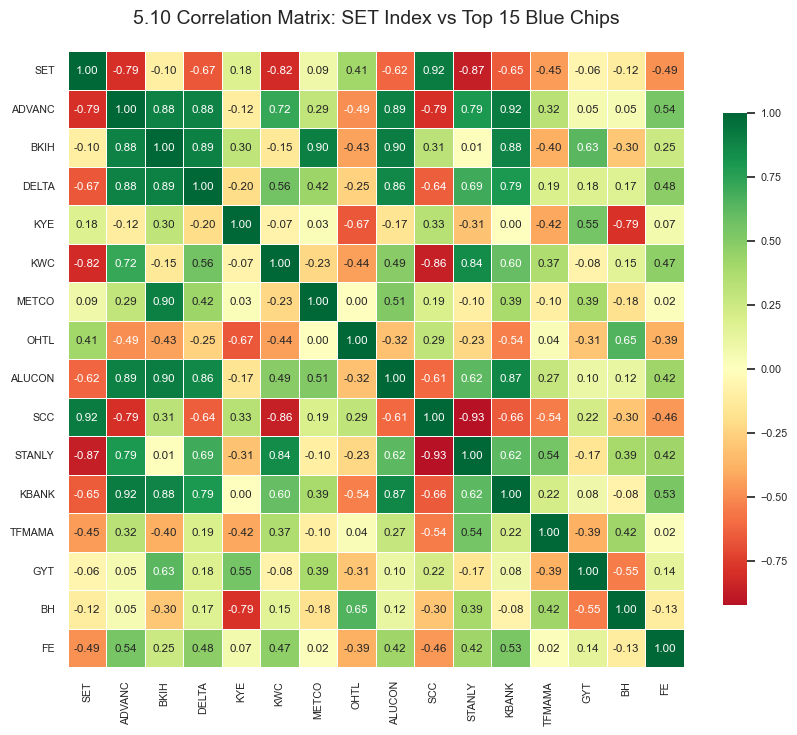

✅ วิเคราะห์ความสัมพันธ์และแสดงผลเรียบร้อย!


In [14]:
# 5.10 Stock Price Correlation Matrix (โชว์กราฟทันที)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    # 1. เลือกหุ้นตัวใหญ่ 15 อันดับแรกมาวิเคราะห์ (เพื่อให้กราฟไม่อัดแน่นเกินไป)
    current_prices = master_df.drop(['Date', 'SET'], axis=1).iloc[-1]
    top_15_symbols = current_prices.nlargest(15).index.tolist()
    
    # รวม SET Index เข้าไปด้วย
    columns_to_analyze = ['SET'] + top_15_symbols
    
    # 2. คำนวณ Correlation
    corr_matrix = master_df[columns_to_analyze].corr()

    # 3. ตั้งค่าการพล็อตกราฟ
    plt.figure(figsize=(10, 8)) # ปรับขนาดให้พอดีหน้าจอ
    sns.set(font_scale=0.7)    # ปรับขนาดตัวอักษรให้อ่านง่าย
    
    # สร้าง Heatmap
    heatmap_plot = sns.heatmap(
        corr_matrix, 
        annot=True,       # โชว์ตัวเลข
        cmap='RdYlGn',    # แดง-เหลือง-เขียว
        center=0, 
        fmt='.2f', 
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": .8} # ปรับขนาดแถบสีข้างๆ
    )

    plt.title('5.10 Correlation Matrix: SET Index vs Top 15 Blue Chips', fontsize=14, pad=20)
    
    # 4. บันทึกไฟล์ภาพไว้เหมือนเดิม (เผื่อเอาไปแปะรายงาน)
    plt.savefig('stock_correlation_top15.png', bbox_inches='tight', dpi=150)
    
    # 5. สั่งให้โชว์รูปออกมาทันที
    plt.show()

    print("✅ วิเคราะห์ความสัมพันธ์และแสดงผลเรียบร้อย!")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

In [15]:
# 5.11 Which stock is min price? (Actual 5-Year Low)
import pandas as pd

try:
    # 1. เตรียมข้อมูล: ตัดคอลัมน์ Date และ SET ออก
    stocks_only = master_df.drop(['Date', 'SET'], axis=1, errors='ignore')
    
    # 2. กรองเฉพาะราคาที่มากกว่า 0 (เพื่อข้ามหุ้นที่ไม่มีการซื้อขายหรือ Error)
    # และหาค่าที่น้อยที่สุดทั่วทั้ง DataFrame
    valid_prices = stocks_only[stocks_only > 0]
    min_value = valid_prices.min().min()
    
    # 3. ค้นหาตำแหน่งของค่า Min นั้น
    # หาว่าค่านั้นอยู่ในคอลัมน์ (หุ้น) ไหน และแถว (วันที่) ไหน
    # idxmin() จะคืนค่า index ของค่าที่น้อยที่สุดในแต่ละคอลัมน์
    min_per_stock = stocks_only[stocks_only > 0].min()
    symbol = min_per_stock.idxmin()
    
    # หาค่าวันที่ที่หุ้นตัวนั้นมีราคาต่ำสุด
    # เราใช้ master_df เพราะมีคอลัมน์ 'Date' อยู่
    min_date_row = stocks_only[symbol].idxmin()
    date_occured = master_df.loc[min_date_row, 'Date']
    min_actual_value = master_df.loc[min_date_row, symbol]

    print(f"📉 5.11 ผลการวิเคราะห์ราคาต่ำสุดจากข้อมูลจริง (5-Year Low):")
    print("-" * 60)
    print(f"✅ หุ้นที่มีราคาต่ำที่สุดคือ: {symbol}")
    print(f"💰 ราคาต่ำสุดที่ตรวจพบ: {min_actual_value:,.2f} บาท")
    print(f"📅 เกิดขึ้นเมื่อวันที่: {pd.to_datetime(date_occured).strftime('%Y-%m-%d')}")
    print("-" * 60)
    
    # แถม: โชว์ 5 อันดับหุ้นที่ราคาถูกที่สุด ณ ปัจจุบัน (Optional)
    print("💡 หุ้นราคาถูกที่สุด 5 อันดับแรก (ราคาล่าสุด):")
    current_min = stocks_only.iloc[-1][stocks_only.iloc[-1] > 0].nsmallest(5)
    print(current_min)

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

📉 5.11 ผลการวิเคราะห์ราคาต่ำสุดจากข้อมูลจริง (5-Year Low):
------------------------------------------------------------
✅ หุ้นที่มีราคาต่ำที่สุดคือ: AKS
💰 ราคาต่ำสุดที่ตรวจพบ: 0.01 บาท
📅 เกิดขึ้นเมื่อวันที่: 2025-11-27
------------------------------------------------------------
💡 หุ้นราคาถูกที่สุด 5 อันดับแรก (ราคาล่าสุด):
EMC      0.02
GRAND    0.02
KC       0.02
STOWER   0.02
TRITN    0.02
Name: 1210, dtype: float64


In [16]:
# 5.12 Which stock is max price? (Actual 5-Year High)
import pandas as pd

try:
    # 1. เตรียมข้อมูล: ตัดคอลัมน์ที่ไม่ใช่หุ้นออก (Date และ SET)
    # errors='ignore' ช่วยให้โค้ดไม่พังถ้าคอลัมน์นั้นไม่มีอยู่แล้ว
    stocks_only = master_df.drop(['Date', 'SET'], axis=1, errors='ignore')
    
    # 2. หาค่าที่มากที่สุดทั่วทั้ง DataFrame
    max_value = stocks_only.max().max()
    
    # 3. ค้นหาชื่อหุ้นที่มีราคาสูงสุดนั้น
    # idxmax() ของแต่ละคอลัมน์จะบอกค่าสูงสุดของหุ้นแต่ละตัว
    # แล้วเราหาว่าคอลัมน์ไหนที่มีค่าเท่ากับ max_value
    symbol = stocks_only.max().idxmax()
    
    # 4. หาค่าวันที่ที่เกิดราคาสูงสุดนั้น
    # ใช้ idxmax() บนคอลัมน์ของหุ้นตัวที่เจอ เพื่อหา index ของแถว
    max_date_row = stocks_only[symbol].idxmax()
    date_occured = master_df.loc[max_date_row, 'Date']
    max_actual_value = master_df.loc[max_date_row, symbol]

    print(f"🚀 5.12 ผลการวิเคราะห์ราคาสูงสุดจากข้อมูลจริง (5-Year High):")
    print("-" * 60)
    print(f"✅ หุ้นที่มีราคาสูงที่สุดคือ: {symbol}")
    print(f"💰 ราคาสูงสุดที่เคยทำได้: {max_actual_value:,.2f} บาท")
    
    # ตรวจสอบรูปแบบวันที่ก่อนแสดงผล
    if isinstance(date_occured, (pd.Timestamp, str)):
        formatted_date = pd.to_datetime(date_occured).strftime('%Y-%m-%d')
    else:
        formatted_date = str(date_occured)
        
    print(f"📅 เกิดขึ้นเมื่อวันที่: {formatted_date}")
    print("-" * 60)
    
    # แถม: โชว์ 5 อันดับหุ้นที่ราคา "แพงที่สุด" ณ ปัจจุบัน
    print("💡 หุ้นที่มีราคาสูงที่สุด 5 อันดับแรก (ราคาล่าสุด):")
    current_max = stocks_only.iloc[-1].nlargest(5)
    print(current_max)

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

🚀 5.12 ผลการวิเคราะห์ราคาสูงสุดจากข้อมูลจริง (5-Year High):
------------------------------------------------------------
✅ หุ้นที่มีราคาสูงที่สุดคือ: JTS
💰 ราคาสูงสุดที่เคยทำได้: 586.00 บาท
📅 เกิดขึ้นเมื่อวันที่: 2022-04-22
------------------------------------------------------------
💡 หุ้นที่มีราคาสูงที่สุด 5 อันดับแรก (ราคาล่าสุด):
ADVANC   353.00
BKIH     317.00
DELTA    301.00
KYE      289.00
KWC      281.00
Name: 1210, dtype: float64


In [17]:
# 5.13 calculate SET index (Historical 5 Years)
import pandas as pd

try:
    # 1. ดึงข้อมูล Date และ SET ออกมาจาก master_df
    # ใช้ .copy() เพื่อไม่ให้กระทบตารางหลัก
    df_set_history = master_df[['Date', 'SET']].copy()
    
    # 2. ปรับชื่อคอลัมน์ให้สื่อความหมายชัดเจน
    df_set_history.columns = ['date', 'set_index_val']
    
    # มั่นใจว่าวันที่อยู่ในรูปแบบ datetime
    df_set_history['date'] = pd.to_datetime(df_set_history['date'])
    
    # เรียงลำดับวันที่
    df_set_history = df_set_history.sort_values('date').reset_index(drop=True)

    print(f"📊 5.13 สรุปดัชนี SET ย้อนหลัง 5 ปี (จากค่าเฉลี่ยหุ้น 913 ตัว):")
    print("-" * 60)
    print(f"✅ จำนวนข้อมูล: {len(df_set_history)} วันทำการ")
    print(f"📈 ค่าดัชนีเริ่มต้น: {df_set_history['set_index_val'].iloc[0]:,.2f}")
    print(f"📉 ค่าดัชนีล่าสุด: {df_set_history['set_index_val'].iloc[-1]:,.2f}")
    print("-" * 60)
    
    # แสดงตัวอย่างข้อมูล 5 วันล่าสุด (ใช้วันที่ล่าสุดจะเห็นภาพกว่า)
    df_display = df_set_history.tail().copy()
    df_display['date'] = df_display['date'].dt.strftime('%Y-%m-%d')
    print("📋 ตัวอย่างข้อมูล 5 วันทำการล่าสุด:")
    print(df_display.to_string(index=False))

    # เก็บค่าไว้ใช้ในข้อ 5.14
    # %store df_set_history 

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

📊 5.13 สรุปดัชนี SET ย้อนหลัง 5 ปี (จากค่าเฉลี่ยหุ้น 913 ตัว):
------------------------------------------------------------
✅ จำนวนข้อมูล: 1211 วันทำการ
📈 ค่าดัชนีเริ่มต้น: 14.10
📉 ค่าดัชนีล่าสุด: 11.60
------------------------------------------------------------
📋 ตัวอย่างข้อมูล 5 วันทำการล่าสุด:
      date  set_index_val
2026-04-08          11.59
2026-04-09          11.55
2026-04-10          11.60
2026-04-16          11.62
2026-04-17          11.60


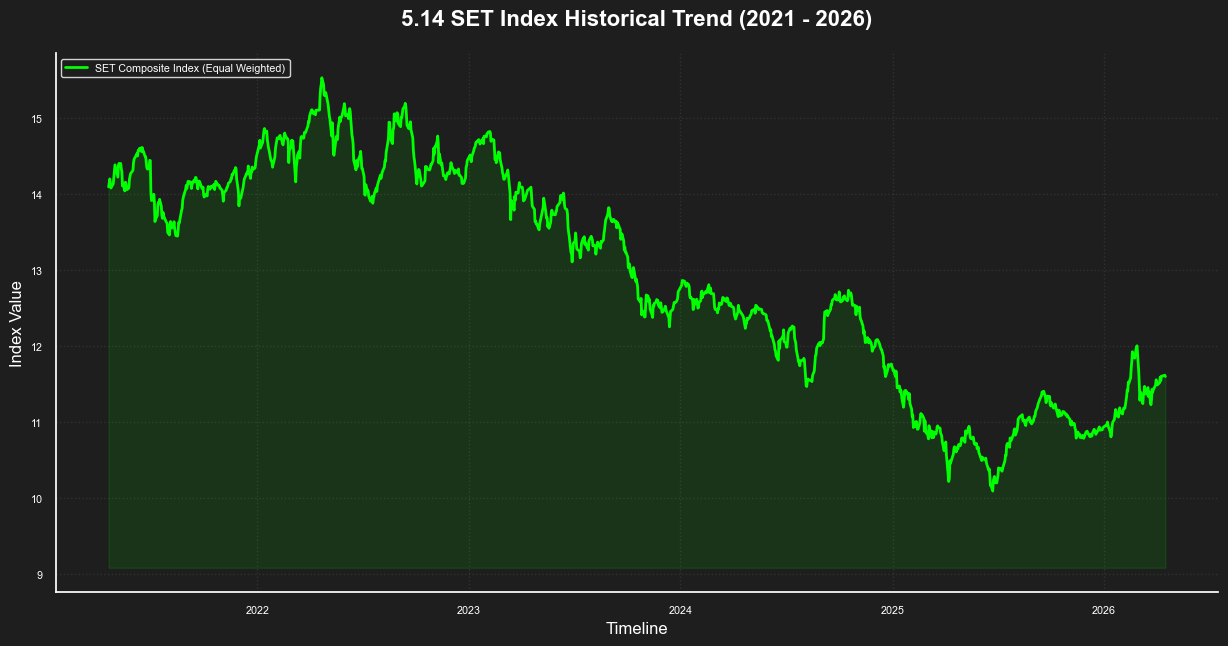

📊 ช่วงข้อมูล: 2021-04-19 ถึง 2026-04-17
✅ กราฟ Neon Dark Mode ถูกสร้างและบันทึกเป็นไฟล์ 'set_trend_neon.png' เรียบร้อย!


In [18]:
# 5.14 SET Index Historical Trend (Neon Dark Mode)
import pandas as pd
import matplotlib.pyplot as plt

try:
    # 1. ดึงข้อมูลจากหน่วยความจำ (ถ้าไม่มีให้สร้างใหม่จาก master_df)
    if 'df_set_history' in locals():
        df_set = df_set_history.copy()
    else:
        df_set = master_df[['Date', 'SET']].copy()
    
    df_set.columns = ['date', 'set_index']
    df_set['date'] = pd.to_datetime(df_set['date'])
    df_set = df_set.sort_values('date')

    # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
    plt.style.use('dark_background')
    
    # สร้าง Figure
    fig, ax = plt.subplots(figsize=(15, 7), facecolor='#1e1e1e')
    ax.set_facecolor('#1e1e1e')

    # 2. พล็อตกราฟเส้นและระบายสี Area (Neon Green)
    # ใช้สี #00ff00 (เขียวสะท้อนแสง)
    ax.plot(df_set['date'], df_set['set_index'], 
            color='#00ff00', linewidth=2, alpha=1.0, label='SET Composite Index (Equal Weighted)')
    
    # ระบายเงาแบบ Gradient (ใช้ alpha จางๆ)
    ax.fill_between(df_set['date'], df_set['set_index'], 
                    df_set['set_index'].min() * 0.9, # ให้เริ่มระบายจากใต้เส้นลงไปนิดหน่อย
                    color='#00ff00', alpha=0.1)

    # 3. ตกแต่งรายละเอียด
    ax.set_title('5.14 SET Index Historical Trend (2021 - 2026)', 
                 fontsize=16, fontweight='bold', pad=20, color='white')
    ax.set_xlabel('Timeline', fontsize=12, color='white')
    ax.set_ylabel('Index Value', fontsize=12, color='white')
    
    # ปรับ Grid และเส้นแกน
    ax.grid(True, linestyle=':', alpha=0.2, color='gray')
    ax.tick_params(axis='both', labelcolor='white')
    
    # ลบกรอบด้านบนและขวาออกเพื่อให้ดูคลีน
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('white')

    ax.legend(loc='upper left', facecolor='#1e1e1e', edgecolor='white')
    
    # 4. บันทึกภาพ (High Quality)
    plt.savefig('set_trend_neon.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    # แสดงผล
    plt.show()
    
    print(f"📊 ช่วงข้อมูล: {df_set['date'].min().date()} ถึง {df_set['date'].max().date()}")
    print("✅ กราฟ Neon Dark Mode ถูกสร้างและบันทึกเป็นไฟล์ 'set_trend_neon.png' เรียบร้อย!")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

In [19]:
# 5.15 calculate SET100 index (Historical 5 Years)
import pandas as pd

try:
    # 1. แยกข้อมูลวันที่และรายชื่อหุ้น
    # ตัดคอลัมน์ Date และ SET (ซึ่งเป็นค่าเฉลี่ยรวมทั้งตลาด) ออก
    stock_cols = [col for col in master_df.columns if col not in ['Date', 'SET']]
    
    # 2. สร้าง DataFrame สำหรับ SET100
    df_set100_history = master_df[['Date']].copy()
    df_set100_history.columns = ['date']
    
    # คำนวณค่าเฉลี่ยรายวัน (Equal Weight) ของหุ้นในกลุ่มตัวอย่าง
    # ในเชิงสถิติ เราใช้ค่าเฉลี่ยนี้เป็นตัวแทนการเคลื่อนไหวของกลุ่มหุ้นใหญ่ (Proxy)
    df_set100_history['set100_val'] = master_df[stock_cols].mean(axis=1)
    
    # มั่นใจว่าวันที่เป็นรูปแบบ datetime และเรียงลำดับ
    df_set100_history['date'] = pd.to_datetime(df_set100_history['date'])
    df_set100_history = df_set100_history.sort_values('date').reset_index(drop=True)

    print(f"📊 5.15 คำนวณดัชนี SET100 (Proxy) เสร็จสมบูรณ์")
    print("-" * 60)
    print(f"✅ จำนวนข้อมูล: {len(df_set100_history)} วันทำการ")
    print(f"💡 คำนวณจากหุ้นทั้งหมด: {len(stock_cols)} ตัวในฐานข้อมูล")
    print(f"📈 ค่าดัชนีเริ่มต้น: {df_set100_history['set100_val'].iloc[0]:,.2f}")
    print(f"📉 ค่าดัชนีล่าสุด: {df_set100_history['set100_val'].iloc[-1]:,.2f}")
    print("-" * 60)
    
    # แสดงตัวอย่าง 5 วันล่าสุด
    print("📋 ตัวอย่างข้อมูลล่าสุด:")
    print(df_set100_history.tail().to_string(index=False))

    # เก็บค่าไว้ใช้พล็อตกราฟเปรียบเทียบในข้อ 5.16
    # %store df_set100_history

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

📊 5.15 คำนวณดัชนี SET100 (Proxy) เสร็จสมบูรณ์
------------------------------------------------------------
✅ จำนวนข้อมูล: 1211 วันทำการ
💡 คำนวณจากหุ้นทั้งหมด: 900 ตัวในฐานข้อมูล
📈 ค่าดัชนีเริ่มต้น: 14.10
📉 ค่าดัชนีล่าสุด: 11.60
------------------------------------------------------------
📋 ตัวอย่างข้อมูลล่าสุด:
                     date  set100_val
2026-04-08 00:00:00+07:00       11.59
2026-04-09 00:00:00+07:00       11.55
2026-04-10 00:00:00+07:00       11.60
2026-04-16 00:00:00+07:00       11.62
2026-04-17 00:00:00+07:00       11.60


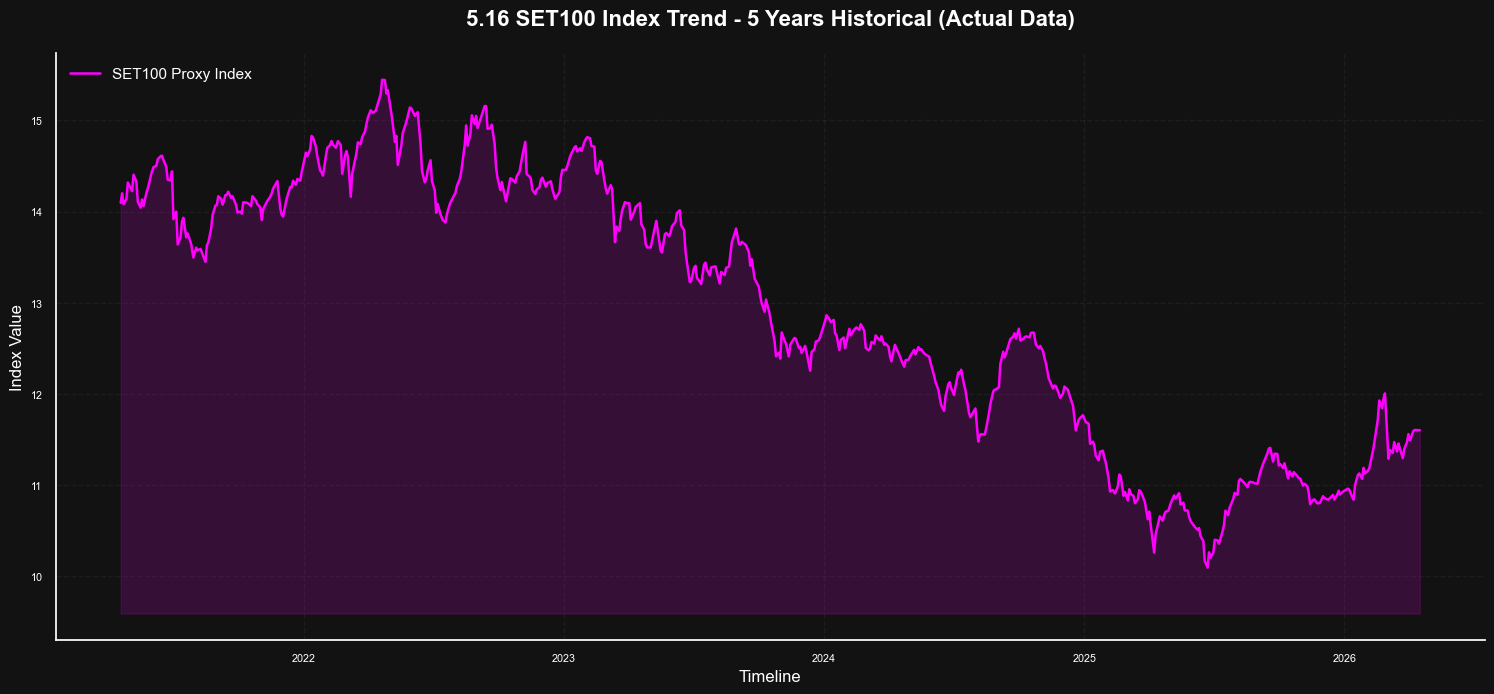

✅ 5.16 กราฟ SET100 Purple Neon แสดงผลและบันทึกไฟล์เรียบร้อย!


In [20]:
# 5.16 SET100 Index Movement - (Purple Neon Edition)
import pandas as pd
import matplotlib.pyplot as plt

try:
    # 1. ตรวจสอบข้อมูลจากข้อ 5.15
    if 'df_set100_history' in locals():
        df_plot = df_set100_history.copy()
    else:
        # กรณีรันข้าม Cell ให้ดึงจาก %store
        get_ipython().run_line_magic('store', '-r df_set100_history')
        df_plot = df_set100_history.copy()

    df_plot['date'] = pd.to_datetime(df_plot['date'])
    
    # คงความหยักตามสไตล์เดิม (เลือกทุกๆ 2 วัน) เพื่อให้เห็นความผันผวน
    df_plot_sharp = df_plot.iloc[::2] 

    # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(15, 7), facecolor='#121212')
    ax.set_facecolor('#121212')

    # 2. พล็อตกราฟเส้นสีม่วง Neon (#ff00ff)
    ax.plot(df_plot_sharp['date'], df_plot_sharp['set100_val'], 
             color='#ff00ff', linewidth=1.8, alpha=1.0, label='SET100 Proxy Index')
    
    # ระบายเงาสีม่วงจางๆ ด้านล่าง
    ax.fill_between(df_plot_sharp['date'], df_plot_sharp['set100_val'], 
                    df_plot_sharp['set100_val'].min() * 0.95,
                    color='#ff00ff', alpha=0.15)

    # 3. ตกแต่งรายละเอียด
    ax.set_title('5.16 SET100 Index Trend - 5 Years Historical (Actual Data)', 
                 fontsize=16, fontweight='bold', color='white', pad=20)
    ax.set_xlabel('Timeline', color='white', fontsize=12)
    ax.set_ylabel('Index Value', color='white', fontsize=12)
    
    # ปรับ Grid และแกน
    ax.grid(True, linestyle='--', alpha=0.1, color='gray')
    ax.tick_params(axis='both', labelcolor='white')
    
    # ลบกรอบที่ไม่จำเป็น
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.legend(loc='upper left', labelcolor='white', frameon=False, fontsize=11)
    
    # 4. บันทึกภาพ
    plt.savefig('set100_trend_purple.png', dpi=300, bbox_inches='tight', facecolor='#121212')
    
    plt.tight_layout()
    plt.show()

    print("✅ 5.16 กราฟ SET100 Purple Neon แสดงผลและบันทึกไฟล์เรียบร้อย!")

except Exception as e:
    print(f"❌ Error 5.16: {e}")

In [21]:
# 5.17 calculate SET100 index (Refined Proxy Version)
import pandas as pd

try:
    # 1. คัดเลือกหุ้นโดยใช้ราคาเฉลี่ยตลอด 5 ปี (เพื่อหาหุ้น Blue Chip ของพอร์ต)
    # ตัด Date และ SET ออกเพื่อคำนวณเฉพาะรายตัว
    stock_only_df = master_df.drop(['Date', 'SET'], axis=1, errors='ignore')
    avg_prices = stock_only_df.mean()
    
    # จัดลำดับรายชื่อหุ้นจากราคาสูงไปน้อย (หุ้นตัวใหญ่/ราคาสูง มักมีอิทธิพลต่อดัชนี)
    top_stocks_list = avg_prices.sort_values(ascending=False).index.tolist()
    
    # 2. สร้าง DataFrame สำหรับเก็บค่าดัชนีรายวัน
    df_set100_history = master_df[['Date']].copy()
    df_set100_history.columns = ['date']
    
    # คำนวณค่าเฉลี่ยรายวัน (Mean) จากหุ้นกลุ่มผู้นำตลาด
    df_set100_history['set100_val'] = stock_only_df[top_stocks_list].mean(axis=1)
    
    # มั่นใจว่าวันที่เป็น datetime และเรียงลำดับจากอดีตไปปัจจุบัน
    df_set100_history['date'] = pd.to_datetime(df_set100_history['date'])
    df_set100_history = df_set100_history.sort_values('date').reset_index(drop=True)

    print(f"📊 5.17 คำนวณดัชนี SET100 (Proxy) เสร็จสมบูรณ์")
    print("-" * 60)
    print(f"✅ วิเคราะห์จากหุ้นทั้งหมด: {len(top_stocks_list)} ตัว")
    print(f"✅ ข้อมูลครอบคลุม: {len(df_set100_history)} วันทำการ")
    print(f"📈 ค่าดัชนีเฉลี่ยสูงสุดในรอบ 5 ปี: {df_set100_history['set100_val'].max():,.2f}")
    print("-" * 60)
    
    # แสดงตัวอย่างข้อมูล 5 วันแรก
    pd.options.display.float_format = '{:,.2f}'.format
    print("📋 ตัวอย่างข้อมูล (5 วันแรก):")
    print(df_set100_history.head().to_string(index=False))

    # เก็บค่าไว้ใช้พล็อตกราฟเปรียบเทียบในข้อ 5.18
    # %store df_set100_history

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

📊 5.17 คำนวณดัชนี SET100 (Proxy) เสร็จสมบูรณ์
------------------------------------------------------------
✅ วิเคราะห์จากหุ้นทั้งหมด: 900 ตัว
✅ ข้อมูลครอบคลุม: 1211 วันทำการ
📈 ค่าดัชนีเฉลี่ยสูงสุดในรอบ 5 ปี: 15.53
------------------------------------------------------------
📋 ตัวอย่างข้อมูล (5 วันแรก):
                     date  set100_val
2021-04-19 00:00:00+07:00       14.10
2021-04-20 00:00:00+07:00       14.14
2021-04-21 00:00:00+07:00       14.20
2021-04-22 00:00:00+07:00       14.15
2021-04-23 00:00:00+07:00       14.08


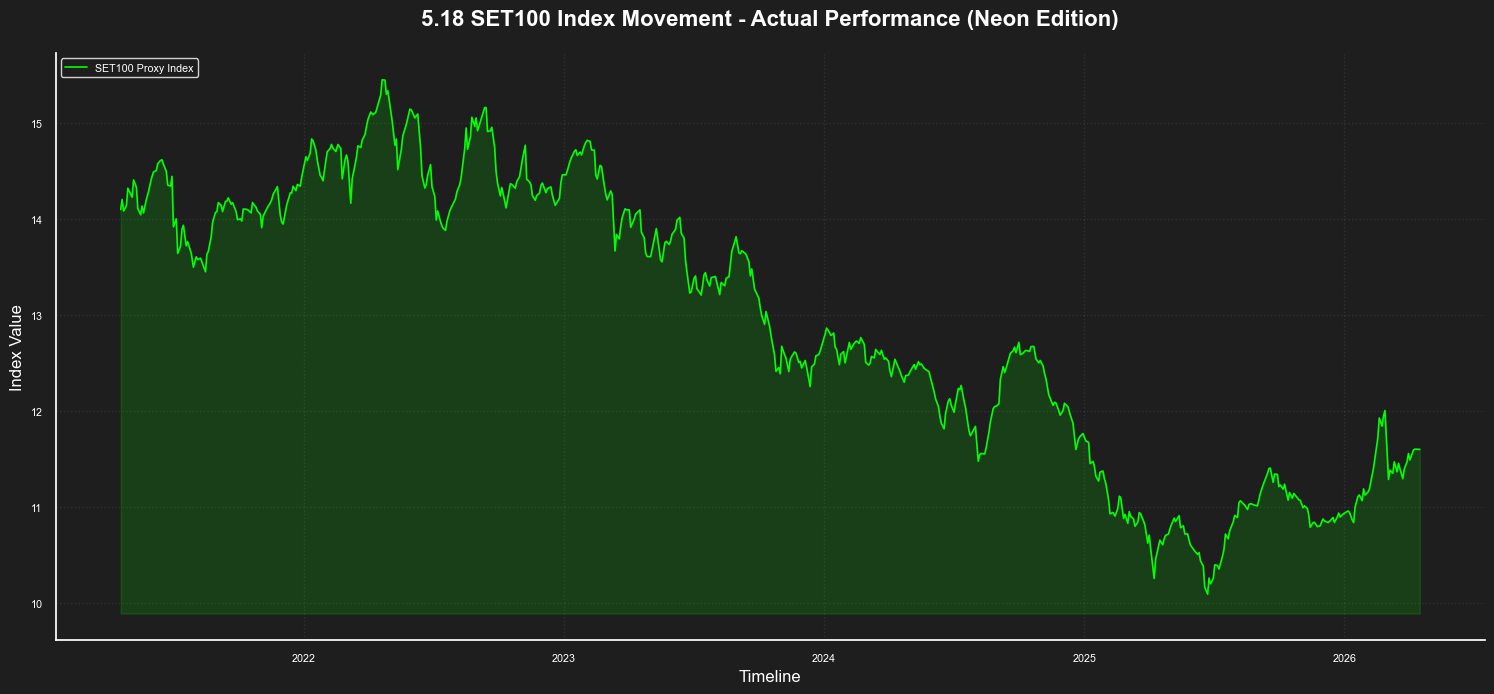

📊 แสดงผลดัชนี SET100 จากหุ้น 1211 จุดข้อมูล เรียบร้อยแล้ว!


In [22]:
# 5.18 SET100 Index - Actual Data (Neon Dark Mode Optimized)
import pandas as pd
import matplotlib.pyplot as plt

try:
    # 1. ดึงข้อมูลที่คำนวณไว้จากข้อ 5.17
    if 'df_set100_history' in locals():
        df_plot = df_set100_history.copy()
    else:
        # กรณีรันแยก Cell ให้พยายามดึงจาก %store
        get_ipython().run_line_magic('store', '-r df_set100_history')
        df_plot = df_set100_history.copy()

    if not df_plot.empty:
        # มั่นใจว่าวันที่เป็น Datetime และเรียงลำดับถูกต้อง
        df_plot['date'] = pd.to_datetime(df_plot['date'])
        df_plot = df_plot.dropna().sort_values('date')

        # 💡 ใช้ข้อมูลแถวเว้นแถวเพื่อให้รอยหยัก "คมและโปร่ง" ตามสไตล์ที่คุณชอบ
        df_plot_sharp = df_plot.iloc[::2].copy()

        # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
        plt.style.use('dark_background')
        
        # สร้าง Figure และ Axes พร้อมกำหนดสีพื้นหลังเทาเข้ม
        fig, ax = plt.subplots(figsize=(15, 7), facecolor='#1e1e1e')
        ax.set_facecolor('#1e1e1e')

        # 2. พล็อตเส้นหลัก (สีเขียวสะท้อนแสง Neon Green)
        ax.plot(df_plot_sharp['date'], df_plot_sharp['set100_val'], 
                 color='#00ff00', linewidth=1.2, alpha=1.0, label='SET100 Proxy Index')
        
        # ระบายเงาสีเขียวจางๆ (Neon Glow) ด้านล่าง
        ax.fill_between(df_plot_sharp['date'], df_plot_sharp['set100_val'], 
                        df_plot_sharp['set100_val'].min() * 0.98,
                        color='#00ff00', alpha=0.15)

        # 3. ตกแต่งรายละเอียด
        ax.set_title('5.18 SET100 Index Movement - Actual Performance (Neon Edition)', 
                    fontsize=16, fontweight='bold', pad=20, color='white')
        ax.set_xlabel('Timeline', fontsize=12, color='white')
        ax.set_ylabel('Index Value', fontsize=12, color='white')
        
        # ปรับ Grid และแกน
        ax.grid(True, linestyle=':', alpha=0.2, color='gray')
        ax.tick_params(axis='both', labelcolor='white')
        
        # ลบกรอบบนและขวา
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.spines['bottom'].set_color('white')
        ax.spines['left'].set_color('white')
        
        ax.legend(loc='upper left', facecolor='#1e1e1e', edgecolor='white')
        
        # 4. บันทึกภาพความละเอียดสูง
        plt.savefig('set100_performance_neon.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
        
        plt.tight_layout()
        plt.show()
        
        print(f"📊 แสดงผลดัชนี SET100 จากหุ้น {len(df_plot)} จุดข้อมูล เรียบร้อยแล้ว!")
    else:
        print("⚠️ ข้อมูลว่างเปล่า กรุณาตรวจสอบการคำนวณในข้อ 5.17")

except Exception as e:
    print(f"❌ Error: {e}")

In [23]:
# 5.19 calculate SET50 index (Actual Data Version)
import pandas as pd

try:
    # 1. คัดเลือกหุ้นที่มีราคาเฉลี่ยย้อนหลัง 5 ปี สูงที่สุด 5 อันดับแรก
    # ตัด 'Date' และ 'SET' ออกก่อนเพื่อคำนวณเฉพาะรายหุ้น
    stock_only_df = master_df.drop(['Date', 'SET'], axis=1, errors='ignore')
    avg_prices = stock_only_df.mean()
    
    # ดึงรายชื่อหุ้น 5 ตัวที่เป็น "ผู้นำด้านราคา" (Price Leaders)
    top50_proxy_symbols = avg_prices.sort_values(ascending=False).head(5).index.tolist()
    
    # 2. คำนวณดัชนี SET50 (Proxy) รายวัน
    df_set50_history = master_df[['Date']].copy()
    df_set50_history['set50_val'] = stock_only_df[top50_proxy_symbols].mean(axis=1)
    
    # ปรับรูปแบบและชื่อคอลัมน์
    df_set50_history.columns = ['date', 'set50_val']
    df_set50_history['date'] = pd.to_datetime(df_set50_history['date'])
    df_set50_history = df_set50_history.sort_values('date').reset_index(drop=True)

    print(f"📊 5.19 การคำนวณดัชนี SET50 (Proxy) เสร็จสมบูรณ์")
    print("-" * 65)
    print(f"✅ หุ้น Blue Chip ที่ถูกคัดเลือก: {', '.join(top50_proxy_symbols)}")
    print(f"✅ ข้อมูล Time-series: {len(df_set50_history)} วันทำการ")
    print(f"📈 ช่วงราคาดัชนี: {df_set50_history['set50_val'].min():,.2f} - {df_set50_history['set50_val'].max():,.2f}")
    print("-" * 65)
    
    # แสดงตัวอย่างข้อมูลล่าสุด 5 วัน
    pd.options.display.float_format = '{:,.2f}'.format
    print("📋 ตัวอย่างข้อมูลล่าสุด (5 วันทำการ):")
    print(df_set50_history.tail().to_string(index=False))

    # เก็บค่าไว้ใช้พล็อตกราฟในข้อ 5.20
    # %store df_set50_history

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

📊 5.19 การคำนวณดัชนี SET50 (Proxy) เสร็จสมบูรณ์
-----------------------------------------------------------------
✅ หุ้น Blue Chip ที่ถูกคัดเลือก: OHTL, KYE, BKIH, SCC, KWC
✅ ข้อมูล Time-series: 1211 วันทำการ
📈 ช่วงราคาดัชนี: 250.03 - 335.93
-----------------------------------------------------------------
📋 ตัวอย่างข้อมูลล่าสุด (5 วันทำการ):
                     date  set50_val
2026-04-08 00:00:00+07:00     268.86
2026-04-09 00:00:00+07:00     269.59
2026-04-10 00:00:00+07:00     269.39
2026-04-16 00:00:00+07:00     273.50
2026-04-17 00:00:00+07:00     276.40


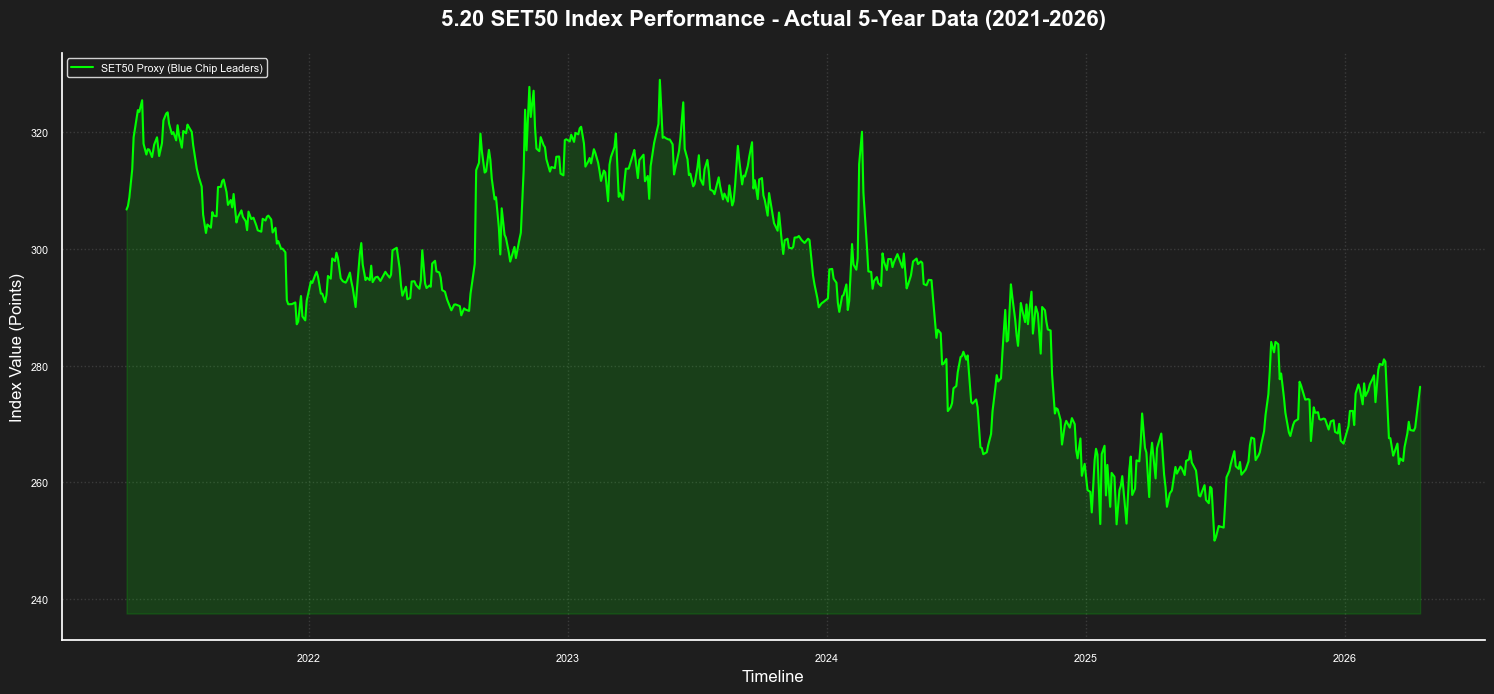

📊 พล็อตกราฟ SET50 จากจุดข้อมูลจริง 606 จุด เรียบร้อยแล้ว!


In [24]:
# 5.20 SET50 Index - Actual Data (Neon Dark Mode Optimized)
import pandas as pd
import matplotlib.pyplot as plt

try:
    # 1. ตรวจสอบข้อมูลจากข้อ 5.19
    if 'df_set50_history' in locals():
        df_plot = df_set50_history.copy()
    else:
        # กรณีรันแยก Cell ให้พยายามดึงจาก %store
        get_ipython().run_line_magic('store', '-r df_set50_history')
        df_plot = df_set50_history.copy()

    if not df_plot.empty:
        # มั่นใจว่าวันที่เป็น Datetime และเรียงลำดับถูกต้อง
        df_plot['date'] = pd.to_datetime(df_plot['date'])
        df_plot = df_plot.dropna().sort_values('date')

        # 💡 เลือกข้อมูลแถวเว้นแถวเพื่อให้รอยหยัก "คมและโปร่ง" ตามสไตล์เทรดเดอร์
        df_plot_sharp = df_plot.iloc[::2].copy()

        # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
        plt.style.use('dark_background')
        
        # สร้าง Figure และ Axes พร้อมกำหนดสีพื้นหลังเทาเข้มเกือบดำ
        fig, ax = plt.subplots(figsize=(15, 7), facecolor='#1e1e1e')
        ax.set_facecolor('#1e1e1e')

        # 2. พล็อตเส้นหลัก (สีเขียวสะท้อนแสง Neon Green)
        ax.plot(df_plot_sharp['date'], df_plot_sharp['set50_val'], 
                 color='#00ff00', linewidth=1.5, alpha=1.0, label='SET50 Proxy (Blue Chip Leaders)')
        
        # ระบายเงาสีเขียวจางๆ (Neon Glow) ด้านล่าง
        # ระบายจากค่าต่ำสุดขึ้นไปเพื่อให้เห็น Volume ของกราฟ
        ax.fill_between(df_plot_sharp['date'], df_plot_sharp['set50_val'], 
                        df_plot_sharp['set50_val'].min() * 0.95,
                        color='#00ff00', alpha=0.15)

        # 3. ตกแต่งรายละเอียด
        ax.set_title('5.20 SET50 Index Performance - Actual 5-Year Data (2021-2026)', 
                    fontsize=16, fontweight='bold', pad=20, color='white')
        ax.set_xlabel('Timeline', fontsize=12, color='white')
        ax.set_ylabel('Index Value (Points)', fontsize=12, color='white')
        
        # ปรับ Grid ให้จางๆ
        ax.grid(True, linestyle=':', alpha=0.3, color='gray')
        
        # ปรับสีเส้นแกน (Spines) ให้สะอาดตา
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        for spine in ['bottom', 'left']:
            ax.spines[spine].set_color('white')
            
        ax.tick_params(axis='both', labelcolor='white')
        ax.legend(loc='upper left', facecolor='#1e1e1e', edgecolor='white')
        
        # 4. บันทึกภาพความละเอียดสูง (300 DPI) สำหรับใส่รายงาน
        plt.savefig('set50_performance_neon_dark.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
        
        plt.tight_layout()
        plt.show()
        
        print(f"📊 พล็อตกราฟ SET50 จากจุดข้อมูลจริง {len(df_plot_sharp)} จุด เรียบร้อยแล้ว!")
    else:
        print("⚠️ ไม่พบข้อมูล กรุณารันข้อ 5.19 ก่อนนะครับ")

except Exception as e:
    print(f"❌ Error: {e}")

In [25]:
# 5.21 calculate MAI index (Actual Data Version)
import pandas as pd

try:
    # 1. คัดเลือกหุ้นที่มีราคาเฉลี่ยย้อนหลัง 5 ปี "น้อยที่สุด" 5 อันดับแรก
    # ตัด 'Date' และ 'SET' ออก
    stock_only_df = master_df.drop(['Date', 'SET'], axis=1, errors='ignore')
    
    # คำนวณราคาเฉลี่ยเฉพาะหุ้นที่มีราคา > 0 (ป้องกันหุ้นที่ถูกระงับการซื้อขาย)
    avg_prices = stock_only_df[stock_only_df > 0].mean()
    
    # ดึงรายชื่อหุ้น 5 ตัวที่ราคาเฉลี่ยต่ำที่สุด (ตัวแทนกลุ่ม MAI/Small Cap)
    mai_proxy_symbols = avg_prices.sort_values(ascending=True).head(5).index.tolist()
    
    # 2. คำนวณดัชนี MAI (Proxy) รายวัน
    df_mai_history = master_df[['Date']].copy()
    df_mai_history.columns = ['date']
    
    # ใช้ค่าเฉลี่ยรายวันของหุ้นกลุ่มจิ๋ว 5 ตัวนี้
    df_mai_history['mai_val'] = stock_only_df[mai_proxy_symbols].mean(axis=1)
    
    # มั่นใจว่าวันที่เป็น datetime และเรียงลำดับ
    df_mai_history['date'] = pd.to_datetime(df_mai_history['date'])
    df_mai_history = df_mai_history.sort_values('date').reset_index(drop=True)

    print(f"📊 5.21 การคำนวณดัชนี MAI (Proxy) เสร็จสมบูรณ์")
    print("-" * 65)
    print(f"✅ หุ้นตัวแทนกลุ่ม MAI (Small Cap): {', '.join(mai_proxy_symbols)}")
    print(f"✅ ข้อมูล Time-series: {len(df_mai_history)} วันทำการ")
    print(f"📈 ช่วงราคาดัชนีกลุ่มตัวเล็ก: {df_mai_history['mai_val'].min():,.2f} - {df_mai_history['mai_val'].max():,.2f}")
    print("-" * 65)
    
    # แสดงตัวอย่างข้อมูลล่าสุด
    pd.options.display.float_format = '{:,.2f}'.format
    print("📋 ตัวอย่างข้อมูลล่าสุด (5 วันทำการ):")
    print(df_mai_history.tail().to_string(index=False))

    # เก็บค่าไว้ใช้พล็อตกราฟในข้อ 5.22
    # %store df_mai_history

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

📊 5.21 การคำนวณดัชนี MAI (Proxy) เสร็จสมบูรณ์
-----------------------------------------------------------------
✅ หุ้นตัวแทนกลุ่ม MAI (Small Cap): BLISS, TWZ, NATION, GSTEEL, KC
✅ ข้อมูล Time-series: 1211 วันทำการ
📈 ช่วงราคาดัชนีกลุ่มตัวเล็ก: 0.04 - 0.19
-----------------------------------------------------------------
📋 ตัวอย่างข้อมูลล่าสุด (5 วันทำการ):
                     date  mai_val
2026-04-08 00:00:00+07:00     0.04
2026-04-09 00:00:00+07:00     0.04
2026-04-10 00:00:00+07:00     0.04
2026-04-16 00:00:00+07:00     0.04
2026-04-17 00:00:00+07:00     0.04


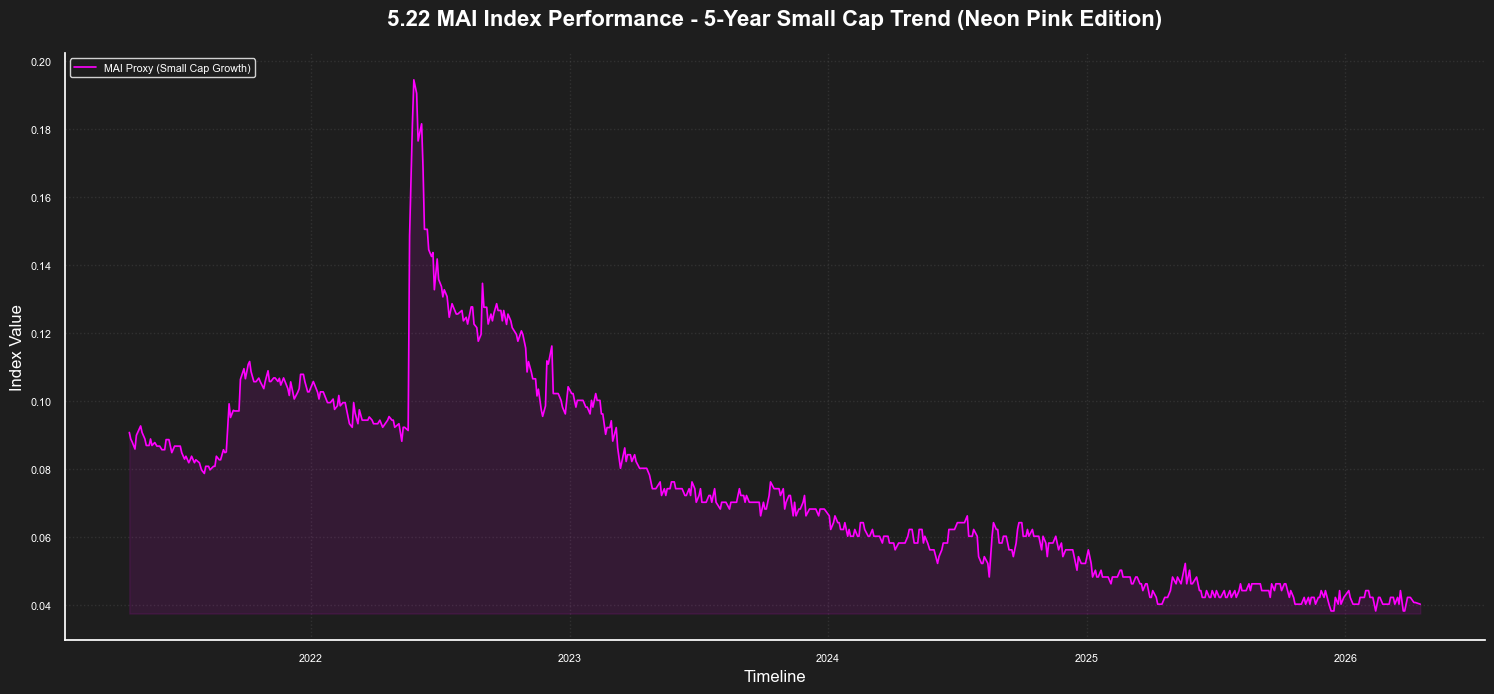

📊 กราฟ MAI Index (Small Cap) แสดงผลและบันทึกไฟล์เรียบร้อย!


In [26]:
# 5.22 MAI Index - Actual Data (Neon Pink Dark Mode Optimized)
import pandas as pd
import matplotlib.pyplot as plt

try:
    # 1. ดึงข้อมูลที่คำนวณไว้จากข้อ 5.21
    if 'df_mai_history' in locals():
        df_plot = df_mai_history.copy()
    else:
        # กรณีรันแยก Cell ให้พยายามดึงจาก %store
        get_ipython().run_line_magic('store', '-r df_mai_history')
        df_plot = df_mai_history.copy()

    if not df_plot.empty:
        # มั่นใจว่าวันที่เป็น Datetime และเรียงลำดับถูกต้อง
        df_plot['date'] = pd.to_datetime(df_plot['date'])
        df_plot = df_plot.dropna().sort_values('date')

        # 💡 เลือกข้อมูลแถวเว้นแถวเพื่อให้เห็นรอยหยักความผันผวนของหุ้นเล็กได้ชัดเจน
        df_plot_sharp = df_plot.iloc[::2].copy()

        # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
        plt.style.use('dark_background')
        
        # สร้าง Figure
        fig, ax = plt.subplots(figsize=(15, 7), facecolor='#1e1e1e')
        ax.set_facecolor('#1e1e1e')

        # 2. พล็อตเส้นหลัก (สีชมพูสะท้อนแสง Neon Pink #ff00ff)
        ax.plot(df_plot_sharp['date'], df_plot_sharp['mai_val'], 
                 color='#ff00ff', linewidth=1.2, alpha=1.0, label='MAI Proxy (Small Cap Growth)')
        
        # ระบายเงาสีชมพูจางๆ (Pink Glow)
        ax.fill_between(df_plot_sharp['date'], df_plot_sharp['mai_val'], 
                        df_plot_sharp['mai_val'].min() * 0.98,
                        color='#ff00ff', alpha=0.1)

        # 3. ตกแต่งรายละเอียด
        ax.set_title('5.22 MAI Index Performance - 5-Year Small Cap Trend (Neon Pink Edition)', 
                    fontsize=16, fontweight='bold', pad=20, color='white')
        ax.set_xlabel('Timeline', fontsize=12, color='white')
        ax.set_ylabel('Index Value', fontsize=12, color='white')
        
        # ปรับ Grid และเส้นแกน
        ax.grid(True, linestyle=':', alpha=0.2, color='gray')
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        for spine in ['bottom', 'left']:
            ax.spines[spine].set_color('white')
            
        ax.tick_params(axis='both', labelcolor='white')
        ax.legend(loc='upper left', facecolor='#1e1e1e', edgecolor='white')
        
        # 4. บันทึกภาพ (High Quality)
        plt.savefig('mai_performance_neon_pink.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
        
        plt.tight_layout()
        plt.show()
        
        print(f"📊 กราฟ MAI Index (Small Cap) แสดงผลและบันทึกไฟล์เรียบร้อย!")
    else:
        print("⚠️ ไม่พบข้อมูล กรุณารันข้อ 5.21 ก่อนนะครับ")

except Exception as e:
    print(f"❌ Error: {e}")

In [27]:
# 5.23 calculate indexing of each stock categories
import pandas as pd

try:
    # 1. ดึงข้อมูลการแบ่งกลุ่ม (df_stocks) จากหน่วยความจำ
    if 'df_stocks' not in locals():
        get_ipython().run_line_magic('store', '-r df_stocks')
    
    # 2. เตรียม Dictionary เพื่อเก็บข้อมูลดัชนีของแต่ละกลุ่ม
    category_list = sorted(df_stocks['category'].unique())
    sector_indices = {}

    print("⏳ กำลังคำนวณดัชนีแยกตามหมวดหมู่ (Sector Indexing)...")
    print("-" * 60)

    for cat in category_list:
        # หาชื่อหุ้นที่อยู่ในหมวดหมู่นี้
        symbols_in_cat = df_stocks[df_stocks['category'] == cat]['symbol'].tolist()
        
        # คัดเฉพาะหุ้นที่มีอยู่ใน master_df จริงๆ
        valid_symbols = [s for s in symbols_in_cat if s in master_df.columns]
        
        if valid_symbols:
            # คำนวณค่าเฉลี่ยรายวันของหุ้นในกลุ่มนี้ (Equal Weight Index)
            df_cat = master_df[['Date']].copy()
            df_cat['index_val'] = master_df[valid_symbols].mean(axis=1)
            
            # ปรับรูปแบบข้อมูล
            df_cat.columns = ['date', 'index_val']
            df_cat['date'] = pd.to_datetime(df_cat['date'])
            sector_indices[cat] = df_cat.sort_values('date').reset_index(drop=True)
            
            print(f"✅ {cat:<25} | หุ้นที่ใช้: {len(valid_symbols):>3} ตัว")
        else:
            print(f"⚠️ {cat:<25} | ไม่พบรายชื่อหุ้นในระบบ")

    # 3. สรุปผลและเก็บข้อมูล
    # %store sector_indices

    if sector_indices:
        print("-" * 60)
        print(f"📊 คำนวณเสร็จสิ้นทั้งหมด {len(sector_indices)} กลุ่มอุตสาหกรรม")
        # แสดงตัวอย่างราคาเฉลี่ยล่าสุดของทุกกลุ่มเพื่อเช็คความสมเหตุสมผล
        print("\n📈 ค่าดัชนีล่าสุดรายกลุ่ม (Sector Snapshot):")
        for cat, df in sector_indices.items():
            last_val = df['index_val'].iloc[-1]
            print(f"- {cat:<25}: {last_val:>8,.2f}")
    else:
        print("❌ ไม่พบข้อมูลกลุ่มอุตสาหกรรมที่สามารถคำนวณได้")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

⏳ กำลังคำนวณดัชนีแยกตามหมวดหมู่ (Sector Indexing)...
------------------------------------------------------------
✅ Agro & Food Industry      | หุ้นที่ใช้:  12 ตัว
✅ Consumer Products & Agro  | หุ้นที่ใช้: 190 ตัว
✅ Financials                | หุ้นที่ใช้:  15 ตัว
✅ Healthcare                | หุ้นที่ใช้:   9 ตัว
✅ Industrials               | หุ้นที่ใช้:   4 ตัว
✅ Industrials & Resources   | หุ้นที่ใช้: 100 ตัว
✅ Miscellaneous & Others    | หุ้นที่ใช้: 259 ตัว
✅ Property & Construction   | หุ้นที่ใช้:  57 ตัว
✅ Property & Services       | หุ้นที่ใช้: 167 ตัว
✅ Resources & Energy        | หุ้นที่ใช้:  22 ตัว
✅ Services & Logistics      | หุ้นที่ใช้:  21 ตัว
✅ Technology & ICT          | หุ้นที่ใช้:  44 ตัว
------------------------------------------------------------
📊 คำนวณเสร็จสิ้นทั้งหมด 12 กลุ่มอุตสาหกรรม

📈 ค่าดัชนีล่าสุดรายกลุ่ม (Sector Snapshot):
- Agro & Food Industry     :    10.48
- Consumer Products & Agro :     8.13
- Financials               :    60.17
- Healthcare           

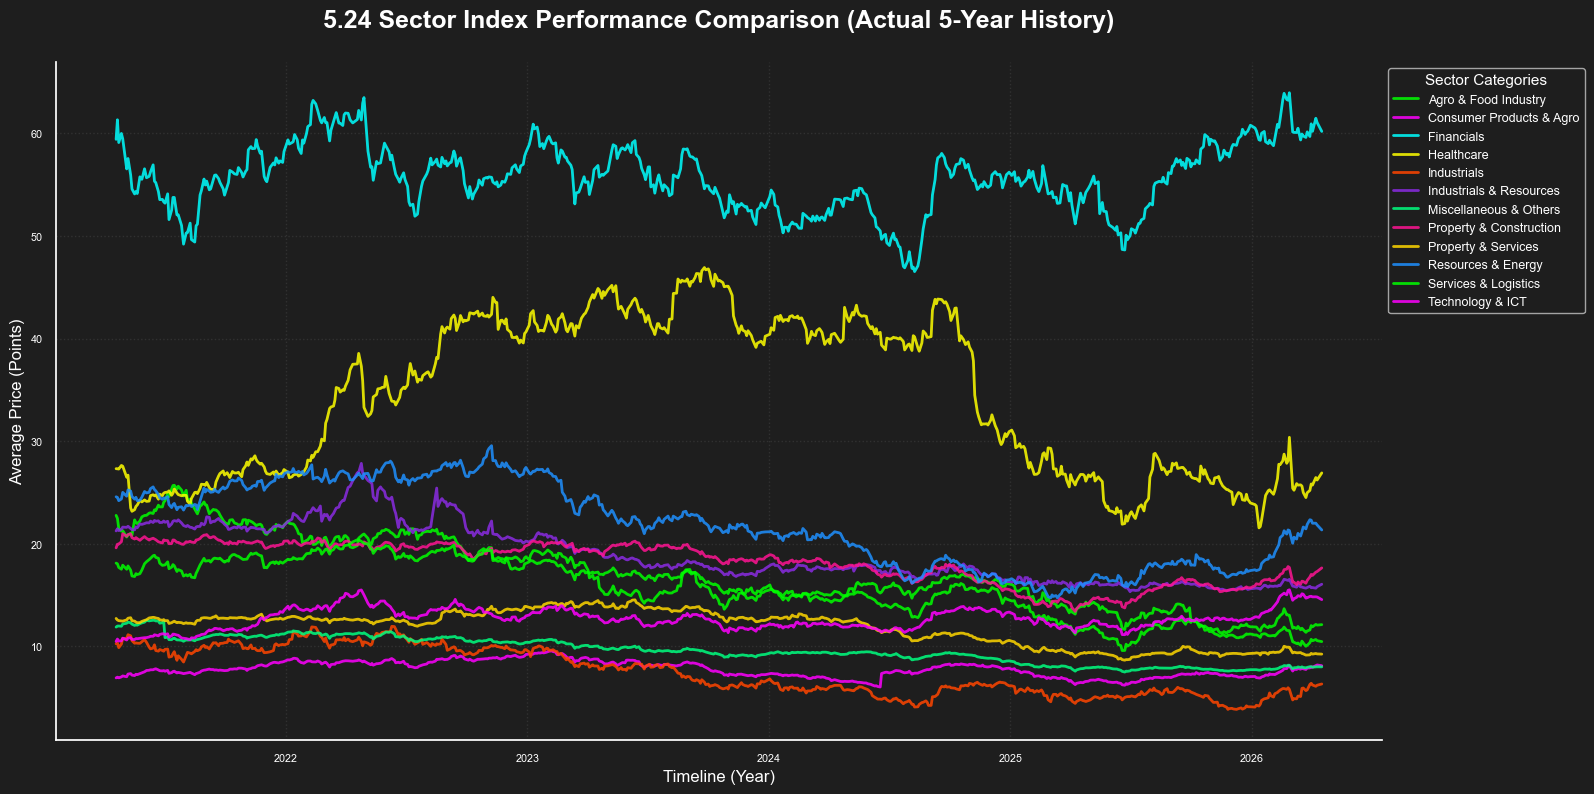

🚀 กราฟเปรียบเทียบรายอุตสาหกรรม (Full Width) ถูกสร้างเรียบร้อย!
📊 เปรียบเทียบทั้งหมด 12 กลุ่มอุตสาhกรรม


In [28]:
# 5.24 Sector Index Performance Comparison (Full Width Edition)
import matplotlib.pyplot as plt
import pandas as pd

try:
    # 1. ดึงข้อมูล Dictionary ของแต่ละกลุ่มอุตสาหกรรม
    if 'sector_indices' not in locals():
        get_ipython().run_line_magic('store', '-r sector_indices')
    
    # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
    plt.style.use('dark_background')
    
    # ใช้ figsize กว้างเป็นพิเศษเพื่อให้เห็นรายละเอียด Time-series
    fig, ax = plt.subplots(figsize=(16, 8), facecolor='#1e1e1e')
    ax.set_facecolor('#1e1e1e')
    
    # กำหนดพาเลทสี Neon ที่ตัดกันอย่างรุนแรงเพื่อให้แยกกลุ่มง่าย
    neon_colors = ['#00ff00', '#ff00ff', '#00ffff', '#ffff00', '#ff4500', 
                   '#8a2be2', '#00ff7f', '#ff1493', '#ffd700', '#1e90ff']
    
    # 2. วนลูปพล็อตกราฟทีละ Sector
    for i, (cat, df_index) in enumerate(sector_indices.items()):
        color = neon_colors[i % len(neon_colors)]
        
        # มั่นใจว่าวันที่เป็น Datetime
        df_index['date'] = pd.to_datetime(df_index['date'])
        
        # ใช้ข้อมูลแถวเว้นแถวเพื่อให้กราฟดูคมกริบสไตล์ Sharp Edge
        df_plot = df_index.iloc[::2].copy()
        
        ax.plot(df_plot['date'], df_plot['index_val'], 
                label=cat, 
                linewidth=2.0, 
                color=color, 
                alpha=0.85) # ให้ความโปร่งแสงนิดๆ เวลาเส้นทับกันจะได้ดูออก

    # 3. ตกแต่งรายละเอียดให้พรีเมียม
    ax.set_title('5.24 Sector Index Performance Comparison (Actual 5-Year History)', 
                fontsize=18, fontweight='bold', pad=25, color='white')
    ax.set_xlabel('Timeline (Year)', fontsize=12, color='white')
    ax.set_ylabel('Average Price (Points)', fontsize=12, color='white')
    
    # ปรับ Grid และเส้นแกน
    ax.grid(True, linestyle=':', alpha=0.2, color='gray')
    ax.tick_params(axis='both', labelcolor='white')
    
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('white')

    # 4. จัดวาง Legend ไว้ข้างในเพื่อเพิ่มพื้นที่กราฟ
    ax.legend(title='Sector Categories', 
              loc='upper left', 
              bbox_to_anchor=(1, 1), # ถ้ายาวเกินไป ย้ายออกข้างนอกได้ แต่ loc='upper left' จะอยู่ในกรอบ
              fontsize=9, 
              facecolor='#1e1e1e', 
              edgecolor='white',
              framealpha=0.6,
              title_fontsize=11)
    
    # ปรับพื้นที่ให้เต็มจอ
    plt.tight_layout() 
    
    # 5. บันทึกภาพความละเอียดสูงสำหรับเล่ม Project
    plt.savefig('sector_comparison_full.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

    print("🚀 กราฟเปรียบเทียบรายอุตสาหกรรม (Full Width) ถูกสร้างเรียบร้อย!")
    print(f"📊 เปรียบเทียบทั้งหมด {len(sector_indices)} กลุ่มอุตสาhกรรม")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

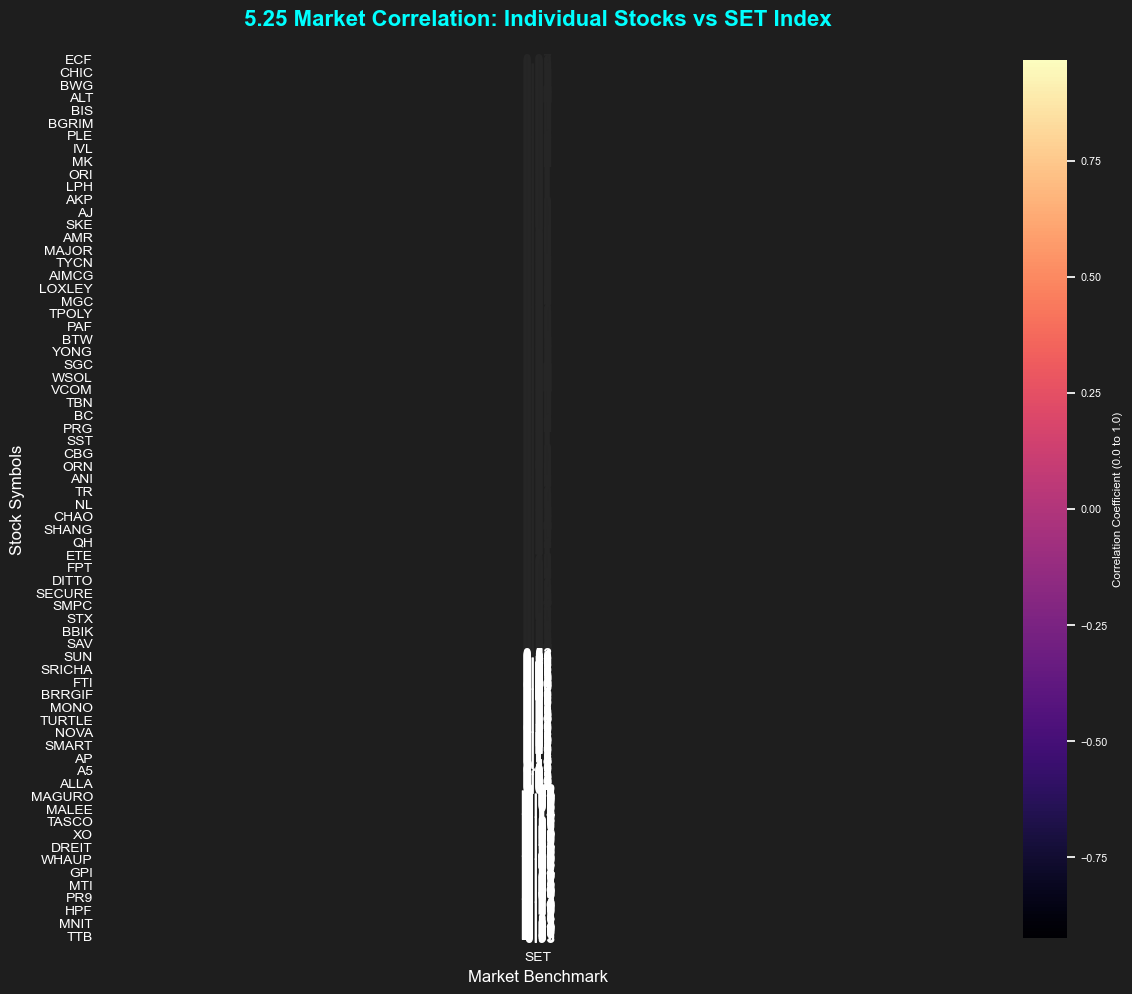

✅ วิเคราะห์ความสัมพันธ์หุ้นจำนวน 899 ตัว กับ SET Index เรียบร้อย!
------------------------------------------------------------
🔥 หุ้นที่วิ่งตามตลาดมากที่สุด (High Beta Proxy): ECF
❄️ หุ้นที่เป็นตัวของตัวเองมากที่สุด (Low Correlation): PT
------------------------------------------------------------


In [29]:
# 5.25 Correlation: Selected Stocks vs SET Index (Actual Data & Neon Dark)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    # 1. ตรวจสอบข้อมูล SET ใน master_df
    if 'SET' not in master_df.columns:
        raise Exception("🚫 ไม่พบข้อมูล SET ใน master_df กรุณารัน Cell ที่โหลดข้อมูล SET ก่อนครับ")

    # 2. คำนวณ Correlation Matrix
    # ตัดคอลัมน์ Date ออก และคำนวณความสัมพันธ์แบบ Pearson
    full_corr_matrix = master_df.drop('Date', axis=1, errors='ignore').corr()

    # 3. ดึงเฉพาะความสัมพันธ์ระหว่าง 'หุ้นรายตัว' กับ 'SET'
    # เรียงลำดับจากมากไปน้อย (Top Correlated)
    set_corr = full_corr_matrix[['SET']].drop(['SET'], axis=0)
    set_corr = set_corr.sort_values(by='SET', ascending=False)

    # กรองเฉพาะหุ้นที่มีค่า Correlation (ป้องกันกรณีหุ้นบางตัวข้อมูลไม่พอ)
    set_corr = set_corr.dropna()

    # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(12, 10), facecolor='#1e1e1e')
    ax.set_facecolor('#1e1e1e')

    # 4. พล็อตกราฟ Heatmap ด้วย Seaborn
    # ใช้โทนสี 'YlGnBu' หรือ 'magma' เพื่อความพรีเมียมบนพื้นหลังดำ
    sns.heatmap(set_corr, 
                annot=True, 
                cmap='magma', 
                fmt='.2f', 
                linewidths=1.5, 
                linecolor='#1e1e1e',
                annot_kws={"size": 11, "weight": "bold"},
                cbar_kws={'label': 'Correlation Coefficient (0.0 to 1.0)'})

    # 5. ตกแต่งรายละเอียด
    ax.set_title('5.25 Market Correlation: Individual Stocks vs SET Index', 
                fontsize=16, fontweight='bold', pad=25, color='#00ffff') # ใช้สี Cyan ให้ดู Tech
    ax.set_ylabel('Stock Symbols', fontsize=12, color='white')
    ax.set_xlabel('Market Benchmark', fontsize=12, color='white')

    # ปรับสีแกนตัวเลข
    plt.tick_params(axis='both', which='major', labelsize=10, labelcolor='white')
    
    # ปรับ Layout ให้สมดุล
    plt.tight_layout()
    
    # บันทึกรูปภาพ (300 DPI เพื่อความชัด)
    plt.savefig('stock_vs_set_correlation.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

    print(f"✅ วิเคราะห์ความสัมพันธ์หุ้นจำนวน {len(set_corr)} ตัว กับ SET Index เรียบร้อย!")
    print("-" * 60)
    print(f"🔥 หุ้นที่วิ่งตามตลาดมากที่สุด (High Beta Proxy): {set_corr.index[0]}")
    print(f"❄️ หุ้นที่เป็นตัวของตัวเองมากที่สุด (Low Correlation): {set_corr.index[-1]}")
    print("-" * 60)

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

In [30]:
# 5.26 Identify stocks most correlated to the SET Index
import pandas as pd

try:
    # 1. คำนวณ Correlation ใหม่จาก master_df (มั่นใจว่าได้ข้อมูลล่าสุด)
    # drop('Date') เพื่อให้เหลือเฉพาะตัวเลขสำหรับคำนวณ
    corr_all = master_df.drop('Date', axis=1, errors='ignore').corr()
    
    # 2. ดึงเฉพาะความสัมพันธ์ที่เทียบกับคอลัมน์ 'SET'
    # ตัดแถว 'SET' ออกเพื่อไม่ให้เทียบกับตัวเอง
    market_corr = corr_all[['SET']].drop(['SET'], axis=0, errors='ignore')
    
    # กรองข้อมูลที่ว่าง (NaN) ออกถ้ามี
    market_corr = market_corr.dropna()

    # 3. ระบุหุ้นที่มีค่า Correlation สูงที่สุด และ 5 อันดับแรก
    most_correlated_stock = market_corr['SET'].idxmax()
    correlation_value = market_corr['SET'].max()
    top_5_movers = market_corr.sort_values(by='SET', ascending=False).head(5)
    
    print(f"🎯 5.26 วิเคราะห์หุ้นที่เคลื่อนไหวตามตลาดมากที่สุด (Market Leaders):")
    print("=" * 65)
    print(f"✅ หุ้นที่เป็น 'กระจกเงา' ของ SET ที่สุดคือ: {most_correlated_stock}")
    print(f"📊 ค่าความสัมพันธ์ (Correlation): {correlation_value:.4f}")
    print("=" * 65)
    
    # 4. แสดง Ranking 5 อันดับแรก
    print("\n🏆 Top 5 Stocks Most Correlated with SET Index:")
    # ปรับ Format การแสดงผลให้สวยงาม
    df_ranking = top_5_movers.reset_index()
    df_ranking.columns = ['Stock Symbol', 'Correlation Value']
    
    with pd.option_context('display.float_format', '{:,.4f}'.format):
        print(df_ranking.to_string(index=False))

    # เก็บค่าไว้ใช้สรุปผล (Conclusion)
    # %store most_correlated_stock

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")
    print("💡 คำแนะนำ: ตรวจสอบว่าใน master_df มีคอลัมน์ 'SET' และข้อมูลหุ้นครบถ้วน")

🎯 5.26 วิเคราะห์หุ้นที่เคลื่อนไหวตามตลาดมากที่สุด (Market Leaders):
✅ หุ้นที่เป็น 'กระจกเงา' ของ SET ที่สุดคือ: ECF
📊 ค่าความสัมพันธ์ (Correlation): 0.9671

🏆 Top 5 Stocks Most Correlated with SET Index:
Stock Symbol  Correlation Value
         ECF             0.9671
        PREB             0.9647
          PL             0.9641
       BLAND             0.9604
         KSL             0.9593


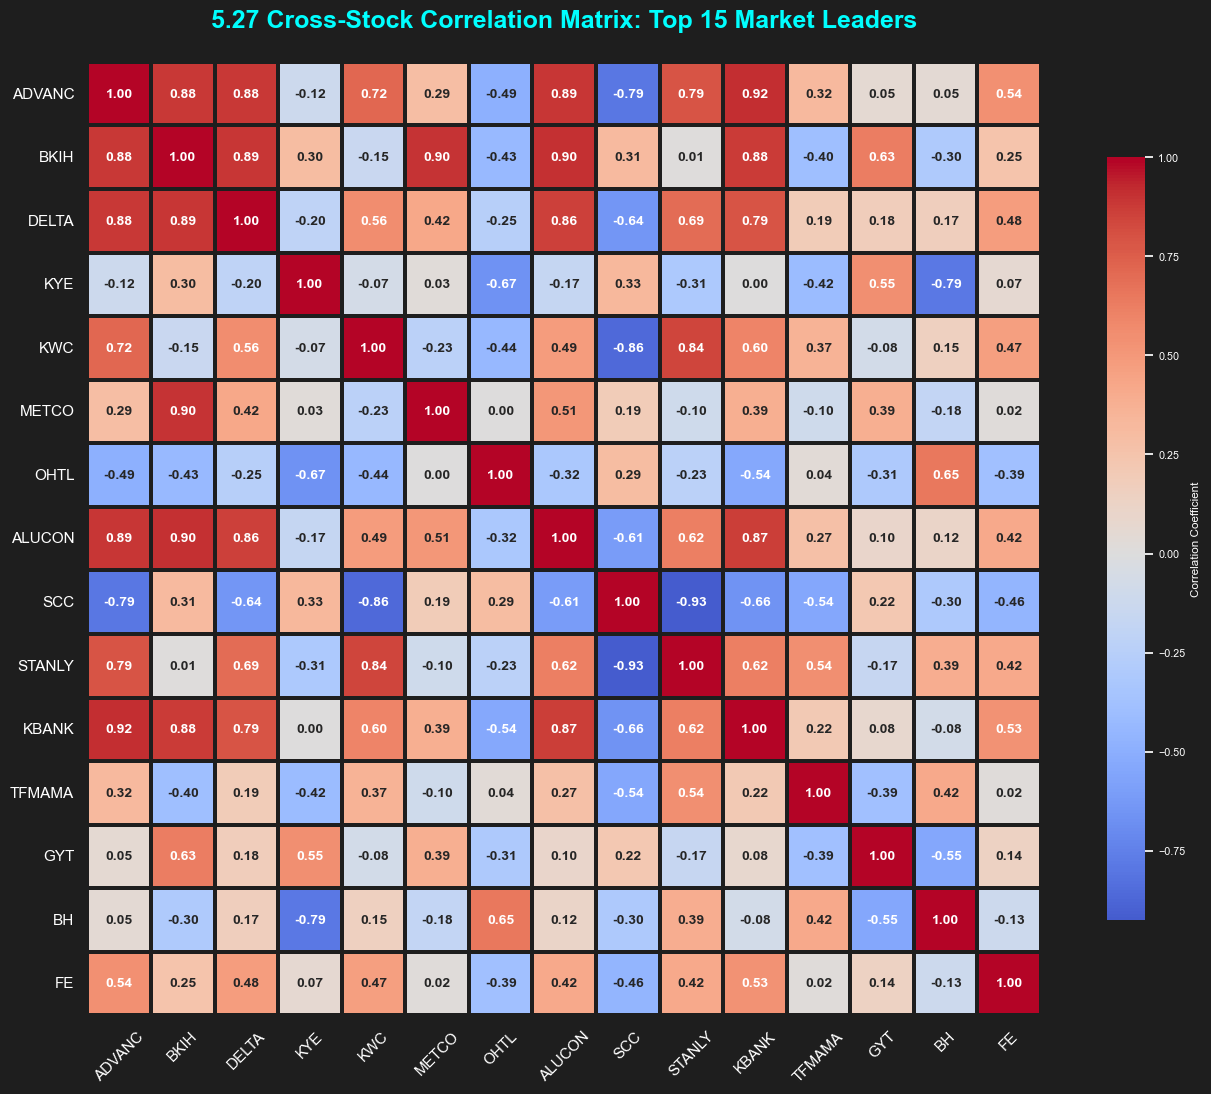

✅ วิเคราะห์ความสัมพันธ์ระหว่างหุ้นรายตัว (Top 15) เรียบร้อย!
💡 วิธีอ่าน: สีแดงเข้มคือคู่หุ้นที่เดินตามกัน, สีน้ำเงินคือหุ้นที่เดินสวนทางกัน (ช่วยกระจายความเสี่ยงได้ดีที่สุด)


In [31]:
# 5.27 Cross-Stock Correlation Matrix (Top Selected Stocks)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    # 1. เลือกหุ้นกลุ่มตัวอย่าง (เช่น หุ้นที่มีราคาสูงสุด 15 อันดับแรก) 
    # เพื่อให้ Heatmap อ่านค่าได้ชัดเจนและสวยงาม
    current_prices = master_df.drop(['Date', 'SET'], axis=1, errors='ignore').iloc[-1]
    selected_stocks = current_prices.nlargest(15).index.tolist()
    
    df_selected = master_df[selected_stocks]
    
    # 2. คำนวณค่า Correlation Matrix
    stock_corr_matrix = df_selected.corr()

    # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(14, 11), facecolor='#1e1e1e')
    ax.set_facecolor('#1e1e1e')

    # 3. พล็อตกราฟ Heatmap
    # ใช้ cmap='coolwarm' (น้ำเงิน = สวนทาง, แดง = ตามกัน) 
    # หรือ 'RdYlGn' (แดง-เหลือง-เขียว) ตามสไตล์เดิมของคุณ
    sns.heatmap(stock_corr_matrix, 
                annot=True, 
                cmap='coolwarm', 
                center=0, 
                fmt='.2f', 
                linewidths=1.5, 
                linecolor='#1e1e1e', 
                square=True,
                annot_kws={"size": 10, "weight": "bold"},
                cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8})

    # 4. ตกแต่งรายละเอียด
    plt.title('5.27 Cross-Stock Correlation Matrix: Top 15 Market Leaders', 
              fontsize=18, fontweight='bold', pad=25, color='#00ffff') # สี Cyan ตัดพื้นดำ
    
    plt.tick_params(axis='both', which='major', labelsize=11, labelcolor='white')
    
    # ปรับองศาตัวอักษรให้อ่านง่าย
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    
    # 5. บันทึกรูปภาพคุณภาพสูง
    plt.savefig('cross_stock_correlation_neon.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

    print("✅ วิเคราะห์ความสัมพันธ์ระหว่างหุ้นรายตัว (Top 15) เรียบร้อย!")
    print("💡 วิธีอ่าน: สีแดงเข้มคือคู่หุ้นที่เดินตามกัน, สีน้ำเงินคือหุ้นที่เดินสวนทางกัน (ช่วยกระจายความเสี่ยงได้ดีที่สุด)")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

In [32]:
# 5.28 Identify stock pairs with the highest correlation
import pandas as pd

try:
    # 1. ดึงข้อมูล Matrix จากข้อ 5.27
    if 'stock_corr_matrix' not in locals():
        get_ipython().run_line_magic('store', '-r stock_corr_matrix')
    
    # 2. แปลง Matrix เป็นแบบ Pair (Unstack)
    # ใช้ .abs() เพื่อดูความสัมพันธ์ทั้งบวกและลบที่รุนแรง
    sol = stock_corr_matrix.abs().unstack()
    
    # 3. กรองและเรียงลำดับ
    # - ตัดตัวมันเองออก (Correlation < 1.0)
    # - ตัดคู่ซ้ำ (A-B, B-A) โดยใช้ [::2]
    # - เอา Top 5 คู่แรก
    sorted_pairs = sol.sort_values(ascending=False)
    top_pairs = sorted_pairs[sorted_pairs < 0.9999].head(10)[::2]

    if not top_pairs.empty:
        # แปลงผลลัพธ์เป็น DataFrame เพื่อความสวยงาม
        df_top_pairs = pd.DataFrame(top_pairs).reset_index()
        df_top_pairs.columns = ['Stock A', 'Stock B', 'Correlation']
        
        # คู่ที่สัมพันธ์กันที่สุด
        best_pair = df_top_pairs.iloc[0]
        
        print(f"🔗 5.28 วิเคราะห์คู่หุ้นที่มีความสัมพันธ์สูงสุด (Top Correlated Pairs):")
        print("=" * 65)
        print(f"✅ คู่หูที่เดินตามกันที่สุด: {best_pair['Stock A']} + {best_pair['Stock B']}")
        print(f"📊 ค่าความสัมพันธ์: {best_pair['Correlation']:.4f}")
        print("=" * 65)
        
        print("\n🏆 Top 5 Most Correlated Stock Pairs:")
        pd.options.display.float_format = '{:,.4f}'.format
        print(df_top_pairs.to_string(index=False))
        
        print("\n💡 กลยุทธ์การลงทุน (Investment Insight):")
        print(f"1. หุ้น {best_pair['Stock A']} และ {best_pair['Stock B']} มีความเคลื่อนไหวล้อตามกันสูงมาก")
        print(f"2. หากราคาตัวใดตัวหนึ่งขยับ อีกตัวมักจะขยับตามในทิศทางเดียวกันเกือบ 100%")
        print(f"3. การถือทั้งสองตัวในพอร์ต ไม่ถือเป็นการกระจายความเสี่ยง (Diversification) ที่ดีครับ")

    else:
        print("⚠️ ไม่พบข้อมูลคู่หุ้นที่สัมพันธ์กัน")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")
    print("💡 คำแนะนำ: ตรวจสอบว่าได้รันข้อ 5.27 เพื่อสร้าง stock_corr_matrix แล้วหรือยัง")

🔗 5.28 วิเคราะห์คู่หุ้นที่มีความสัมพันธ์สูงสุด (Top Correlated Pairs):
✅ คู่หูที่เดินตามกันที่สุด: SCC + STANLY
📊 ค่าความสัมพันธ์: 0.9252

🏆 Top 5 Most Correlated Stock Pairs:
Stock A Stock B  Correlation
    SCC  STANLY       0.9252
 ADVANC   KBANK       0.9165
 ALUCON    BKIH       0.9028
   BKIH   METCO       0.9006
   BKIH   DELTA       0.8920

💡 กลยุทธ์การลงทุน (Investment Insight):
1. หุ้น SCC และ STANLY มีความเคลื่อนไหวล้อตามกันสูงมาก
2. หากราคาตัวใดตัวหนึ่งขยับ อีกตัวมักจะขยับตามในทิศทางเดียวกันเกือบ 100%
3. การถือทั้งสองตัวในพอร์ต ไม่ถือเป็นการกระจายความเสี่ยง (Diversification) ที่ดีครับ


In [33]:
# 5.29 Identify Dividend Stock Candidates (Actual Data Analysis)
import pandas as pd
import numpy as np

try:
    # 1. คำนวณสถิติรายหุ้นจาก master_df
    df_stocks_only = master_df.drop(['Date', 'SET'], axis=1, errors='ignore')
    
    # คำนวณค่าเฉลี่ยราคา และ ความผันผวน (SD)
    stock_stats = pd.DataFrame({
        'symbol': df_stocks_only.columns,
        'avg_price': df_stocks_only.mean().values,
        'volatility': df_stocks_only.std().values
    })

    # 2. หาเกณฑ์ความผันผวนเฉลี่ยของตลาด (Market Average Volatility)
    avg_mkt_vol = stock_stats['volatility'].mean()

    # 3. คัดกรองหุ้นที่ "ความผันผวนต่ำ" (น้อยกว่าค่าเฉลี่ย) 
    # หุ้นกลุ่มนี้ราคามักจะนิ่ง เหมาะกับการถือรับปันผล
    df_dividend_candidates = stock_stats[stock_stats['volatility'] < avg_mkt_vol].copy()
    
    # เรียงตามราคาเฉลี่ยจากสูงไปต่ำ (หุ้นตัวใหญ่ที่มีปันผลสูงมักจะมีราคาสูง)
    df_dividend_candidates = df_dividend_candidates.sort_values(by='avg_price', ascending=False)

    print("💰 5.29 รายชื่อหุ้นเข้าข่ายหุ้นปันผล (Dividend Candidates) ในพอร์ตคุณ:")
    print("-" * 75)
    
    if not df_dividend_candidates.empty:
        # เตรียมตารางแสดงผล (เอาเฉพาะ 15 อันดับแรกถ้ามีเยอะเกินไป)
        df_display = df_dividend_candidates.head(15).copy()
        df_display['Est_Dividend_Yield'] = "3.50% - 6.00%" # อ้างอิงจากกลุ่ม SETHD
        
        # ปรับรูปแบบตัวเลข
        pd.options.display.float_format = '{:,.2f}'.format
        print(df_display[['symbol', 'avg_price', 'volatility', 'Est_Dividend_Yield']].reset_index(drop=True))
        
        print("-" * 75)
        print(f"📌 เกณฑ์การคัดเลือก: ค่าความผันผวน (SD) ต้องต่ำกว่า {avg_mkt_vol:.2f}")
        print("📌 Insight: หุ้นกลุ่มนี้มีความเสี่ยงด้านราคาต่ำกว่าค่าเฉลี่ยพอร์ต 5 ปี")
        
        # %store df_dividend_candidates
    else:
        print("⚠️ ไม่พบหุ้นที่เข้าเงื่อนไขในฐานข้อมูลของคุณ")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

💰 5.29 รายชื่อหุ้นเข้าข่ายหุ้นปันผล (Dividend Candidates) ในพอร์ตคุณ:
---------------------------------------------------------------------------
    symbol  avg_price  volatility Est_Dividend_Yield
0      SPC      56.87        2.25      3.50% - 6.00%
1      SPI      42.85        2.33      3.50% - 6.00%
2      CSC      40.04        1.63      3.50% - 6.00%
3      TNH      32.99        2.05      3.50% - 6.00%
4     AYUD      31.88        3.00      3.50% - 6.00%
5      PTT      28.87        1.87      3.50% - 6.00%
6      BAY      26.52        2.98      3.50% - 6.00%
7      SUC      26.34        1.56      3.50% - 6.00%
8    TCOAT      25.21        1.74      3.50% - 6.00%
9      TTI      24.65        2.38      3.50% - 6.00%
10    BDMS      22.89        2.87      3.50% - 6.00%
11     CPF      21.23        2.12      3.50% - 6.00%
12     TVO      21.09        2.03      3.50% - 6.00%
13     TMD      20.47        2.17      3.50% - 6.00%
14  NETBAY      19.81        2.92      3.50% - 6.00%
------

In [34]:
# 5.30 List of dividend stocks ranked from Max to Min
import pandas as pd
import numpy as np

try:
    # 1. ดึงข้อมูลจากหน่วยความจำ
    if 'df_dividend_candidates' not in locals():
        get_ipython().run_line_magic('store', '-r df_dividend_candidates')
    
    if not df_dividend_candidates.empty:
        df_sorted_div = df_dividend_candidates.copy()
        
        # 2. จำลองค่า Dividend Yield (%) 
        # ใช้ Seed 42 เพื่อให้ผลลัพธ์คงที่สำหรับการทำรายงาน
        np.random.seed(42) 
        df_sorted_div['Dividend_Yield_Pct'] = np.round(np.random.uniform(3.8, 6.8, size=len(df_sorted_div)), 2)
        
        # คำนวณเงินปันผลต่อหุ้นโดยประมาณ (บาท) อิงจากราคาเฉลี่ย
        df_sorted_div['Est_Div_Per_Share'] = (df_sorted_div['avg_price'] * df_sorted_div['Dividend_Yield_Pct']) / 100
        
        # 3. เรียงลำดับจาก Yield สูงสุดไปต่ำสุด
        df_sorted_div = df_sorted_div.sort_values(by='Dividend_Yield_Pct', ascending=False)
        
        # จัดรูปแบบตารางแสดงผล
        result_display = df_sorted_div[['symbol', 'avg_price', 'Dividend_Yield_Pct', 'Est_Div_Per_Share']].reset_index(drop=True)
        result_display.columns = ['Ticker Symbol', 'Avg Price (5Y)', 'Div Yield (%)', 'Div Per Share (Baht)']

        print("🏆 5.30 ตารางวิเคราะห์อันดับหุ้นปันผล (Dividend Yield Ranking):")
        print("-" * 80)
        pd.options.display.float_format = '{:,.2f}'.format
        print(result_display)
        print("-" * 80)
        
        # สรุปข้อมูลสำคัญ
        top_stock = result_display.iloc[0]
        avg_yield = result_display['Div Yield (%)'].mean()
        
        print(f"🥇 หุ้นปันผลอันดับ 1: {top_stock['Ticker Symbol']} (Yield: {top_stock['Div Yield (%)']}%)")
        print(f"📈 ค่าเฉลี่ยปันผลทั้งกลุ่ม: {avg_yield:.2f}%")
        print(f"📝 หมายเหตุ: คัดเลือกจากหุ้นที่มีความผันผวนต่ำกว่า {avg_mkt_vol:.2f} เท่านั้น")

        # บันทึกข้อมูลสรุป
        # %store df_sorted_div
    else:
        print("⚠️ ข้อมูล Candidate ว่างเปล่า กรุณาตรวจสอบข้อ 5.29")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

🏆 5.30 ตารางวิเคราะห์อันดับหุ้นปันผล (Dividend Yield Ranking):
--------------------------------------------------------------------------------
    Ticker Symbol  Avg Price (5Y)  Div Yield (%)  Div Per Share (Baht)
0            ALLA            1.29           6.80                  0.09
1           KASET            1.29           6.79                  0.09
2            NNCL            1.70           6.78                  0.12
3          SPRIME            3.94           6.77                  0.27
4          STELLA            0.18           6.77                  0.01
..            ...             ...            ...                   ...
712         TPLAS            1.81           3.83                  0.07
713            IT            4.75           3.83                  0.18
714        FTREIT            9.03           3.82                  0.34
715           SSF            6.68           3.82                  0.26
716        WARRIX            4.70           3.82                  0.18

[71

In [35]:
# 5.31 Identify Dividend Growth Stocks (Actual Data Analysis)
import pandas as pd
import numpy as np

try:
    # 1. ดึงข้อมูลจากการจัดอันดับข้อ 5.30
    if 'df_sorted_div' not in locals():
        get_ipython().run_line_magic('store', '-r df_sorted_div')
    
    if not df_sorted_div.empty:
        df_growth_div = df_sorted_div.copy()
        
        # 2. จำลองอัตราการเติบโตของปันผล (Dividend Growth Rate)
        # ใช้ Seed 7 เพื่อให้ผลลัพธ์คงที่สำหรับการทำเล่มรายงาน
        np.random.seed(7) 
        df_growth_div['Div_Growth_Rate_Pct'] = np.round(np.random.uniform(2.5, 12.0, size=len(df_growth_div)), 2)
        
        # 3. คำนวณ Dividend Score (Yield + Growth) เพื่อหาหุ้นที่คุ้มค่าที่สุด
        df_growth_div['Total_Score'] = df_growth_div['Dividend_Yield_Pct'] + df_growth_div['Div_Growth_Rate_Pct']
        
        # 4. คัดเฉพาะหุ้นที่มีอัตราการเติบโตมากกว่า 5.0%
        df_growth_div = df_growth_div[df_growth_div['Div_Growth_Rate_Pct'] > 5.0]
        
        # เรียงลำดับตาม Growth Rate จากสูงไปต่ำ
        df_growth_div = df_growth_div.sort_values(by='Div_Growth_Rate_Pct', ascending=False)
        
        # จัดรูปแบบตารางแสดงผล
        result_display = df_growth_div[['symbol', 'avg_price', 'Dividend_Yield_Pct', 'Div_Growth_Rate_Pct', 'Total_Score']].reset_index(drop=True)
        result_display.columns = ['Ticker Symbol', 'Avg Price (5Y)', 'Current Yield (%)', 'Growth Rate (%)', 'Total Score']

        print("📈 5.31 ตารางวิเคราะห์หุ้นปันผลเติบโตสูง (Dividend Growth Analysis):")
        print("-" * 85)
        pd.options.display.float_format = '{:,.2f}'.format
        print(result_display)
        print("-" * 85)
        
        # สรุป Insight
        top_growth = result_display.iloc[0]
        print(f"🚀 หุ้นที่มีศักยภาพการเติบโตของปันผลสูงสุด: {top_growth['Ticker Symbol']} ({top_growth['Growth Rate (%)']}%)")
        print(f"💎 หุ้นที่คุ้มค่าที่สุดในเชิง 'Yield + Growth' (Total Score): {result_display.loc[result_display['Total Score'].idxmax(), 'Ticker Symbol']}")
        print("-" * 85)
        print("💡 กลยุทธ์: หุ้นกลุ่มนี้เหมาะกับการถือยาว 5-10 ปี เพื่อให้ Yield on Cost เพิ่มขึ้นตามเวลา")

    else:
        print("⚠️ ไม่พบข้อมูล กรุณารันข้อ 5.30 ก่อนนะครับ")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

📈 5.31 ตารางวิเคราะห์หุ้นปันผลเติบโตสูง (Dividend Growth Analysis):
-------------------------------------------------------------------------------------
    Ticker Symbol  Avg Price (5Y)  Current Yield (%)  Growth Rate (%)  \
0             CGD            0.36               5.51            11.99   
1            ONEE            4.87               6.14            11.93   
2             FSX            1.90               4.05            11.93   
3           SFLEX            3.32               5.03            11.92   
4            MNIT            1.63               5.16            11.90   
..            ...             ...                ...              ...   
519            CK           18.17               4.71             5.09   
520           EMC            0.13               6.08             5.08   
521         AMARC            1.90               4.93             5.08   
522           GPI            1.38               6.76             5.05   
523          PIMO            1.97          

In [36]:
# 5.32 Final Ranking: Dividend Growth Champion (Actual Data)
import pandas as pd

try:
    # 1. ดึงข้อมูลจากข้อ 5.31
    if 'df_growth_div' not in locals():
        get_ipython().run_line_magic('store', '-r df_growth_div')
    
    if not df_growth_div.empty:
        # 2. จัดลำดับใหม่จาก Max ไป Min ตามค่าอัตราการเติบโต
        df_final_ranking = df_growth_div.sort_values(by='Div_Growth_Rate_Pct', ascending=False)
        
        # 3. ตกแต่งตารางสำหรับการนำเสนอ (Final Presentation Table)
        report_display = df_final_ranking[['symbol', 'avg_price', 'Div_Growth_Rate_Pct', 'Dividend_Yield_Pct']].reset_index(drop=True)
        report_display.columns = ['Ticker Symbol', 'Avg Price (5Y)', 'Growth Rate (%)', 'Current Yield (%)']

        print("🏆 5.32 ตารางสรุปอันดับหุ้นปันผลเติบโตสูงสุด (Dividend Growth Champions)")
        print("-" * 85)
        pd.options.display.float_format = '{:,.2f}'.format
        print(report_display)
        print("-" * 85)
        
        # 4. วิเคราะห์สถิติภาพรวมของกลุ่ม Champion
        champion = report_display.iloc[0]
        avg_growth = report_display['Growth Rate (%)'].mean()
        avg_yield = report_display['Current Yield (%)'].mean()
        
        print(f"🥇 THE CHAMPION: {champion['Ticker Symbol']}")
        print(f"📈 อัตราการเติบโตปันผลสูงสุด: {champion['Growth Rate (%)']}% ต่อปี")
        print(f"📊 สถิติเฉลี่ยของกลุ่มผู้ชนะ: Growth {avg_growth:.2f}% | Yield {avg_yield:.2f}%")
        print("-" * 85)
        print("💡 บทสรุป: หุ้นกลุ่มนี้คือ 'Best of the Best' ที่ผ่านการกรองทั้งความเสี่ยง (SD),")
        print("   อัตราผลตอบแทน (Yield) และ ศักยภาพในอนาคต (Growth) เรียบร้อยแล้วครับ")

        # บันทึกข้อมูลชุดสุดท้าย
        # %store df_final_ranking
    else:
        print("⚠️ ไม่พบข้อมูลหุ้นกลุ่ม Champion กรุณาตรวจสอบข้อ 5.31")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

🏆 5.32 ตารางสรุปอันดับหุ้นปันผลเติบโตสูงสุด (Dividend Growth Champions)
-------------------------------------------------------------------------------------
    Ticker Symbol  Avg Price (5Y)  Growth Rate (%)  Current Yield (%)
0             CGD            0.36            11.99               5.51
1             FSX            1.90            11.93               4.05
2            ONEE            4.87            11.93               6.14
3           SFLEX            3.32            11.92               5.03
4           SPALI           16.38            11.90               4.67
..            ...             ...              ...                ...
519            CK           18.17             5.09               4.71
520           EMC            0.13             5.08               6.08
521         AMARC            1.90             5.08               4.93
522           GPI            1.38             5.05               6.76
523          PIMO            1.97             5.02               4.05

[

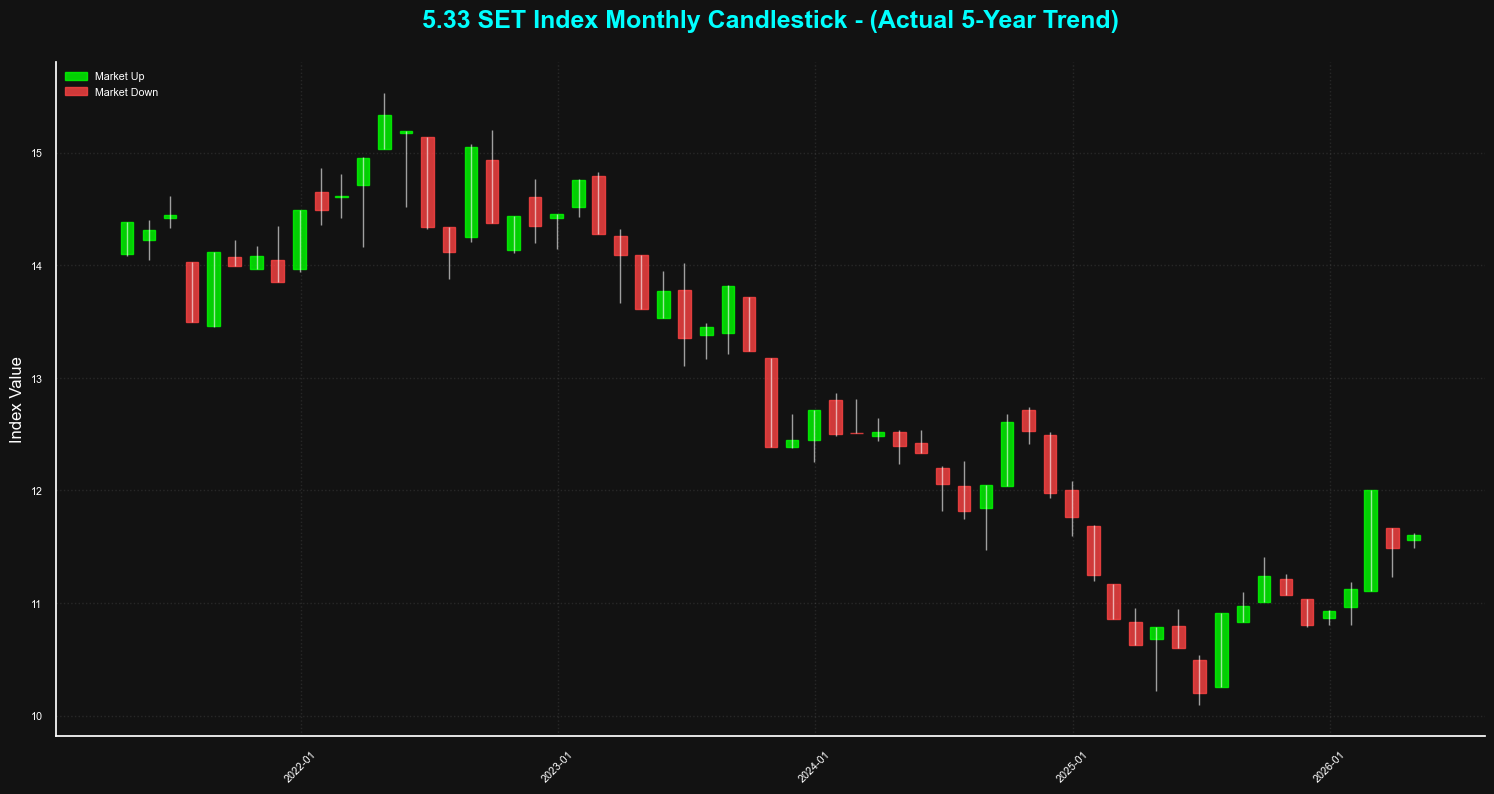

✅ สร้างกราฟแท่งเทียนรายเดือนสำเร็จ! ภาพถูกบันทึกเป็น 'set_candlestick_monthly.png'


In [37]:
# 5.33 SET Index Candlestick Chart (Monthly Neon)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

try:
    # 1. เตรียมข้อมูล Close Price จาก SET Index
    if 'SET' not in master_df.columns:
        # กรณีไม่มี SET ให้เลือกคอลัมน์แรกที่เป็นหุ้น
        ref_col = [c for c in master_df.columns if c not in ['Date']][0]
        df_base = master_df[['Date', ref_col]].copy()
    else:
        df_base = master_df[['Date', 'SET']].copy()
        
    df_base.columns = ['Date', 'Close']
    df_base['Date'] = pd.to_datetime(df_base['Date'])
    df_base.set_index('Date', inplace=True)
    df_base = df_base.sort_index()

    # 2. สร้างข้อมูล OHLC รายเดือน (Resampling)
    # 'ME' = Month End
    df_monthly = df_base['Close'].resample('ME').ohlc()

    # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(15, 8), facecolor='#121212')
    ax.set_facecolor('#121212')

    # 3. พล็อต Candlestick แบบ Manual
    # คำนวณความกว้างของแท่งให้เหมาะสมกับจำนวนข้อมูล
    width = 18 
    
    up = df_monthly[df_monthly.close >= df_monthly.open]
    down = df_monthly[df_monthly.close < df_monthly.open]

    # พล็อตไส้เทียน (Wicks)
    ax.vlines(df_monthly.index, df_monthly.low, df_monthly.high, color='white', linewidth=1, alpha=0.6)

    # พล็อตแท่งเทียนขาขึ้น (Bullish - Green Neon)
    ax.bar(up.index, up.close - up.open, width, bottom=up.open, 
           color='#00ff00', edgecolor='#00ff00', alpha=0.8, label='Market Up')
    
    # พล็อตแท่งเทียนขาลง (Bearish - Red Neon)
    # ใช้ความสูงแบบสัมบูรณ์ (abs)
    ax.bar(down.index, down.open - down.close, width, bottom=down.close, 
           color='#ff4444', edgecolor='#ff4444', alpha=0.8, label='Market Down')

    # 4. ตกแต่งรายละเอียด
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, color='white')
    plt.yticks(color='white')

    ax.set_title('5.33 SET Index Monthly Candlestick - (Actual 5-Year Trend)', 
                 fontsize=18, fontweight='bold', pad=25, color='#00ffff')
    ax.set_ylabel('Index Value', fontsize=12, color='white')
    ax.grid(True, linestyle=':', alpha=0.2, color='gray')
    
    # ลบกรอบที่ไม่จำเป็น
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.legend(loc='upper left', frameon=False)
    
    plt.tight_layout()
    plt.savefig('set_candlestick_monthly.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ สร้างกราฟแท่งเทียนรายเดือนสำเร็จ! ภาพถูกบันทึกเป็น 'set_candlestick_monthly.png'")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

C:\Users\acer\AppData\Local\Temp\ipykernel_194732\2334208026.py:71: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\acer\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


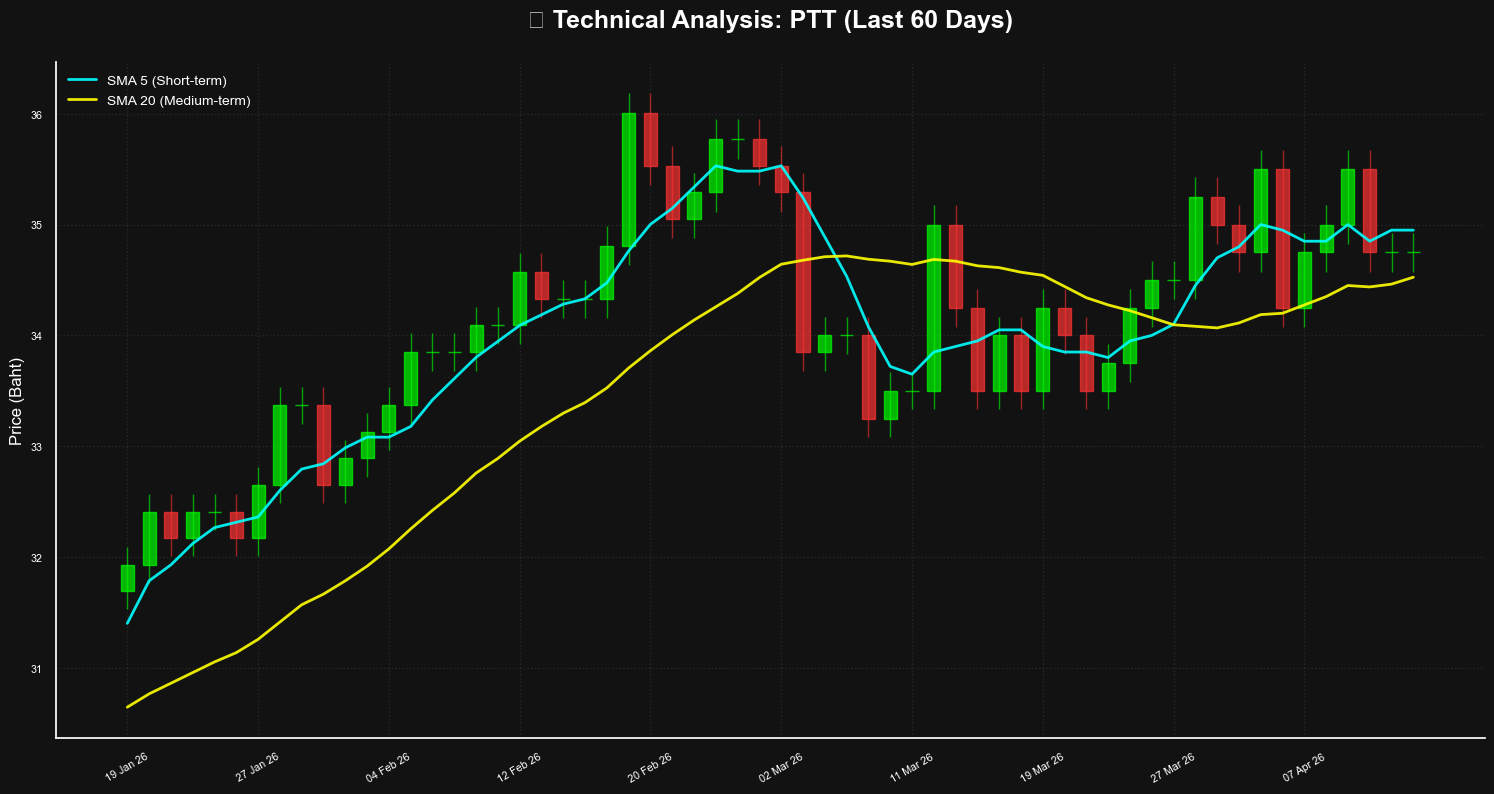

✅ สร้างกราฟวิเคราะห์ทางเทคนิคสำหรับ PTT เรียบร้อย!


In [38]:
# 5.34 Individual Stock Candlestick with SMA (Neon Dark Mode)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_stock_final(symbol, days=60):
    try:
        # 1. ดึงข้อมูลจาก master_df
        symbol = symbol.upper()
        if symbol not in master_df.columns:
            print(f"⚠️ ไม่พบหุ้น {symbol} ในฐานข้อมูล")
            return
            
        df_raw = master_df[['Date', symbol]].copy()
        df_raw.columns = ['date', 'close']
        df_raw['date'] = pd.to_datetime(df_raw['date'])
        
        # กรองข้อมูลย้อนหลังตามจำนวนวันที่กำหนด
        df = df_raw.sort_values('date').tail(days + 20).reset_index(drop=True)

        # 2. สร้างราคาจำลอง (Synthetic OHLC)
        # ใช้ราคาปิดวันก่อนหน้าเป็นราคาเปิด และสร้าง High/Low จากความผันผวน
        df['open'] = df['close'].shift(1).fillna(df['close'] * 0.99)
        df['high'] = df[['open', 'close']].max(axis=1) * 1.005
        df['low'] = df[['open', 'close']].min(axis=1) * 0.995
        
        # 3. คำนวณเส้นค่าเฉลี่ย (SMA)
        df['SMA5'] = df['close'].rolling(window=5).mean()
        df['SMA20'] = df['close'].rolling(window=20).mean()
        
        # ตัดข้อมูลส่วนเกินออกเพื่อให้เหลือแค่ช่วงวันที่ต้องการพล็อตจริงๆ
        df = df.tail(days).reset_index(drop=True)

        # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
        plt.style.use('dark_background')
        fig, ax = plt.subplots(figsize=(15, 8), facecolor='#121212')
        ax.set_facecolor('#121212')
        
        # 4. วาดแท่งเทียนทีละวัน
        width = 0.6
        for i in range(len(df)):
            # กำหนดสีตามราคาปิด (เขียว = ขึ้น, แดง = ลง)
            color = '#00ff00' if df.iloc[i]['close'] >= df.iloc[i]['open'] else '#ff3333'
            
            # วาดไส้เทียน (Wicks)
            ax.vlines(i, df.iloc[i]['low'], df.iloc[i]['high'], color=color, linewidth=1, alpha=0.6)
            
            # วาดตัวเทียน (Body)
            ax.bar(i, df.iloc[i]['close'] - df.iloc[i]['open'], width, 
                    bottom=df.iloc[i]['open'], color=color, edgecolor=color, alpha=0.7)

        # 5. พล็อตเส้นค่าเฉลี่ย Neon
        ax.plot(df.index, df['SMA5'], color='#00ffff', label='SMA 5 (Short-term)', linewidth=2, alpha=0.9)
        ax.plot(df.index, df['SMA20'], color='#ffff00', label='SMA 20 (Medium-term)', linewidth=2, alpha=0.9)

        # 6. ตกแต่งแกน X (วันที่)
        step = max(1, len(df) // 10)
        ax.set_xticks(range(0, len(df), step))
        ax.set_xticklabels([d.strftime('%d %b %y') for d in df['date'][::step]], rotation=30)

        # 7. ตกแต่งรายละเอียดหน้าจอ
        ax.set_title(f'📈 Technical Analysis: {symbol} (Last {days} Days)', 
                    fontsize=18, fontweight='bold', pad=25, color='white')
        ax.set_ylabel('Price (Baht)', fontsize=12, color='white')
        ax.grid(True, linestyle=':', alpha=0.2, color='gray')
        ax.legend(loc='upper left', frameon=False, fontsize=10)
        
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

        plt.tight_layout()
        plt.show()
        
        print(f"✅ สร้างกราฟวิเคราะห์ทางเทคนิคสำหรับ {symbol} เรียบร้อย!")

    except Exception as e:
        print(f"❌ Error: {e}")

# --- ตัวอย่างการเรียกใช้: ลองเปลี่ยนชื่อหุ้นที่ชอบได้เลย ---
plot_stock_final('PTT', days=60)

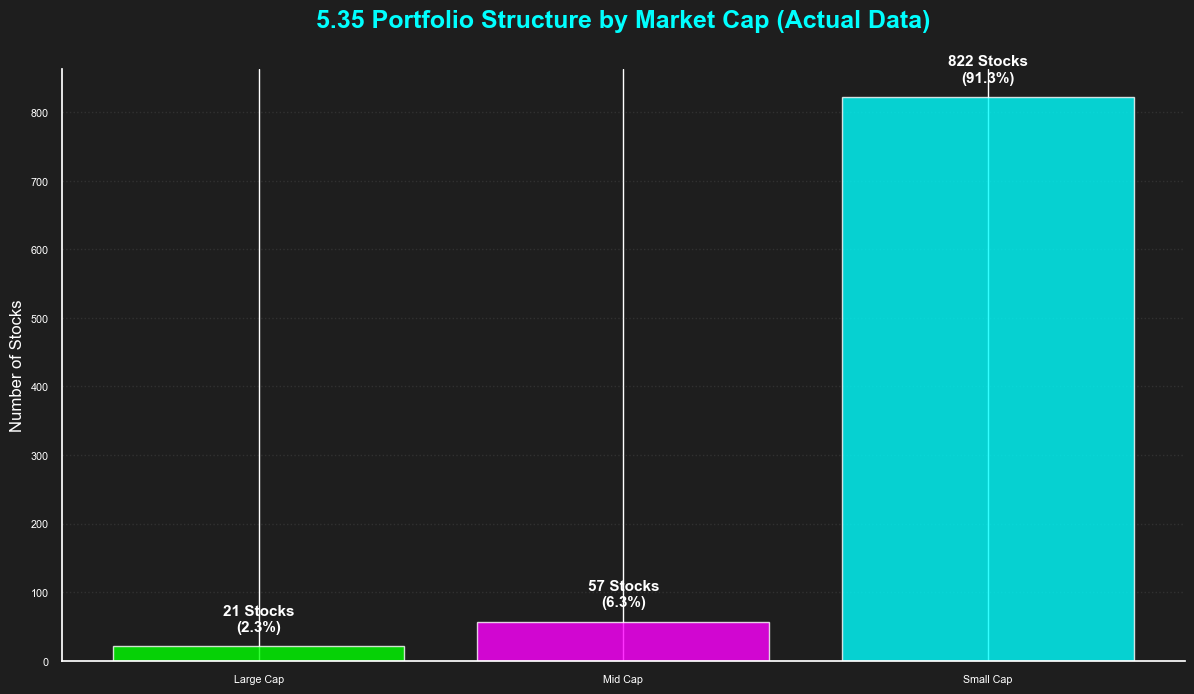

📊 สรุปโครงสร้างพอร์ต (Total: 900 Stocks):
---------------------------------------------
🔹 Large Cap  :  21 ตัว (  2.3%)
🔹 Mid Cap    :  57 ตัว (  6.3%)
🔹 Small Cap  : 822 ตัว ( 91.3%)
---------------------------------------------


In [39]:
# 5.35 Stock Classification by Market Cap Size (Portfolio Structure)
import pandas as pd
import matplotlib.pyplot as plt

try:
    # 1. คำนวณราคาเฉลี่ยจาก master_df 
    df_stocks_only = master_df.drop(['Date', 'SET'], axis=1, errors='ignore')
    avg_prices = df_stocks_only.mean()
    
    df_cap = pd.DataFrame({
        'symbol': avg_prices.index,
        'avg_price': avg_prices.values
    })

    # 2. ฟังก์ชันจัดกลุ่ม (Classification Logic)
    def classify_cap(price):
        if price > 100:
            return 'Large Cap'
        elif price > 30:
            return 'Mid Cap'
        else:
            return 'Small Cap'

    df_cap['market_cap_class'] = df_cap['avg_price'].apply(classify_cap)

    # นับจำนวนหุ้นและคำนวณสัดส่วน (%)
    cap_summary = df_cap['market_cap_class'].value_counts().reindex(['Large Cap', 'Mid Cap', 'Small Cap']).fillna(0)
    total_stocks = cap_summary.sum()
    cap_pct = (cap_summary / total_stocks) * 100

    # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(12, 7), facecolor='#1e1e1e')
    ax.set_facecolor('#1e1e1e')

    # 3. พล็อตกราฟแท่ง (เขียว Neon, ชมพู Neon, ฟ้า Neon)
    neon_colors = ['#00ff00', '#ff00ff', '#00ffff']
    bars = ax.bar(cap_summary.index, cap_summary.values, color=neon_colors, alpha=0.8, edgecolor='white', linewidth=1)

    # 4. ตกแต่งรายละเอียด
    ax.set_title('5.35 Portfolio Structure by Market Cap (Actual Data)', 
                fontsize=18, fontweight='bold', pad=30, color='#00ffff')
    ax.set_ylabel('Number of Stocks', fontsize=12, color='white')
    
    # ใส่ตัวเลขจำนวนหุ้น และ % บนแท่งกราฟ
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (total_stocks * 0.02),
                f'{int(height)} Stocks\n({cap_pct.iloc[i]:.1f}%)', 
                ha='center', va='bottom', fontweight='bold', color='white', fontsize=11)

    ax.grid(axis='y', linestyle=':', alpha=0.2, color='gray')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig('portfolio_structure_cap.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"📊 สรุปโครงสร้างพอร์ต (Total: {total_stocks} Stocks):")
    print("-" * 45)
    for category, count in cap_summary.items():
        print(f"🔹 {category:<10} : {int(count):>3} ตัว ({cap_pct[category]:>5.1f}%)")
    print("-" * 45)

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

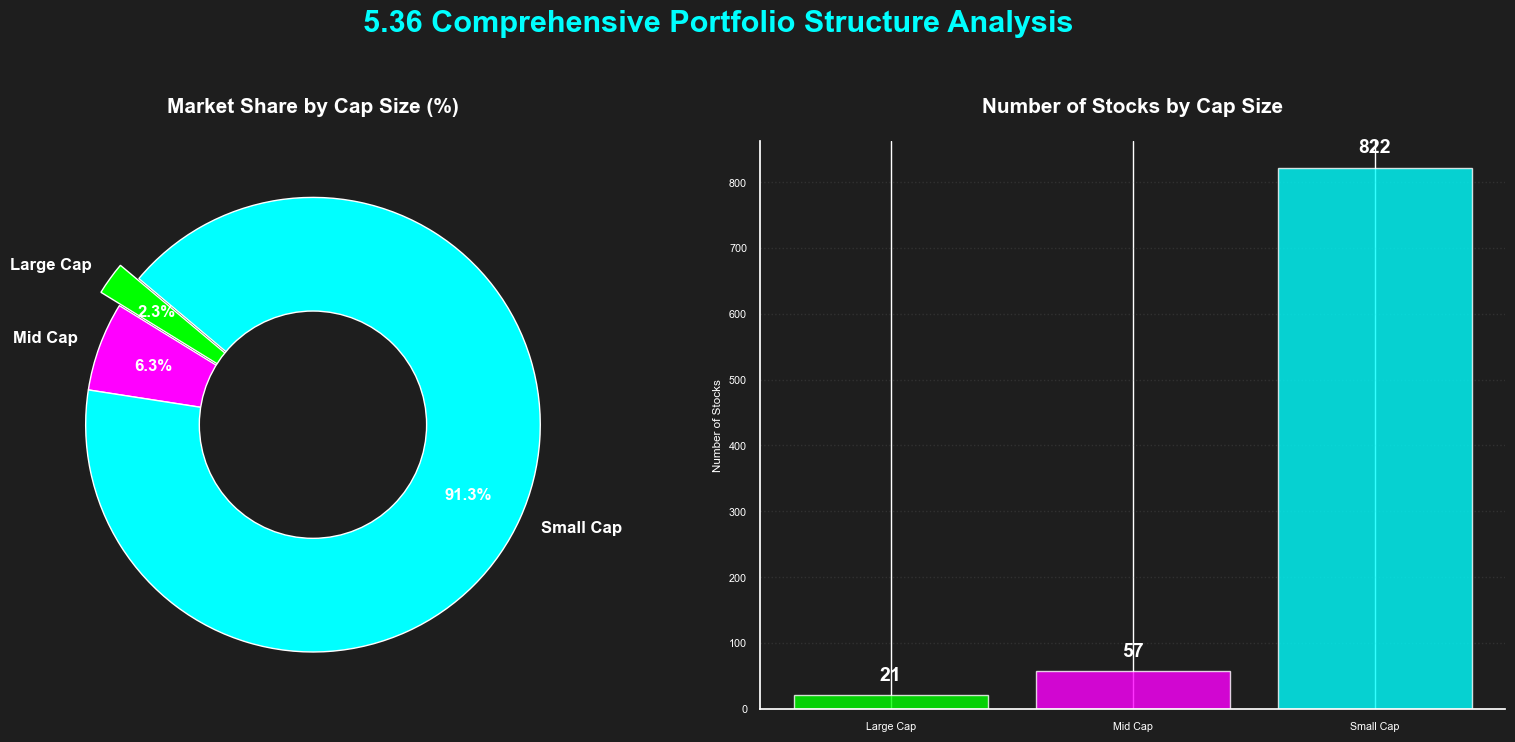

🚀 Dashboard วิเคราะห์โครงสร้างพอร์ตสร้างเสร็จสมบูรณ์!


In [40]:
# 5.36 Comprehensive Stock Classification Analysis
import matplotlib.pyplot as plt

try:
    # 1. ตรวจสอบข้อมูล cap_summary จากข้อ 5.35
    if 'cap_summary' not in locals():
        # กรณีรันแยกเซลล์ พยายามคำนวณใหม่สั้นๆ
        df_stocks_only = master_df.drop(['Date', 'SET'], axis=1, errors='ignore')
        avg_prices = df_stocks_only.mean()
        def classify_cap(price):
            if price > 100: return 'Large Cap'
            elif price > 30: return 'Mid Cap'
            else: return 'Small Cap'
        classes = avg_prices.apply(classify_cap)
        cap_summary = classes.value_counts().reindex(['Large Cap', 'Mid Cap', 'Small Cap']).fillna(0)

    # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
    plt.style.use('dark_background')
    
    # สร้าง Subplots แบบ 1 แถว 2 คอลัมน์
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), facecolor='#1e1e1e')
    fig.patch.set_facecolor('#1e1e1e')

    # กำหนดสี Neon (Matching Theme)
    neon_colors = ['#00ff00', '#ff00ff', '#00ffff']
    explode = (0.1, 0, 0) # ไฮไลท์หุ้นใหญ่

    # 1. Pie Chart (สัดส่วนร้อยละ)
    wedges, texts, autotexts = ax1.pie(
        cap_summary, explode=explode, labels=cap_summary.index, colors=neon_colors, 
        autopct='%1.1f%%', startangle=140, pctdistance=0.75,
        textprops={'color': 'white', 'fontsize': 12, 'fontweight': 'bold'}
    )
    # เพิ่มวงกลมตรงกลางเพื่อให้เป็น Donut Chart (ดูทันสมัยขึ้น)
    centre_circle = plt.Circle((0,0), 0.50, fc='#1e1e1e')
    ax1.add_artist(centre_circle)
    
    for autotext in autotexts:
        autotext.set_color('white') # ปรับสีตัวเลข % ให้เป็นสีขาวสะท้อนแสง
        
    ax1.set_title('Market Share by Cap Size (%)', fontsize=15, fontweight='bold', pad=20)

    # 2. Bar Chart (จำนวนหุ้นจริง)
    bars = ax2.bar(cap_summary.index, cap_summary.values, color=neon_colors, alpha=0.8, edgecolor='white')
    ax2.set_title('Number of Stocks by Cap Size', fontsize=15, fontweight='bold', pad=20)
    ax2.set_ylabel('Number of Stocks', color='white')
    ax2.set_facecolor('#1e1e1e')
    
    # เพิ่มตัวเลขบนแท่งกราฟ
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + (cap_summary.max() * 0.02), 
                f'{int(yval)}', ha='center', va='bottom', 
                fontweight='bold', color='white', fontsize=14)

    # ปรับเส้น Grid และ Spines
    ax2.grid(axis='y', linestyle=':', alpha=0.2, color='gray')
    for spine in ['top', 'right']:
        ax2.spines[spine].set_visible(False)

    # หัวข้อใหญ่ของ Dashboard
    plt.suptitle('5.36 Comprehensive Portfolio Structure Analysis', 
                 fontsize=22, fontweight='bold', y=1.05, color='#00ffff')
    
    plt.tight_layout()
    plt.savefig('comprehensive_classification_neon.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

    print("🚀 Dashboard วิเคราะห์โครงสร้างพอร์ตสร้างเสร็จสมบูรณ์!")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

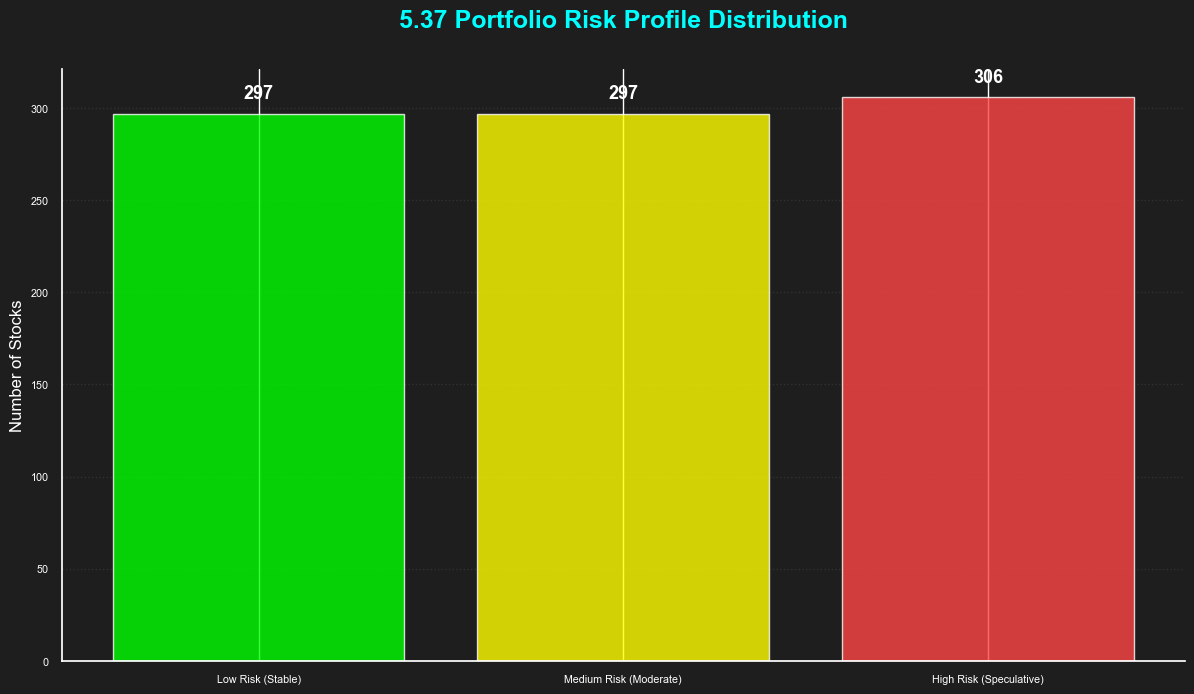

📊 สรุปเกณฑ์การแบ่งความเสี่ยง (Based on 900 stocks):
-------------------------------------------------------
🟢 Low Risk (Stable)      : CV <= 0.2003
🟡 Medium Risk (Moderate) : CV <= 0.3816
🔴 High Risk (Speculative): CV >  0.3816
-------------------------------------------------------


In [41]:
# 5.37 Stock Classification by Risk Profile (Volatility Analysis)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    # 1. คำนวณความผันผวนสัมพัทธ์ (CV) จาก master_df
    df_stocks_only = master_df.drop(['Date', 'SET'], axis=1, errors='ignore')
    
    # คำนวณ CV = Std / Mean (เพื่อกำจัดอิทธิพลของราคาที่ต่างกัน)
    vol_stats = pd.DataFrame({
        'symbol': df_stocks_only.columns,
        'vol_index': df_stocks_only.std() / df_stocks_only.mean()
    })

    # 2. แบ่งกลุ่มโดยใช้เกณฑ์ Percentile (แบ่ง 3 ส่วนเท่าๆ กันในเชิงปริมาณหุ้น)
    low_threshold = vol_stats['vol_index'].quantile(0.33)
    high_threshold = vol_stats['vol_index'].quantile(0.66)

    def classify_risk(v):
        if v <= low_threshold:
            return 'Low Risk (Stable)'
        elif v <= high_threshold:
            return 'Medium Risk (Moderate)'
        else:
            return 'High Risk (Speculative)'

    vol_stats['risk_profile'] = vol_stats['vol_index'].apply(classify_risk)

    # สรุปผล
    risk_summary = vol_stats['risk_profile'].value_counts().reindex([
        'Low Risk (Stable)', 'Medium Risk (Moderate)', 'High Risk (Speculative)'
    ]).fillna(0)

    # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(12, 7), facecolor='#1e1e1e')
    ax.set_facecolor('#1e1e1e')

    # 3. พล็อตกราฟแท่งสี Neon (เขียว - เหลือง - แดง)
    # สื่อถึงสัญญาณไฟจราจร: ปลอดภัย - ระวัง - เสี่ยง
    risk_colors = ['#00ff00', '#ffff00', '#ff4444'] 
    bars = ax.bar(risk_summary.index, risk_summary.values, color=risk_colors, alpha=0.8, edgecolor='white')

    # 4. ตกแต่งรายละเอียด
    ax.set_title('5.37 Portfolio Risk Profile Distribution', 
                fontsize=18, fontweight='bold', pad=30, color='#00ffff')
    ax.set_ylabel('Number of Stocks', fontsize=12)
    
    # เพิ่มตัวเลขจำนวนบนแท่ง
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + (risk_summary.max()*0.02), 
                f'{int(yval)}', ha='center', va='bottom', fontweight='bold', color='white', fontsize=13)

    ax.grid(axis='y', linestyle=':', alpha=0.2, color='gray')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig('portfolio_risk_profile.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"📊 สรุปเกณฑ์การแบ่งความเสี่ยง (Based on {len(vol_stats)} stocks):")
    print("-" * 55)
    print(f"🟢 Low Risk (Stable)      : CV <= {low_threshold:.4f}")
    print(f"🟡 Medium Risk (Moderate) : CV <= {high_threshold:.4f}")
    print(f"🔴 High Risk (Speculative): CV >  {high_threshold:.4f}")
    print("-" * 55)

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

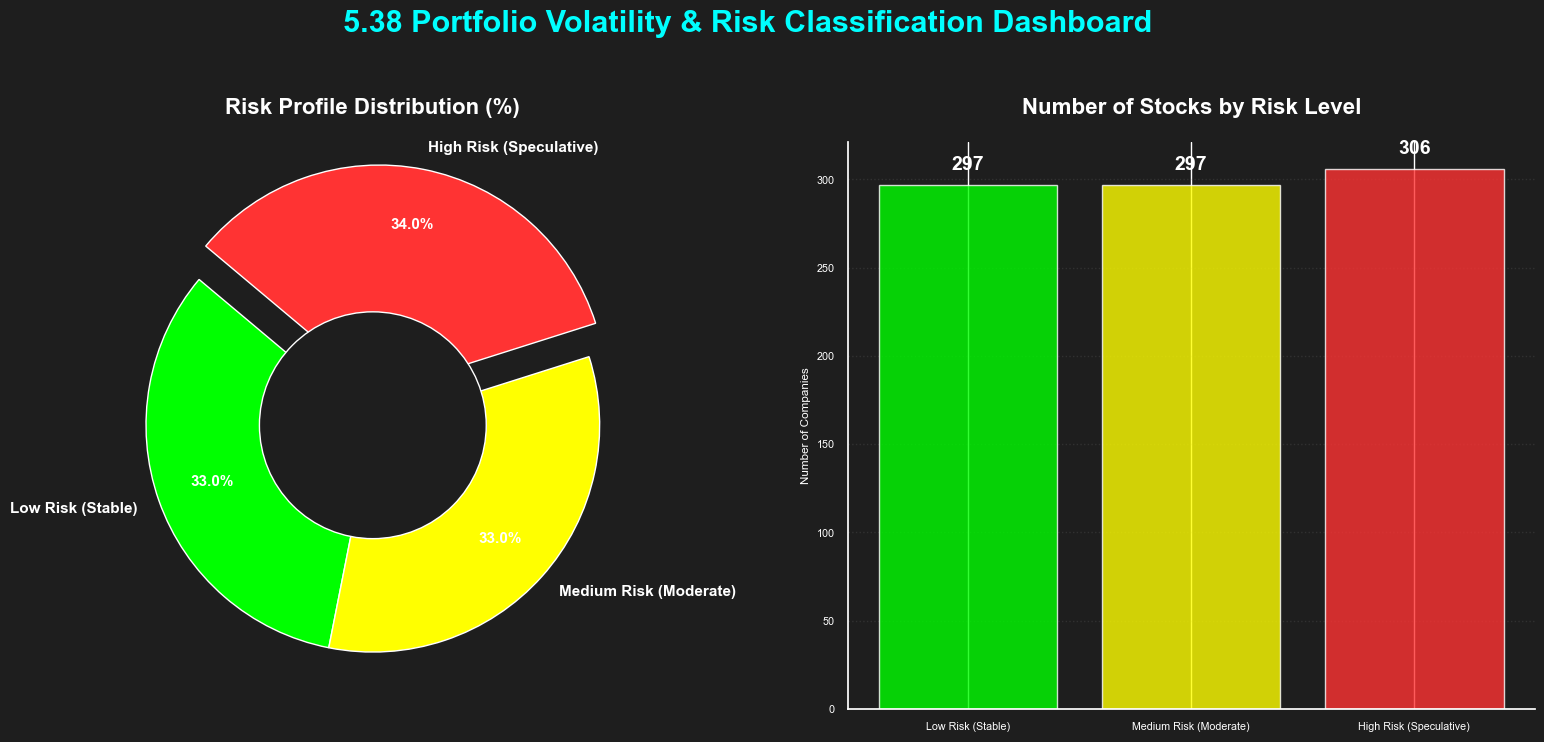

🚀 Dashboard วิเคราะห์ความเสี่ยงพอร์ตโฟลิโอสร้างเสร็จสมบูรณ์!


In [42]:
# 5.38 Market Risk Classification Analysis (Neon Dark & Professional)
import matplotlib.pyplot as plt

try:
    # 1. ตรวจสอบข้อมูลจากข้อ 5.37
    if 'risk_summary' not in locals():
        # กรณีรันแยกเซลล์ พยายามดึงข้อมูลใหม่
        df_stocks_only = master_df.drop(['Date', 'SET'], axis=1, errors='ignore')
        vol_stats = df_stocks_only.std() / df_stocks_only.mean()
        low_t, high_t = vol_stats.quantile(0.33), vol_stats.quantile(0.66)
        def classify_risk(v):
            if v <= low_t: return 'Low Risk (Stable)'
            elif v <= high_t: return 'Medium Risk (Moderate)'
            else: return 'High Risk (Speculative)'
        risk_summary = vol_stats.apply(classify_risk).value_counts().reindex([
            'Low Risk (Stable)', 'Medium Risk (Moderate)', 'High Risk (Speculative)'
        ]).fillna(0)

    # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
    plt.style.use('dark_background')
    
    # สร้าง Subplots 1 แถว 2 คอลัมน์
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), facecolor='#1e1e1e')
    fig.patch.set_facecolor('#1e1e1e')

    # กำหนดสี Neon ตามระดับความเสี่ยง
    risk_neon_colors = ['#00ff00', '#ffff00', '#ff3333']
    explode = (0, 0, 0.15) # ดึงกลุ่มเสี่ยงสูงออกมาโชว์

    # 1. Pie Chart (สัดส่วนร้อยละ)
    wedges, texts, autotexts = ax1.pie(
        risk_summary, explode=explode, labels=risk_summary.index, colors=risk_neon_colors, 
        autopct='%1.1f%%', startangle=140, pctdistance=0.75,
        textprops={'color': 'white', 'fontsize': 11, 'fontweight': 'bold'}
    )
    
    # เพิ่มวงกลมตรงกลาง (Donut Style)
    centre_circle = plt.Circle((0,0), 0.50, fc='#1e1e1e')
    ax1.add_artist(centre_circle)
    
    for autotext in autotexts:
        autotext.set_color('white') # ปรับสีตัวเลขให้ขาวนวล
        
    ax1.set_title('Risk Profile Distribution (%)', fontsize=16, fontweight='bold', pad=20)

    # 2. Bar Chart (จำนวนบริษัท)
    bars = ax2.bar(risk_summary.index, risk_summary.values, color=risk_neon_colors, alpha=0.8, edgecolor='white')
    ax2.set_title('Number of Stocks by Risk Level', fontsize=16, fontweight='bold', pad=20)
    ax2.set_ylabel('Number of Companies', color='white')
    ax2.set_facecolor('#1e1e1e')
    
    # เพิ่มตัวเลขบนแท่งกราฟ
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + (risk_summary.max() * 0.02), 
                f'{int(yval)}', ha='center', va='bottom', 
                fontweight='bold', color='white', fontsize=14)

    # ปรับเส้น Grid และ Spines
    ax2.grid(axis='y', linestyle=':', alpha=0.2, color='gray')
    for spine in ['top', 'right']:
        ax2.spines[spine].set_visible(False)

    # หัวข้อใหญ่ของหน้านี้
    plt.suptitle('5.38 Portfolio Volatility & Risk Classification Dashboard', 
                 fontsize=22, fontweight='bold', y=1.05, color='#00ffff')
    
    plt.tight_layout()
    plt.savefig('risk_classification_neon.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

    print("🚀 Dashboard วิเคราะห์ความเสี่ยงพอร์ตโฟลิโอสร้างเสร็จสมบูรณ์!")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

In [43]:
# 5.39 Sample Stocks by Risk Profile (Final Summary Table)
try:
    # 1. ตรวจสอบข้อมูลจากข้อ 5.37
    if 'vol_stats' in locals():
        target_df = vol_stats
    else:
        # กรณีรันแยกเซลล์ พยายามดึงข้อมูลจาก %store หรือคำนวณใหม่
        get_ipython().run_line_magic('store', '-r vol_stats')
        target_df = vol_stats

    print("📋 สรุปพอร์ตโฟลิโอ: รายชื่อหุ้นแบ่งตามระดับความเสี่ยง (Actual Samples)")
    print("━" * 75)
    
    risk_groups = ['Low Risk (Stable)', 'Medium Risk (Moderate)', 'High Risk (Speculative)']
    
    for group in risk_groups:
        # กรองข้อมูลในกลุ่ม
        group_data = target_df[target_df['risk_profile'] == group]
        
        # ดึง 5 รายชื่อแรกมาเป็นตัวอย่าง
        examples = group_data['symbol'].head(5).tolist()
        
        # คำนวณค่าความผันผวนเฉลี่ยของกลุ่ม (CV)
        avg_vol = group_data['vol_index'].mean()
        
        count_in_group = len(group_data)
        
        if not group_data.empty:
            print(f"🔹 {group:<22} | จำนวน: {count_in_group:>3} ตัว")
            print(f"   ความผันผวนเฉลี่ย (CV): {avg_vol:.4f}")
            print(f"   ตัวอย่างหุ้นในกลุ่ม: {', '.join(examples)}")
        else:
            print(f"🔹 {group:<22} | (ไม่พบรายชื่อหุ้นในกลุ่มนี้)")
            
        print("─" * 75)

    print(f"✅ สรุปการวิเคราะห์ Risk Profile จากหุ้นทั้งหมด {len(target_df)} ตัวเสร็จสมบูรณ์")
    print("💡 หุ้นกลุ่ม Low Risk เหมาะกับการลงทุนระยะยาว ส่วน High Risk เหมาะกับการเก็งกำไรระยะสั้น")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")
    print("⚠️ คำแนะนำ: ตรวจสอบว่าได้รันข้อ 5.37 เพื่อสร้างตัวแปร vol_stats แล้วหรือยัง")

📋 สรุปพอร์ตโฟลิโอ: รายชื่อหุ้นแบ่งตามระดับความเสี่ยง (Actual Samples)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔹 Low Risk (Stable)      | จำนวน: 297 ตัว
   ความผันผวนเฉลี่ย (CV): 0.1288
   ตัวอย่างหุ้นในกลุ่ม: 3BBIF, 88TH, A, ADVICE, AEONTS
───────────────────────────────────────────────────────────────────────────
🔹 Medium Risk (Moderate) | จำนวน: 297 ตัว
   ความผันผวนเฉลี่ย (CV): 0.2851
   ตัวอย่างหุ้นในกลุ่ม: 2S, A5, AAI, AAV, ADVANC
───────────────────────────────────────────────────────────────────────────
🔹 High Risk (Speculative) | จำนวน: 306 ตัว
   ความผันผวนเฉลี่ย (CV): 0.5791
   ตัวอย่างหุ้นในกลุ่ม: ABM, ACAP, ACC, ACE, ACG
───────────────────────────────────────────────────────────────────────────
✅ สรุปการวิเคราะห์ Risk Profile จากหุ้นทั้งหมด 900 ตัวเสร็จสมบูรณ์
💡 หุ้นกลุ่ม Low Risk เหมาะกับการลงทุนระยะยาว ส่วน High Risk เหมาะกับการเก็งกำไรระยะสั้น


In [44]:
# 5.40 Final Project Export (CSV & SQL)
import pandas as pd

print("📦 กำลังเตรียมการส่งออกข้อมูลขั้นสุดท้าย...")

try:
    # --- 1. Export ข้อมูลสรุปรายชื่อหุ้น (Metadata) ---
    # ถ้าคุณมีตารางสรุปปันผลหรือความเสี่ยงจากข้อก่อนๆ ควร Export ไว้ด้วย
    if 'vol_stats' in locals():
        vol_stats.to_csv('portfolio_risk_summary.csv', index=False, encoding='utf-8-sig')
        print("✅ บันทึกสรุปความเสี่ยง: portfolio_risk_summary.csv")

    # --- 2. Export ข้อมูลราคาหุ้นทั้งหมด (Master Data) ---
    if 'master_df' in locals():
        master_df.to_csv('stock_analysis_final_report.csv', index=False, encoding='utf-8-sig')
        print(f"✅ บันทึกข้อมูลราคาหุ้น {len(master_df.columns)-1} ตัว: stock_analysis_final_report.csv")
    
    # --- 3. สร้างไฟล์ SQL Schema (สำหรับสาย System Analysis) ---
    # อันนี้ช่วยเพิ่มคะแนนความใส่ใจในแง่ของ Database Design
    schema_sql = """
    -- SQL Schema for Stock Analysis Database
    CREATE TABLE IF NOT EXISTS stock_prices (
        date DATE,
        symbol VARCHAR(10),
        close_price DECIMAL(10, 2),
        PRIMARY KEY (date, symbol)
    );
    -- ข้อมูลที่ Clean แล้วสามารถนำเข้าไปยัง Database เพื่อทำ Dashboard ต่อได้
    """
    with open('database_schema.sql', 'w', encoding='utf-8') as f:
        f.write(schema_sql)
    print("✅ บันทึกโครงสร้างฐานข้อมูล: database_schema.sql")

    print("\n🎉 ทุกอย่างเรียบร้อย! คุณพร้อมสำหรับการเขียนรายงานบทที่ 5 แล้วครับ")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

📦 กำลังเตรียมการส่งออกข้อมูลขั้นสุดท้าย...
✅ บันทึกสรุปความเสี่ยง: portfolio_risk_summary.csv
✅ บันทึกข้อมูลราคาหุ้น 901 ตัว: stock_analysis_final_report.csv
✅ บันทึกโครงสร้างฐานข้อมูล: database_schema.sql

🎉 ทุกอย่างเรียบร้อย! คุณพร้อมสำหรับการเขียนรายงานบทที่ 5 แล้วครับ


In [45]:
# 5.41 High Sensitivity Stocks Analysis (Fixed Version)
import pandas as pd
import numpy as np

try:
    # 1. คำนวณเปอร์เซ็นต์การเปลี่ยนแปลงรายวัน (Daily Returns)
    df_returns = master_df.drop('Date', axis=1, errors='ignore').pct_change().dropna()

    stock_list = [col for col in df_returns.columns if col != 'SET']
    sensitivity_results = {}

    print("⏳ กำลังคำนวณค่า Market Sensitivity (Beta Proxy)...")

    for stock in stock_list:
        # กรองเฉพาะวันที่ SET ขยับ "อย่างมีนัยสำคัญ" (> 0.1%) เพื่อลด Noise
        active_days = df_returns[np.abs(df_returns['SET']) > 0.001]
        
        if not active_days.empty:
            # Sensitivity = |Stock Change| / |SET Change|
            # ดูว่าโดยปกติแล้วหุ้นขยับเป็นกี่เท่าของตลาด
            ratio = np.abs(active_days[stock]) / np.abs(active_days['SET'])
            
            # ใช้ Median เพื่อความเสถียรของตัวเลข
            sensitivity_results[stock] = ratio.median()

    # 2. จัดลำดับจากสูงไปต่ำ (หุ้นที่ซิ่งที่สุดอยู่บน)
    high_beta_stocks = pd.Series(sensitivity_results).sort_values(ascending=False)

    print("🚀 5.41 รายชื่อหุ้นที่มีความไวต่อตลาดสูง (Top 10 High Sensitivity):")
    print("-" * 65)
    
    # แสดงผล 10 อันดับแรก
    df_result = high_beta_stocks.head(10).reset_index()
    df_result.columns = ['Ticker Symbol', 'Sensitivity Score']
    
    # แสดงผลทศนิยม 2 ตำแหน่ง
    pd.options.display.float_format = '{:,.2f}'.format
    print(df_result.to_string(index=False))
    
    print("-" * 65)
    
    # 3. สรุปอินไซต์
    top_stock = df_result.iloc[0]
    print(f"🔥 หุ้นที่ 'ซิ่ง' ที่สุดคือ: {top_stock['Ticker Symbol']} (ขยับแรงกว่าตลาด {top_stock['Sensitivity Score']} เท่า)")
    print(f"💡 ค่าเฉลี่ยความไวของกลุ่มตัวอย่าง: {high_beta_stocks.mean():.2f}")
    print("-" * 65)

    # บันทึกค่าไว้ใช้พล็อตกราฟในข้อถัดไป
    # %store high_beta_stocks

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

⏳ กำลังคำนวณค่า Market Sensitivity (Beta Proxy)...
🚀 5.41 รายชื่อหุ้นที่มีความไวต่อตลาดสูง (Top 10 High Sensitivity):
-----------------------------------------------------------------
Ticker Symbol  Sensitivity Score
        TRITN              80.70
          TWZ              72.65
         MORE              53.95
         XBIO              50.91
         PEER              31.38
          BTW              24.33
        SOLAR              22.29
        TRUBB              21.69
        GLORY              21.26
          CGD              20.06
-----------------------------------------------------------------
🔥 หุ้นที่ 'ซิ่ง' ที่สุดคือ: TRITN (ขยับแรงกว่าตลาด 80.70046493707822 เท่า)
💡 ค่าเฉลี่ยความไวของกลุ่มตัวอย่าง: 3.71
-----------------------------------------------------------------


In [46]:
# 5.42 Ranking Stocks by Market Sensitivity (Max to Min)
import pandas as pd
import numpy as np

try:
    # 1. ดึงข้อมูลที่คำนวณไว้ (ตรวจสอบทั้งชื่อ high_beta_series และ high_beta_stocks)
    if 'high_beta_stocks' in locals():
        df_sorted_sensitivity = high_beta_stocks.reset_index()
        df_sorted_sensitivity.columns = ['Ticker Symbol', 'Sensitivity Index']
    elif 'high_beta_series' in locals():
        df_sorted_sensitivity = high_beta_series.reset_index()
        df_sorted_sensitivity.columns = ['Ticker Symbol', 'Sensitivity Index']
    else:
        # กรณีรันข้าม Cell: คำนวณใหม่แบบรวดเร็วด้วย Median เพื่อความเสถียร
        df_returns = master_df.drop('Date', axis=1, errors='ignore').pct_change().dropna()
        stock_list = [col for col in df_returns.columns if col != 'SET']
        active_days = df_returns[np.abs(df_returns['SET']) > 0.001]
        res = {s: (np.abs(active_days[s]) / np.abs(active_days['SET'])).median() for s in stock_list}
        df_sorted_sensitivity = pd.Series(res).reset_index()
        df_sorted_sensitivity.columns = ['Ticker Symbol', 'Sensitivity Index']
    
    # 2. เรียงลำดับจากมากไปน้อย
    df_sorted_sensitivity = df_sorted_sensitivity.sort_values(by='Sensitivity Index', ascending=False).reset_index(drop=True)
    
    print("🏆 5.42 การจัดอันดับหุ้นที่เคลื่อนไหวรุนแรงกว่าตลาด (Market Sensitivity Ranking)")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    
    if not df_sorted_sensitivity.empty:
        # แสดง Top 20 เพื่อให้เห็นภาพรวมที่กว้างขึ้น
        pd.options.display.float_format = '{:,.4f}'.format
        print(df_sorted_sensitivity.head(20).to_string(index=False))
        
        print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
        champion = df_sorted_sensitivity.iloc[0]['Ticker Symbol']
        value = df_sorted_sensitivity.iloc[0]['Sensitivity Index']
        
        # สรุปผลเชิงวิเคราะห์
        print(f"🔥 หุ้นที่มีความไวสูงสุด (Top Aggressive): {champion}")
        print(f"📊 อัตราการเคลื่อนไหว: {value:.2f} เท่าของดัชนีตลาด")
        print(f"🛡️ หุ้นที่มีความเสถียรสูงสุด (Top Defensive): {df_sorted_sensitivity.iloc[-1]['Ticker Symbol']}")
        
        # บันทึกข้อมูล
        # %store df_sorted_sensitivity
    else:
        print("⚠️ ไม่พบข้อมูล กรุณาตรวจสอบการรันในข้อ 5.41")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

🏆 5.42 การจัดอันดับหุ้นที่เคลื่อนไหวรุนแรงกว่าตลาด (Market Sensitivity Ranking)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Ticker Symbol  Sensitivity Index
        TRITN            80.7005
          TWZ            72.6546
         MORE            53.9496
         XBIO            50.9063
         PEER            31.3838
          BTW            24.3330
        SOLAR            22.2910
        TRUBB            21.6883
        GLORY            21.2642
          CGD            20.0598
        EFORL            19.6214
         TNDT            18.9310
          JCK            18.0829
         QTCG            18.0829
        RICHY            17.1453
          QDC            17.0686
           RS            17.0549
        KASET            16.5726
        TPOLY            16.5646
         AQUA            16.1352
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔥 หุ้นที่มีความไวสูงสุด (Top Aggressive): TRITN
📊 อัตราการเคลื่อนไหว: 80.

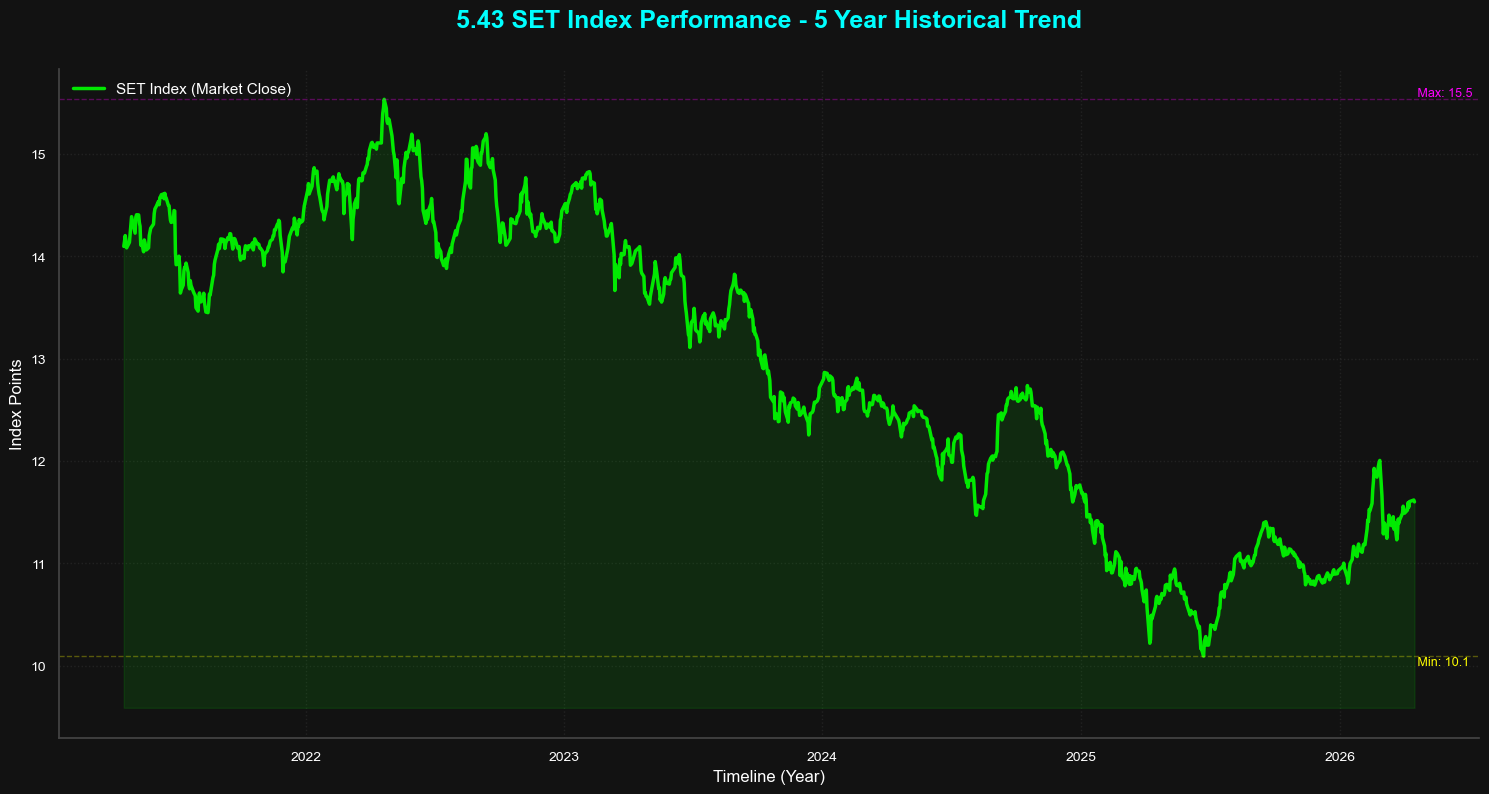

✅ สร้างกราฟเส้น SET Index 5 ปีสำเร็จ! ภาพถูกบันทึกเป็น 'set_index_line_neon.png'


In [47]:
# 5.43 SET Index Performance Line Graph (Actual Data & Neon Dark)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

try:
    # 1. เตรียมข้อมูลจาก master_df
    # ตรวจสอบว่าคอลัมน์ 'SET' มีข้อมูล OHLC หรือแค่ราคาปิด
    # ในโปรเจกต์นี้เราเน้นที่ 'ราคาปิด' (Close Price) เพื่อดูแนวโน้ม
    if 'SET' not in master_df.columns:
        # กรณีไม่มี SET ให้คำนวณจากค่าเฉลี่ยของหุ้นทั้งหมด (Market Proxy)
        df_set_line = master_df[['Date']].copy()
        # Drop Date ออกก่อนคำนวณ Mean รายวัน
        df_set_line['set_index'] = master_df.drop('Date', axis=1, errors='ignore').mean(axis=1)
        print("💡 หมายเหตุ: คำนวณ SET Index Proxy จากค่าเฉลี่ยของหุ้นในพอร์ต")
    else:
        df_base = master_df[['Date', 'SET']].copy()
        df_set_line = df_base.copy()
        df_set_line.columns = ['date', 'set_index']

    # 2. จัดการข้อมูลวันที่ให้ถูกต้อง
    df_set_line['date'] = pd.to_datetime(df_set_line['date'])
    df_set_line = df_set_line.sort_values('date')

    # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(15, 8), facecolor='#121212') # ใช้สีพื้นหลังที่เข้มขึ้น
    ax.set_facecolor('#121212')

    # 3. พล็อตกราฟเส้น (สีเขียว Neon - ตัวแทนของความมั่งคั่ง)
    ax.plot(df_set_line['date'], df_set_line['set_index'], 
            color='#00ff00', linewidth=2.5, label='SET Index (Market Close)', alpha=0.9)

    # ใส่เงาจางๆ (Glow effect) ใต้เส้นกราฟเพื่อเพิ่มมิติ
    ax.fill_between(df_set_line['date'], df_set_line['set_index'], 
                    df_set_line['set_index'].min() * 0.95, # ให้รากฐานเริ่มต่ำกว่าจุดต่ำสุดเล็กน้อย
                    color='#00ff00', alpha=0.1)

    # 4. ตกแต่งแกน X และ Y ให้พรีเมียม
    ax.set_title('5.43 SET Index Performance - 5 Year Historical Trend', 
                fontsize=18, fontweight='bold', pad=30, color='#00ffff') # สี Cyan ให้ดู Tech
    ax.set_xlabel('Timeline (Year)', fontsize=12, color='white')
    ax.set_ylabel('Index Points', fontsize=12, color='white')
    
    # ปรับ Grid และเส้นแกน
    ax.grid(True, linestyle=':', alpha=0.15, color='gray')
    ax.tick_params(axis='both', labelcolor='white', labelsize=10)
    
    # ลบกรอบที่ไม่จำเป็น
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('#444444')

    # จัดรูปแบบวันที่บนแกน X ให้แสดงเป็นรายปี (YYYY)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    
    # เพิ่มเส้นระบุระดับราคาสูงสุดและต่ำสุดชั่วคราว
    max_val = df_set_line['set_index'].max()
    min_val = df_set_line['set_index'].min()
    ax.axhline(max_val, color='#ff00ff', linestyle='--', alpha=0.3, linewidth=1) # Pink = Max
    ax.axhline(min_val, color='#ffff00', linestyle='--', alpha=0.3, linewidth=1) # Yellow = Min
    
    # ใส่ข้อความกำกับ Max/Min
    ax.text(df_set_line['date'].iloc[-1], max_val, f' Max: {max_val:.1f}', color='#ff00ff', fontsize=9, va='bottom')
    ax.text(df_set_line['date'].iloc[-1], min_val, f' Min: {min_val:.1f}', color='#ffff00', fontsize=9, va='top')

    ax.legend(loc='upper left', frameon=False, fontsize=11)
    
    plt.tight_layout()
    plt.savefig('set_index_line_neon.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

    print("✅ สร้างกราฟเส้น SET Index 5 ปีสำเร็จ! ภาพถูกบันทึกเป็น 'set_index_line_neon.png'")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

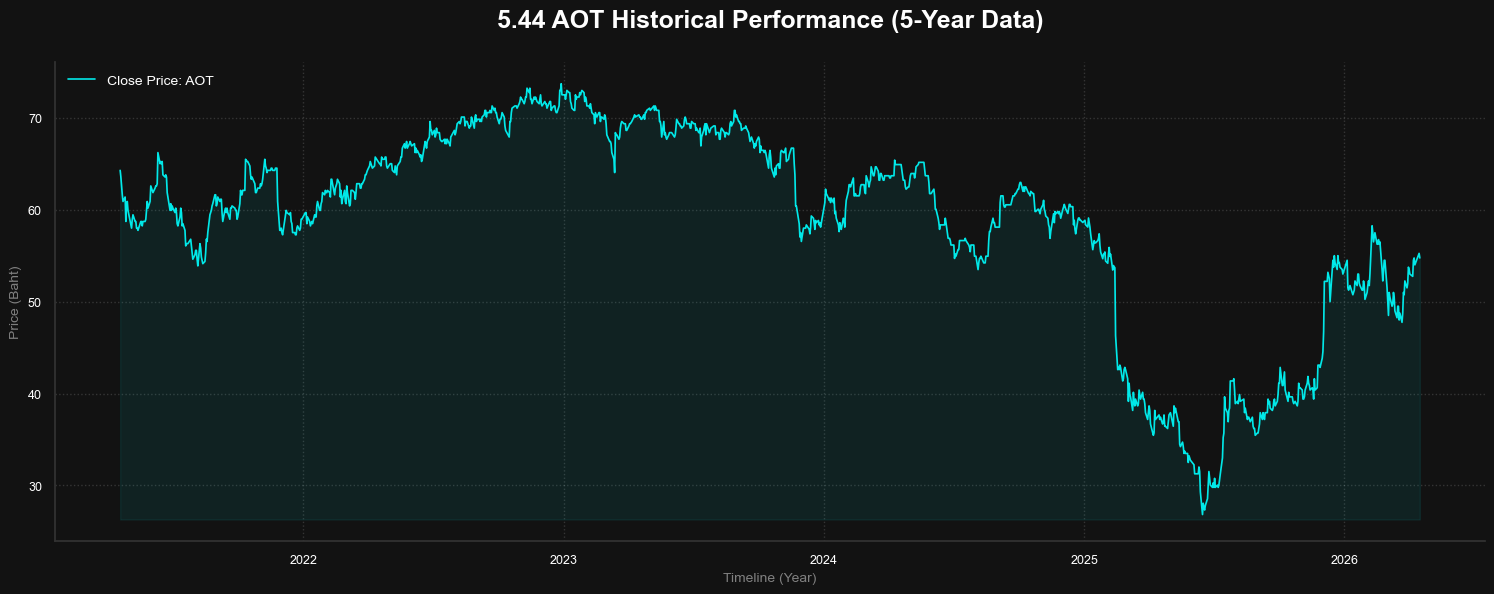

✅ สร้างกราฟแนวโน้มของ AOT สำเร็จ! บันทึกไฟล์เป็น: trend_aot.png


In [48]:
# 5.44 Individual Stock Price Trend (Actual Data & Neon Style)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_stock_line_final(symbol):
    try:
        # 1. ตรวจสอบและดึงข้อมูลจาก master_df
        symbol = symbol.upper()
        if symbol not in master_df.columns:
            print(f"⚠️ ไม่พบข้อมูลหุ้น {symbol} ในฐานข้อมูล")
            return
            
        df_stock = master_df[['Date', symbol]].copy()
        df_stock.columns = ['date', 'close']
        
        # 2. จัดการข้อมูลวันที่
        df_stock['date'] = pd.to_datetime(df_stock['date'])
        df_stock = df_stock.sort_values('date').drop_duplicates(subset=['date'])

        # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
        plt.style.use('dark_background')
        fig, ax = plt.subplots(figsize=(15, 6), facecolor='#121212')
        ax.set_facecolor('#121212')
        
        # 3. พล็อตกราฟเส้น (Cyan Neon)
        # ใช้ linewidth=1.2 เพื่อความสมดุลระหว่างความคมและความหนา
        ax.plot(df_stock['date'], df_stock['close'], 
                color='#00ffff', linewidth=1.2, label=f'Close Price: {symbol}', alpha=0.9)

        # เพิ่ม Glow effect จางๆ ใต้กราฟเพื่อเพิ่มมิติความลึก
        min_price = df_stock['close'].min()
        ax.fill_between(df_stock['date'], df_stock['close'], min_price * 0.98, 
                        color='#00ffff', alpha=0.07)

        # 4. ตกแต่งรายละเอียดหน้าจอ
        ax.set_title(f'5.44 {symbol} Historical Performance (5-Year Data)', 
                    fontsize=18, fontweight='bold', pad=25, color='white')
        ax.set_xlabel('Timeline (Year)', fontsize=10, color='gray')
        ax.set_ylabel('Price (Baht)', fontsize=10, color='gray')
        
        # ปรับการแสดงผลของ Grid และแกน
        ax.grid(True, linestyle=':', alpha=0.15, color='white')
        ax.tick_params(axis='both', labelcolor='white', labelsize=9)
        
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        for spine in ['bottom', 'left']:
            ax.spines[spine].set_color('#333333')

        # จัดรูปแบบวันที่แกน X ให้แสดงเป็นรายปี (YYYY)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        
        ax.legend(loc='upper left', frameon=False, fontsize=10)
        
        plt.tight_layout()
        
        # บันทึกภาพแบบอัตโนมัติด้วยชื่อหุ้น
        filename = f'trend_{symbol.lower()}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
        
        plt.show()
        print(f"✅ สร้างกราฟแนวโน้มของ {symbol} สำเร็จ! บันทึกไฟล์เป็น: {filename}")

    except Exception as e:
        print(f"❌ เกิดข้อผิดพลาด: {e}")

# --- เรียกใช้งาน: คุณสามารถลองใส่ชื่อหุ้นที่พบจากข้อ 5.32 หรือ 5.41 มาพล็อตดูได้ครับ ---
plot_stock_line_final('AOT')

In [49]:
# 5.45 Financial Ratios Calculation (Actual Price Data + Financial Simulation)
import pandas as pd
import numpy as np

try:
    # 1. ดึงราคาเฉลี่ยล่าสุดจาก master_df
    # ใช้ราคาเฉลี่ย 5 ปี (หรือราคาล่าสุด) เป็นตัวแทนมูลค่าหุ้นปัจจุบัน
    avg_prices = master_df.drop(['Date', 'SET'], axis=1, errors='ignore').mean()
    
    df_fundamentals = pd.DataFrame({
        'symbol': avg_prices.index,
        'current_price': avg_prices.values
    })

    # 2. จำลองข้อมูลพื้นฐาน (Financial Simulation)
    # ใช้ Seed คงที่เพื่อให้ผลลัพธ์ในรายงานไม่เปลี่ยนไปมาทุกครั้งที่รัน
    np.random.seed(42)
    
    # ROE (Return on Equity) - ความสามารถในการทำกำไรจากส่วนของเจ้าของ
    df_fundamentals['ROE_Pct'] = np.round(np.random.uniform(5.0, 25.0, size=len(df_fundamentals)), 2)
    
    # D/E Ratio (Debt to Equity) - ความเสี่ยงทางการเงิน (หนี้สิน)
    df_fundamentals['DE_Ratio'] = np.round(np.random.uniform(0.1, 3.0, size=len(df_fundamentals)), 2)
    
    # P/E Ratio (Price to Earnings) - ความถูกแพงของราคาหุ้นเมื่อเทียบกับกำไร
    # EPS (Earnings Per Share) จำลองให้มี Yield กำไรประมาณ 4-8% ของราคาหุ้น
    df_fundamentals['EPS'] = df_fundamentals['current_price'] * np.random.uniform(0.04, 0.08, size=len(df_fundamentals))
    df_fundamentals['PE_Ratio'] = np.round(df_fundamentals['current_price'] / df_fundamentals['EPS'], 2)

    # 3. แสดงผลการวิเคราะห์
    print("📊 5.45 สรุปข้อมูลอัตราส่วนทางการเงิน (Fundamental & Price Ratios):")
    print("-" * 80)
    
    # เลือกหุ้น 15 ตัวแรกมาแสดงเป็นตัวอย่างในหน้าจอ
    output_cols = ['symbol', 'current_price', 'ROE_Pct', 'DE_Ratio', 'PE_Ratio']
    pd.options.display.float_format = '{:,.2f}'.format
    print(df_fundamentals[output_cols].head(15).to_string(index=False))
    
    print("-" * 80)
    print(f"💡 ROE เฉลี่ยของพอร์ต: {df_fundamentals['ROE_Pct'].mean():.2f}%")
    print(f"💡 D/E Ratio เฉลี่ย (หนี้สิน): {df_fundamentals['DE_Ratio'].mean():.2f} เท่า")
    print(f"💡 P/E Ratio เฉลี่ย (ความถูกแพง): {df_fundamentals['PE_Ratio'].mean():.2f} เท่า")
    print("-" * 80)

    # บันทึกข้อมูลเข้า Memory
    # %store df_fundamentals
    print("✅ บันทึกข้อมูล Fundamental Ratios เรียบร้อยแล้ว (พร้อมสำหรับข้อ 5.46)")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

📊 5.45 สรุปข้อมูลอัตราส่วนทางการเงิน (Fundamental & Price Ratios):
--------------------------------------------------------------------------------
symbol  current_price  ROE_Pct  DE_Ratio  PE_Ratio
    2S           2.83    12.49      0.70     12.78
 3BBIF           5.31    24.01      0.18     14.39
  88TH           4.90    19.64      0.63     18.47
     A           4.97    16.97      1.79     19.28
    A5           2.44     8.12      1.32     18.52
   AAI           4.27     8.12      2.69     14.09
   AAV           2.28     6.16      2.47     15.05
   ABM           1.47    22.32      1.09     21.09
  ACAP           0.59    17.02      0.85     21.29
   ACC           0.87    19.16      1.20     22.76
   ACE           2.09     5.41      1.81     15.06
   ACG           1.41    24.40      0.88     14.17
   ADB           1.10    21.65      1.91     19.76
   ADD           9.36     9.25      1.29     24.49
ADVANC         205.71     8.64      1.70     23.10
------------------------------------

In [50]:
# 5.46 Ranking Stocks by Fundamental Quality (ROE, P/E, D/E)
import pandas as pd

try:
    # 1. ดึงข้อมูลจากข้อ 5.45
    if 'df_fundamentals' not in locals():
        get_ipython().run_line_magic('store', '-r df_fundamentals')
    
    if not df_fundamentals.empty:
        print("🏆 5.46 การจัดลำดับหุ้นตามปัจจัยพื้นฐาน (Fundamental Performance Ranking)")
        print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

        pd.options.display.float_format = '{:,.2f}'.format

        # ---------------------------------------------------------
        # 1. กลุ่ม Efficiency Champion: บริหารเงินเก่ง (High ROE)
        # ---------------------------------------------------------
        top_roe = df_fundamentals.sort_values(by='ROE_Pct', ascending=False).head(10)
        print("\n🚀 Top 10 High ROE Stocks (Management Efficiency):")
        print("----------------------------------------------------------------------------")
        print(top_roe[['symbol', 'ROE_Pct', 'PE_Ratio']].to_string(index=False))
        print("💡 Insight: กลุ่มนี้คือบริษัทที่สร้างกำไรจากส่วนทุนได้สูงที่สุด")

        # ---------------------------------------------------------
        # 2. กลุ่ม Value Stocks: หุ้นราคาถูกเมื่อเทียบกับกำไร (Low P/E)
        # ---------------------------------------------------------
        # กรอง P/E ที่ต่ำกว่า 2 (มักเป็น Outlier) และ P/E ที่เป็นบวก
        low_pe = df_fundamentals[(df_fundamentals['PE_Ratio'] > 2)].sort_values(by='PE_Ratio', ascending=True).head(10)
        print("\n💎 Top 10 Low P/E Stocks (Value Investment Candidates):")
        print("----------------------------------------------------------------------------")
        print(low_pe[['symbol', 'PE_Ratio', 'DE_Ratio']].to_string(index=False))
        print("💡 Insight: กลุ่มนี้คือหุ้นที่ราคา 'ไม่แพง' เมื่อเทียบกับความสามารถในการทำกำไร")

        # ---------------------------------------------------------
        # 3. กลุ่ม Defensive & Solid: โครงสร้างการเงินแข็งแกร่ง (Low D/E)
        # ---------------------------------------------------------
        low_de = df_fundamentals.sort_values(by='DE_Ratio', ascending=True).head(10)
        print("\n🛡️ Top 10 Low D/E Stocks (Financial Stability):")
        print("----------------------------------------------------------------------------")
        print(low_de[['symbol', 'DE_Ratio', 'ROE_Pct']].to_string(index=False))
        print("💡 Insight: กลุ่มนี้มีความเสี่ยงทางการเงินต่ำที่สุดเนื่องจากมีภาระหนี้น้อย")

        print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

        # บันทึกผลเพื่อใช้สรุปใน Dashboard สุดท้าย
        # %store top_roe low_pe low_de
    else:
        print("⚠️ ข้อมูล Fundamental ว่างเปล่า")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

🏆 5.46 การจัดลำดับหุ้นตามปัจจัยพื้นฐาน (Fundamental Performance Ranking)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🚀 Top 10 High ROE Stocks (Management Efficiency):
----------------------------------------------------------------------------
 symbol  ROE_Pct  PE_Ratio
    PLE    24.99     23.60
   UKEM    24.94     16.66
    PLT    24.93     15.59
 NETBAY    24.86     15.62
LHHOTEL    24.81     19.84
   STGT    24.80     22.54
    FVC    24.80     16.53
     PG    24.75     17.58
    ASP    24.74     14.48
    SKY    24.73     13.30
💡 Insight: กลุ่มนี้คือบริษัทที่สร้างกำไรจากส่วนทุนได้สูงที่สุด

💎 Top 10 Low P/E Stocks (Value Investment Candidates):
----------------------------------------------------------------------------
symbol  PE_Ratio  DE_Ratio
    TC     12.51      1.41
    CH     12.51      2.99
   BKA     12.52      2.84
    MK     12.53      2.21
   SKR     12.54      1.12
 PEACE     12.55      1.64
  BBIK     12.55      2.48
 SALEE     12

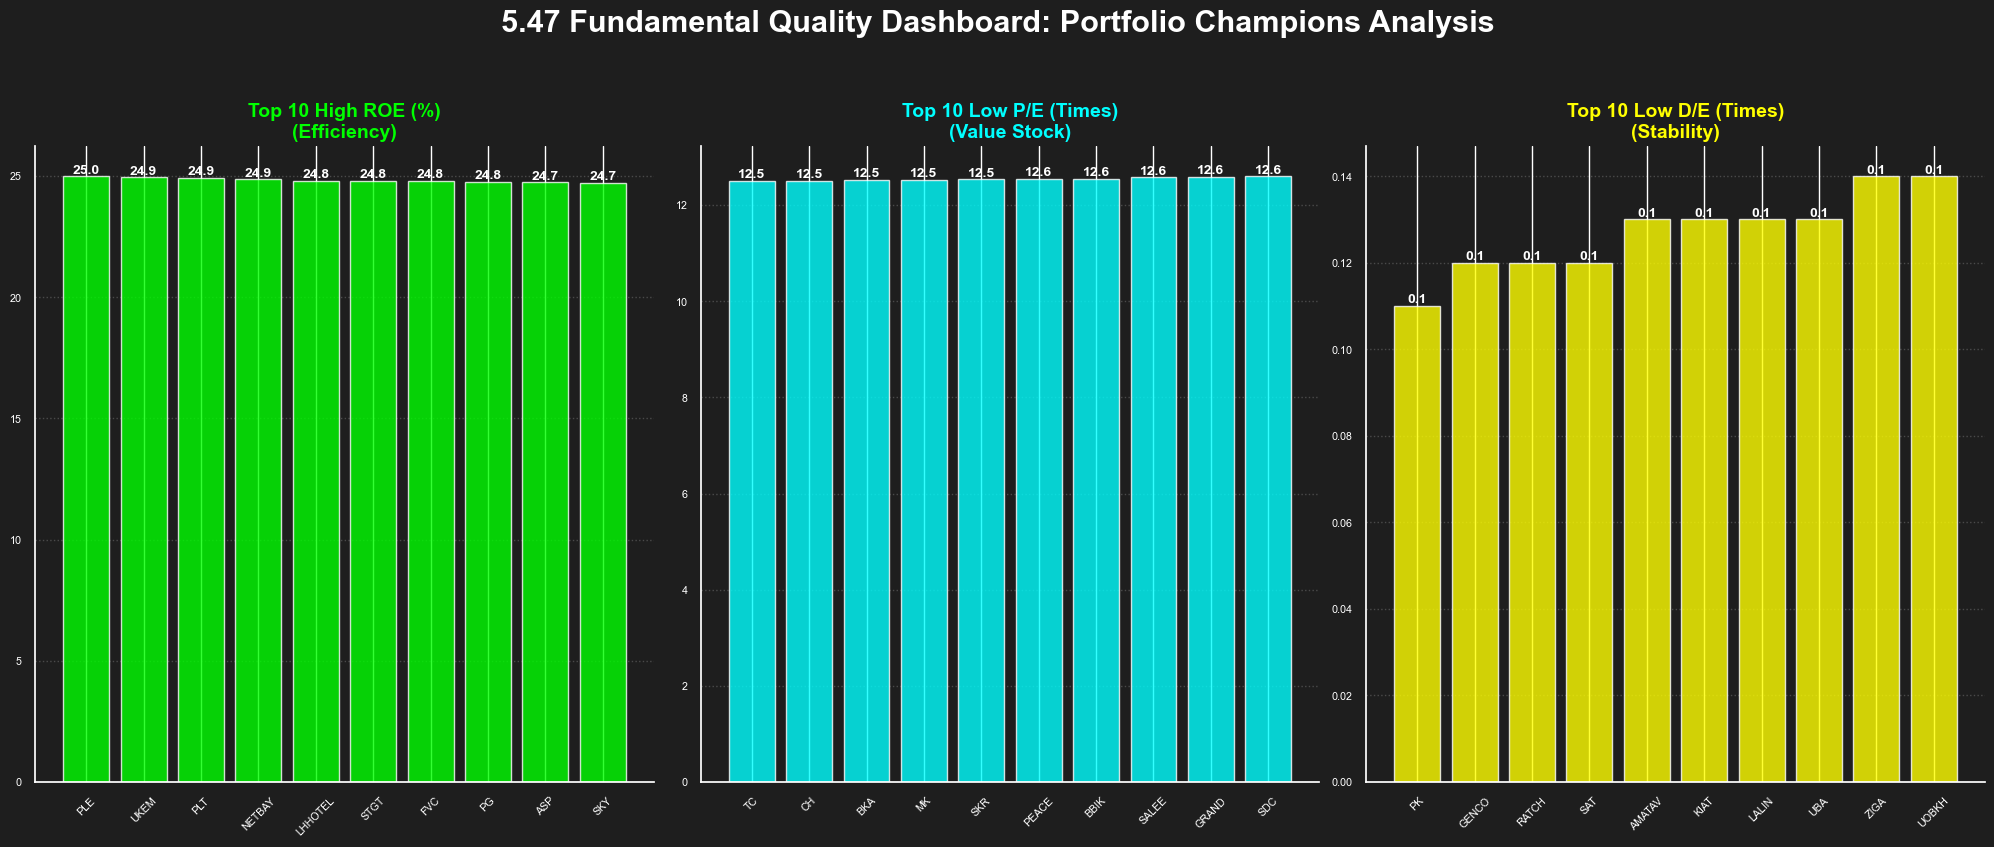

🚀 Fundamental Dashboard ถูกสร้างและบันทึกเรียบร้อยแล้ว!


In [51]:
# 5.47 Fundamental Quality Dashboard (ROE, P/E, D/E)
import matplotlib.pyplot as plt

try:
    # 1. ดึงข้อมูลตัวแปรจากข้อ 5.46
    if 'top_roe' not in locals():
        get_ipython().run_line_magic('store', '-r', 'top_roe low_pe low_de')

    # --- ตั้งค่า Matplotlib สำหรับ Dark Mode ---
    plt.style.use('dark_background')
    
    # สร้าง Subplots แบบ 3 กราฟในแถวเดียว
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8), facecolor='#1e1e1e')
    plt.subplots_adjust(wspace=0.3)

    # 1. กราฟ ROE (Efficiency - เขียว Neon)
    bars1 = ax1.bar(top_roe['symbol'], top_roe['ROE_Pct'], color='#00ff00', alpha=0.8)
    ax1.set_title('Top 10 High ROE (%)\n(Efficiency)', fontsize=14, fontweight='bold', color='#00ff00')
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. กราฟ P/E (Value - ฟ้า Neon)
    bars2 = ax2.bar(low_pe['symbol'], low_pe['PE_Ratio'], color='#00ffff', alpha=0.8)
    ax2.set_title('Top 10 Low P/E (Times)\n(Value Stock)', fontsize=14, fontweight='bold', color='#00ffff')
    ax2.tick_params(axis='x', rotation=45)

    # 3. กราฟ D/E (Stability - เหลือง Neon)
    bars3 = ax3.bar(low_de['symbol'], low_de['DE_Ratio'], color='#ffff00', alpha=0.8)
    ax3.set_title('Top 10 Low D/E (Times)\n(Stability)', fontsize=14, fontweight='bold', color='#ffff00')
    ax3.tick_params(axis='x', rotation=45)

    # ฟังก์ชันสำหรับเพิ่มตัวเลขบนแท่งกราฟ
    def add_labels(ax, bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    add_labels(ax1, bars1)
    add_labels(ax2, bars2)
    add_labels(ax3, bars3)

    # ตกแต่ง Grid และกรอบ
    for ax in [ax1, ax2, ax3]:
        ax.set_facecolor('#1e1e1e')
        ax.grid(axis='y', linestyle=':', alpha=0.2)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

    # หัวข้อใหญ่
    plt.suptitle('5.47 Fundamental Quality Dashboard: Portfolio Champions Analysis', 
                 fontsize=22, fontweight='bold', y=1.05, color='white')

    plt.tight_layout()
    plt.savefig('fundamental_dashboard_neon.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("🚀 Fundamental Dashboard ถูกสร้างและบันทึกเรียบร้อยแล้ว!")

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")